# Bài tập 3 — Phân loại văn bản ngắn với Word2Vec và GloVe

**Học viên:** Đặng Thành Nhân

---

## 1. Đề bài

> Thực hiện **phân loại văn bản ngắn**.
>
> **Dataset:** https://drive.google.com/file/d/1MPKclwDAgrzzdZCKfhqoYUeOcVm_lWFh/view?usp=sharing
>
> **Yêu cầu:**
> - Thực hiện embedding dựa trên **Word2Vec** và **GloVe**.
> - **So sánh, đánh giá** kết quả dựa trên 2 mô hình tạo embedding.
> - **Đề xuất phương án cải thiện** nếu có.

---

## 2. Ý tưởng và kế hoạch thí nghiệm

Câu hỏi trung tâm của bài không phải "mô hình nào phân loại giỏi nhất" mà là
**"nguồn vector từ nào tốt hơn cho bài toán này"**. Muốn trả lời được câu đó một cách trung thực,
thiết kế thí nghiệm phải tuân thủ một nguyên tắc:

> **Giữ nguyên tuyệt đối kiến trúc bộ phân loại, tiền xử lý, cách chia dữ liệu, seed và số chiều
> vector; chỉ thay đúng một thứ là ma trận embedding.**

Nhờ đó mọi chênh lệch điểm số đều quy được về chất lượng embedding, không phải về mô hình.

| # | Bước | Nội dung |
|---|---|---|
| 1 | Tải dữ liệu | `gdown` → mount Google Drive → upload tay (3 lớp dự phòng) |
| 2 | Nạp dữ liệu | Bộ nạp **bất khả tri định dạng** (zip/csv/tsv/txt/json/jsonl), tự dò encoding, tự dò cột text & cột nhãn |
| 3 | EDA | Phân bố nhãn, độ dài (ký tự & token), token đặc trưng theo lớp, kích thước từ vựng, trùng lặp |
| 4 | Tiền xử lý | NFC, lowercase, bỏ URL/mention/HTML, xử lý dấu câu & chữ số, tokenize (có **nhánh tiếng Việt**) |
| 5 | Chia dữ liệu | **Stratified** train/val/test, seed cố định |
| 6 | **Track A — Word2Vec** | Huấn luyện `gensim.Word2Vec` **trên chính tập train**: cả `sg=1` (Skip-gram) và `sg=0` (CBOW) |
| 7 | **Track B — GloVe** | Nạp vector **tiền huấn luyện** `glove-wiki-gigaword-100` |
| 8 | Ma trận embedding | Dựng embedding matrix cho từ vựng dataset, đo **coverage / OOV** (theo *type* và theo *token*) |
| 9 | Bộ phân loại | **Giống hệt nhau** cho mọi embedding: Mean-pool + Logistic Regression, **BiLSTM**, **TextCNN**; thêm **TF-IDF + LinearSVC** làm mốc phi-nơ-ron |
| 10 | Đánh giá | Accuracy, macro/weighted P-R-F1, báo cáo theo lớp, confusion matrix, bảng kết quả + biểu đồ cột nhóm |
| 11 | **So sánh W2V vs GloVe** | OOV, in-domain vs pretrained, chất lượng láng giềng, ảnh hưởng theo lớp, chi phí huấn luyện, **t-SNE/PCA cạnh nhau** |
| 12 | Cải thiện & kết luận | fastText, domain-adaptive pretraining, PhoBERT/DistilBERT, xử lý mất cân bằng, augmentation... |

**Giả thuyết trước khi chạy** (sẽ kiểm chứng bằng số liệu ở phần 13):

* Word2Vec tự huấn luyện **khớp miền** (in-domain) — nó biết mọi từ lóng, viết tắt trong dataset →
  **coverage theo token rất cao**, nhưng chỉ học từ vài trăm nghìn token nên vector **nhiễu**, nhất
  là với từ hiếm; và bản thân nó **cũng có OOV** vì `min_count` loại bỏ đuôi dài.
* GloVe tiền huấn luyện học từ 6 tỉ token Wikipedia + Gigaword → vector **rất ổn định về mặt ngữ nghĩa**,
  nhưng **không khớp miền** → tỉ lệ **OOV cao** với dữ liệu mạng xã hội.

Cuộc so sánh, vì thế, thực chất là **"khớp miền" đấu với "lượng dữ liệu huấn luyện"**.

---
## 3. Cấu hình chung

Toàn bộ tham số có thể chỉnh nằm gọn trong một ô. Hai biến đáng chú ý nhất:

* `QUICK_RUN` — bật để chạy thử nhanh (lấy mẫu con + ít epoch), kiểm tra notebook không lỗi.
* `TEXT_COL` / `LABEL_COL` — để `None` thì notebook **tự dò**; nếu dò sai chỉ cần gán tên cột.

In [1]:
# =====================================================================
#  CẤU HÌNH — chỉ cần sửa ở ô này
# =====================================================================
SEED = 42

# Bật để chạy thử nhanh (lấy mẫu con + ít epoch). Đặt False khi chạy thật.
QUICK_RUN = False

# ---- Đường dẫn (Google Colab / Linux) --------------------------------
BASE_DIR   = "/content/text_cls"
DATA_DIR   = f"{BASE_DIR}/data"
EXTRACT_DIR= f"{DATA_DIR}/extracted"

# ---- Nguồn dữ liệu ---------------------------------------------------
GDRIVE_FILE_ID  = "1MPKclwDAgrzzdZCKfhqoYUeOcVm_lWFh"
GDRIVE_VIEW_URL = f"https://drive.google.com/file/d/{GDRIVE_FILE_ID}/view?usp=sharing"

# ---- Cột dữ liệu (None = tự dò) --------------------------------------
TEXT_COL  = None    # ví dụ ghi đè: TEXT_COL = "text"
LABEL_COL = None    # ví dụ ghi đè: LABEL_COL = "sentiment"

# ---- Tiền xử lý ------------------------------------------------------
LOWERCASE        = True
REMOVE_STOPWORDS = False   # xem mục 7.5 & 8 để biết vì sao MẶC ĐỊNH TẮT với bài sentiment
REMOVE_DIGITS    = True
MIN_TOKENS       = 1       # bỏ mẫu sau tiền xử lý còn ít hơn ngần này token
USE_UNDERTHESEA  = True    # chỉ có tác dụng khi phát hiện corpus là tiếng Việt

# ---- Embedding -------------------------------------------------------
EMB_DIM       = 100        # để 100 cho CẢ Word2Vec và GloVe -> so sánh CÔNG BẰNG
W2V_WINDOW    = 5
W2V_MIN_COUNT = 2
W2V_EPOCHS    = 30
W2V_NEGATIVE  = 10

GLOVE_GENSIM_NAME  = "glove-wiki-gigaword-100"   # ~128 MB, tải qua gensim.downloader (mặc định BẬT)
ALLOW_BIG_DOWNLOAD = False   # cho phép fallback tải glove.6B.zip (~822 MB) từ Stanford/HuggingFace
USE_PRETRAINED_W2V_GOOGLE = False  # word2vec-google-news-300 (~1.6 GB). Colab đủ băng thông
                                   # và dung lượng, nhưng mặc định TẮT cho nhanh.
CACHE_VECTORS_TO_DRIVE = True      # nếu đã mount Drive thì cache gensim-data vào Drive

# ---- Từ vựng / chuỗi -------------------------------------------------
# CỐ Ý để = 1: từ vựng lấy TẤT CẢ từ xuất hiện trong train, nhờ đó Word2Vec và GloVe
# cùng phải đối mặt với ĐÚNG MỘT thách thức OOV. Nếu đặt bằng W2V_MIN_COUNT thì
# coverage của Word2Vec sẽ là 100% một cách hiển nhiên và phép so sánh mất ý nghĩa.
VOCAB_MIN_FREQ = 1
MAX_LEN_CAP    = 48        # trần độ dài chuỗi (văn bản ngắn nên không cần dài)

# ---- Huấn luyện ------------------------------------------------------
BATCH_SIZE  = 128          # 64-128 đều thoải mái trên T4/L4
LR          = 1e-3
MAX_EPOCHS  = 15
PATIENCE    = 3            # early stopping theo macro-F1 trên tập val
DROPOUT     = 0.4
LSTM_HIDDEN = 128
CNN_FILTERS = 100
CNN_KERNELS = (2, 3, 4)
NUM_WORKERS = 2
RUN_TRAINABLE_ABLATION = True   # ablation: embedding đóng băng (frozen) vs cho fine-tune

# ---- Chia dữ liệu ----------------------------------------------------
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.80, 0.10, 0.10
PREFER_PROVIDED_TEST_FILE = True   # nếu dataset có sẵn file *test* CÓ NHÃN -> dùng làm test set

if QUICK_RUN:
    W2V_EPOCHS = 5
    MAX_EPOCHS = 2
    PATIENCE   = 1

print("Đã nạp cấu hình.  QUICK_RUN =", QUICK_RUN)

Đã nạp cấu hình.  QUICK_RUN = False


---
## 4. Cài đặt, import, seed và device

Colab đã cài sẵn: `torch` (bản CUDA), `numpy`, `pandas`, `matplotlib`, `seaborn`,
`scikit-learn`, `scipy`, `tqdm`, `requests`, **`gdown`**, `nltk`.

Thứ **cần cài thêm** thực chất chỉ có **`gensim`** (không có sẵn trên image Colab hiện tại).
Lưu ý: `pip install gensim` đôi khi kéo theo việc đổi phiên bản `numpy`/`scipy`; nếu sau khi cài mà
`import gensim` vẫn lỗi thì **Runtime → Restart session** rồi chạy lại từ đầu — ô dưới sẽ in đúng
hướng dẫn đó. Ta **không** cài lại `torch` (mất vài phút và có thể phá bản CUDA) và **không**
tự ý hạ cấp `numpy`/`scipy`.

Notebook **không phụ thuộc `nltk`**: danh sách stopword được viết thẳng trong notebook
(mục 8), nên không cần `nltk.download()`.

In [2]:
# --- Thông tin máy Colab ---------------------------------------------
!nvidia-smi || echo "(không có GPU - vẫn chạy được trên CPU)"
!df -h /content | tail -n 2

Tue Aug 25 07:26:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             61W /  400W |    5603MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# =====================================================================
#  Cài đặt có kiểm tra (idempotent): thử import trước, thiếu mới cài
# =====================================================================
import importlib, subprocess, sys

def pip_install(spec, quiet=True):
    cmd = [sys.executable, "-m", "pip", "install"] + (["-q"] if quiet else []) + spec.split()
    print(f"[setup] pip install {spec} ...")
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print(((r.stdout or "") + (r.stderr or ""))[-1500:])
    return r.returncode == 0

def ensure(module_name, pip_spec=None):
    """Import module; nếu thiếu thì pip install rồi import lại. Trả về module hoặc None."""
    try:
        return importlib.import_module(module_name)
    except ImportError:
        pass
    pip_install(pip_spec or module_name)
    importlib.invalidate_caches()
    try:
        return importlib.import_module(module_name)
    except Exception as e:
        print(f"[setup] Vẫn không import được {module_name}: {type(e).__name__}: {e}")
        return None

# gensim: bắt buộc cho cả Word2Vec lẫn GloVe
_gensim = ensure("gensim", "gensim>=4.3.3")
if _gensim is None:
    print("""
=====================================================================
 KHÔNG IMPORT ĐƯỢC GENSIM
 Nguyên nhân phổ biến nhất trên Colab: pip vừa đổi phiên bản numpy/scipy
 nên session hiện tại đang giữ bản cũ trong bộ nhớ.
 CÁCH XỬ LÝ:
   1) Menu  Runtime -> Restart session
   2) Chạy lại notebook từ ô đầu tiên (không cần cài lại, pip đã xong)
 Nếu vẫn lỗi, chạy:  !pip install -q "gensim>=4.3.3" "scipy>=1.11"
 rồi Restart session một lần nữa.
=====================================================================
""")

# gdown có sẵn trên Colab; ensure() để notebook vẫn chạy được ngoài Colab
_gdown = ensure("gdown")
print("[setup] Xong phần cài đặt.")

[setup] pip install gensim>=4.3.3 ...
[setup] Xong phần cài đặt.


In [4]:
# =====================================================================
#  Import & thiết lập
# =====================================================================
import os, sys, re, io, json, time, math, zipfile, gzip, shutil, random, unicodedata
import html as _html
import warnings
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as gensim_api

from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 90)

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# ---- Seed mọi nguồn ngẫu nhiên --------------------------------------
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ---- Device ----------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("PHIÊN BẢN THƯ VIỆN")
print(f"  python : {sys.version.split()[0]}")
print(f"  numpy  : {np.__version__}")
print(f"  pandas : {pd.__version__}")
print(f"  gensim : {gensim.__version__}")
print(f"  torch  : {torch.__version__}")
print(f"  sklearn: {__import__('sklearn').__version__}")
print()
print(f"  torch.cuda.is_available() = {torch.cuda.is_available()}")
print(f"  DEVICE = {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU    : {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB VRAM)")
else:
    print("""
  [!] Chưa bật GPU. Vào  Runtime -> Change runtime type -> Hardware accelerator: GPU (T4)
      rồi chạy lại. Bài này nhỏ nên CPU vẫn chạy được (chỉ chậm hơn vài lần),
      toàn bộ code dùng biến DEVICE nên không cần sửa gì.
""")

PHIÊN BẢN THƯ VIỆN
  python : 3.13.15
  numpy  : 2.1.3
  pandas : 2.2.3
  gensim : 4.4.0
  torch  : 2.11.0+cu128
  sklearn: 1.6.1

  torch.cuda.is_available() = True
  DEVICE = cuda
  GPU    : NVIDIA A100-SXM4-80GB  (85.1 GB VRAM)


In [5]:
# =====================================================================
#  (Tuỳ chọn) Mount Google Drive: dùng để (a) đọc dataset nếu gdown bị
#  chặn quota, (b) cache vector tiền huấn luyện, (c) lưu checkpoint/kết quả.
#  Nếu không muốn mount, cứ để MOUNT_DRIVE = False, notebook vẫn chạy đủ.
# =====================================================================
MOUNT_DRIVE = False   # đổi thành True nếu muốn mount Drive

DRIVE_ROOT = None
if MOUNT_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_ROOT = "/content/drive/MyDrive"
        print("[drive] Đã mount:", DRIVE_ROOT)
    except Exception as e:
        print(f"[drive] Không mount được ({type(e).__name__}: {e}) -> bỏ qua, dùng /content.")

DRIVE_OK = DRIVE_ROOT is not None and os.path.isdir(DRIVE_ROOT)

CKPT_DIR = os.path.join(DRIVE_ROOT, "dl_homework", "hw3") if DRIVE_OK else f"{BASE_DIR}/ckpt"
os.makedirs(CKPT_DIR, exist_ok=True)
print("[ckpt] Thư mục lưu checkpoint & kết quả:", CKPT_DIR)

# Cache gensim-data (GloVe...) vào Drive để lần chạy sau không phải tải lại
if DRIVE_OK and CACHE_VECTORS_TO_DRIVE:
    gd = os.path.join(DRIVE_ROOT, "gensim-data")
    os.makedirs(gd, exist_ok=True)
    os.environ["GENSIM_DATA_DIR"] = gd
    try:
        gensim_api.BASE_DIR = gd
        gensim_api.base_dir = gd
    except Exception:
        pass
    print("[cache] gensim-data ->", gd)
else:
    print("[cache] gensim-data dùng thư mục mặc định (~/gensim-data). "
          "Tải lại mỗi lần khởi động runtime mới.")

[ckpt] Thư mục lưu checkpoint & kết quả: /content/text_cls/ckpt
[cache] gensim-data dùng thư mục mặc định (~/gensim-data). Tải lại mỗi lần khởi động runtime mới.


---
## 5. Tải dữ liệu từ Google Drive

Ba lớp dự phòng, chạy lần lượt cho tới khi có file:

1. **`gdown`** (có sẵn trên Colab) — tự xử lý trang cảnh báo "can't scan for viruses":
   ```
   !gdown --id 1MPKclwDAgrzzdZCKfhqoYUeOcVm_lWFh -O /content/text_cls/data/dataset_download.bin
   ```
2. **Đọc từ Google Drive của chính bạn** — dùng khi file bị **chặn quota tải** (rất hay gặp với file
   được nhiều người tải). Cách làm: mở link ở trên → nút **"Add shortcut to Drive"** (Thêm lối tắt vào
   Drive) → đặt vào *My Drive* → bật `MOUNT_DRIVE = True` ở ô mount phía trên → chạy lại ô này.
   Notebook sẽ tự quét Drive tìm file.
3. **Tải lên thủ công** — `files.upload()` mở hộp thoại chọn file từ máy.

Mọi lời gọi mạng đều bọc `try/except` và **không làm dừng notebook**.

In [6]:
DOWNLOAD_TARGET = os.path.join(DATA_DIR, "dataset_download.bin")


def _looks_like_html(blob: bytes) -> bool:
    head = blob[:2048].lower()
    return (b"<html" in head) or (b"<!doctype html" in head)


def _valid_file(path) -> bool:
    if not path or not os.path.exists(path) or os.path.getsize(path) < 1024:
        return False
    with open(path, "rb") as f:
        return not _looks_like_html(f.read(2048))


# ---------- Cách 1: gdown -------------------------------------------
def fetch_via_gdown(dst):
    try:
        import gdown
    except ImportError:
        print("[tải] Không có gdown.")
        return None
    for attempt, kw in enumerate([dict(id=GDRIVE_FILE_ID), dict(url=GDRIVE_VIEW_URL, fuzzy=True)], 1):
        try:
            print(f"[tải] gdown thử lần {attempt} với {list(kw)[0]} ...")
            out = gdown.download(output=dst, quiet=False, **kw)
            if out and _valid_file(dst):
                print(f"[tải] gdown OK -> {dst} ({os.path.getsize(dst)/1e6:.2f} MB)")
                return dst
        except Exception as e:
            print(f"[tải] gdown lỗi: {type(e).__name__}: {e}")
    return None


# ---------- Cách 2: quét Google Drive đã mount ------------------------
DRIVE_NAME_HINTS = ("sentiment", "classification", "dataset", "data")

def fetch_from_mounted_drive():
    if not DRIVE_OK:
        print("[tải] Drive chưa mount -> bỏ qua cách 2. "
              "(Bật MOUNT_DRIVE = True ở ô mount rồi chạy lại nếu cần.)")
        return None
    cands = []
    for dirpath, dirnames, filenames in os.walk(DRIVE_ROOT):
        dirnames[:] = [d for d in dirnames if not d.startswith(".")][:80]
        for fn in filenames:
            low = fn.lower()
            if low.endswith((".zip", ".csv", ".tsv", ".json", ".jsonl", ".txt", ".gz")) and \
               any(h in low for h in DRIVE_NAME_HINTS):
                cands.append(os.path.join(dirpath, fn))
        if len(cands) > 40:
            break
    if not cands:
        print("[tải] Không thấy file phù hợp trong Drive. "
              "Hãy 'Add shortcut to Drive' cho file dataset rồi thử lại.")
        return None
    cands.sort(key=lambda p: -os.path.getsize(p))
    print("[tải] Ứng viên trong Drive:")
    for p in cands[:10]:
        print(f"        {p}  ({os.path.getsize(p)/1e6:.2f} MB)")
    chosen = cands[0]
    print(f"[tải] Dùng: {chosen}")
    return chosen


# ---------- Cách 3: upload tay ---------------------------------------
def fetch_via_upload():
    try:
        from google.colab import files
    except ImportError:
        print("[tải] Không ở trong Colab -> bỏ qua cách 3.")
        return None
    print("""
[tải] HÃY TẢI FILE LÊN THỦ CÔNG
      1) Mở link:  %s
      2) Bấm Download (file SentimentClassification.zip);
         nếu Google báo "can't scan for viruses" -> bấm "Download anyway".
      3) Chọn file vừa tải ở hộp thoại bên dưới.
""" % GDRIVE_VIEW_URL)
    try:
        up = files.upload()
    except Exception as e:
        print(f"[tải] upload lỗi: {type(e).__name__}: {e}")
        return None
    if not up:
        return None
    name = list(up.keys())[0]
    dst = os.path.join(DATA_DIR, name)
    with open(dst, "wb") as f:
        f.write(up[name])
    print(f"[tải] Đã nhận {dst} ({os.path.getsize(dst)/1e6:.2f} MB)")
    return dst


def resolve_raw_path():
    # (0) đã tải từ lần chạy trước?
    if _valid_file(DOWNLOAD_TARGET):
        print(f"[tải] Đã có sẵn {DOWNLOAD_TARGET} -> dùng lại.")
        return DOWNLOAD_TARGET
    if os.path.isdir(EXTRACT_DIR) and os.listdir(EXTRACT_DIR):
        print(f"[tải] Đã có sẵn thư mục giải nén {EXTRACT_DIR} -> dùng lại.")
        return EXTRACT_DIR
    for fn in ("fetch_via_gdown", "fetch_from_mounted_drive", "fetch_via_upload"):
        f = globals()[fn]
        print("\n" + "-" * 62)
        p = f(DOWNLOAD_TARGET) if fn == "fetch_via_gdown" else f()
        if p and (os.path.isdir(p) or _valid_file(p)):
            return p
    return None


RAW_PATH = resolve_raw_path()
print("\n" + "=" * 62)
print("RAW_PATH =", RAW_PATH)
if RAW_PATH is None:
    print("""
KHÔNG LẤY ĐƯỢC DỮ LIỆU.
  - Thử lại sau vài phút (Google Drive giới hạn quota theo giờ), hoặc
  - Bật MOUNT_DRIVE = True ở ô mount, "Add shortcut to Drive" cho file rồi chạy lại, hoặc
  - Chạy lại ô này và dùng hộp thoại upload.
""")


--------------------------------------------------------------
[tải] gdown thử lần 1 với id ...


Downloading...
From: https://drive.google.com/uc?id=1MPKclwDAgrzzdZCKfhqoYUeOcVm_lWFh
To: /content/text_cls/data/dataset_download.bin
100%|██████████| 1.86M/1.86M [00:00<00:00, 198MB/s]

[tải] gdown OK -> /content/text_cls/data/dataset_download.bin (1.86 MB)

RAW_PATH = /content/text_cls/data/dataset_download.bin


---
## 6. Nạp dữ liệu — bộ nạp "bất khả tri định dạng"

Ta không giả định trước file tải về là gì, nên bộ nạp được viết **phòng thủ**:

* **Sniff magic bytes** (`PK\x03\x04` = zip, `\x1f\x8b` = gzip, `PAR1` = parquet) *và* phần mở rộng —
  không tin riêng cái tên file.
* Zip/gzip thì **tự giải nén**, sau đó **liệt kê toàn bộ** những gì tìm thấy.
* Với mỗi bảng, thử lần lượt các **encoding** `utf-8 → utf-8-sig → cp1252 → latin-1` và các
  **separator** `, \t ; |`, cộng chế độ tự sniff separator của pandas.
  *(Chi tiết quan trọng: dataset của bài này **không phải UTF-8** — đọc bằng `utf-8` sẽ ném
  `UnicodeDecodeError`. Vòng lặp encoding chính là thứ cứu notebook ở đây.)*
* Hỗ trợ `.csv .tsv .txt .json .jsonl/.ndjson .xlsx .parquet`.
* Nếu tìm thấy **nhiều bảng** (ví dụ `train.csv` + `test.csv`) thì gộp lại, đánh dấu nguồn ở cột
  `__source` để bước chia dữ liệu phía dưới có thể tôn trọng split gốc.

In [7]:
# =====================================================================
#  6.1 — Sniff định dạng & giải nén
# =====================================================================
TABLE_EXTS = {".csv", ".tsv", ".txt", ".json", ".jsonl", ".ndjson", ".xlsx", ".xls", ".parquet"}


def sniff_kind(path: str) -> str:
    """Đoán loại file bằng magic bytes trước, rồi mới đến đuôi file."""
    if os.path.isdir(path):
        return "dir"
    try:
        with open(path, "rb") as f:
            magic = f.read(8)
    except Exception:
        magic = b""
    ext = os.path.splitext(path)[1].lower()
    if magic[:4] == b"PK\x03\x04":
        return "xlsx" if ext in (".xlsx", ".xlsm") else "zip"
    if magic[:2] == b"\x1f\x8b":
        return "gzip"
    if magic[:4] == b"PAR1":
        return "parquet"
    if ext == ".zip":              return "zip"
    if ext == ".gz":               return "gzip"
    if ext == ".json":             return "json"
    if ext in (".jsonl", ".ndjson"): return "jsonl"
    if ext == ".parquet":          return "parquet"
    if ext == ".tsv":              return "tsv"
    if ext == ".csv":              return "csv"
    if ext == ".txt":              return "txt"
    try:
        magic.decode("utf-8")
        return "txt"
    except Exception:
        return "binary"


def collect_files(root: str):
    """Giải nén nếu cần rồi trả về danh sách file phẳng."""
    kind = sniff_kind(root)

    if kind == "zip":
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        with zipfile.ZipFile(root) as z:
            names = z.namelist()
            print(f"[nạp] File ZIP chứa {len(names)} mục:")
            for n in names[:40]:
                print("         -", n)
            if len(names) > 40:
                print(f"         ... và {len(names) - 40} mục nữa")
            z.extractall(EXTRACT_DIR)
        print(f"[nạp] Đã giải nén -> {EXTRACT_DIR}")
        root, kind = EXTRACT_DIR, "dir"

    elif kind == "gzip":
        os.makedirs(EXTRACT_DIR, exist_ok=True)
        base = os.path.basename(root)
        base = base[:-3] if base.endswith(".gz") else base + ".out"
        dst = os.path.join(EXTRACT_DIR, base)
        with gzip.open(root, "rb") as fi, open(dst, "wb") as fo:
            shutil.copyfileobj(fi, fo)
        print(f"[nạp] Đã giải nén gzip -> {dst}")
        return [dst]

    if kind == "dir":
        files = []
        for dirpath, dirnames, filenames in os.walk(root):
            dirnames[:] = [d for d in dirnames if not d.startswith(("__MACOSX", "."))]
            for fn in filenames:
                if not fn.startswith("."):
                    files.append(os.path.join(dirpath, fn))
        return sorted(files)

    return [root]


# =====================================================================
#  6.2 — Đọc một file bất kỳ thành DataFrame
# =====================================================================
ENCODINGS = ("utf-8", "utf-8-sig", "cp1252", "latin-1")


def read_any_table(path: str):
    """Trả về (DataFrame, mô_tả) hoặc (None, lý_do)."""
    kind = sniff_kind(path)
    ext = os.path.splitext(path)[1].lower()

    if kind == "parquet":
        try:
            return pd.read_parquet(path), "parquet"
        except Exception as e:
            return None, f"parquet lỗi: {e}"

    if kind == "xlsx" or ext in (".xlsx", ".xls"):
        try:
            return pd.read_excel(path), "excel"
        except Exception as e:
            return None, f"excel lỗi (thiếu openpyxl?): {e}"

    if kind in ("json", "jsonl") or ext in (".json", ".jsonl", ".ndjson"):
        for lines in ((True,) if kind == "jsonl" else (False, True)):
            for enc in ENCODINGS:
                try:
                    d = pd.read_json(path, lines=lines, encoding=enc)
                    if len(d) >= 2:
                        return d, f"json(lines={lines}) enc={enc}"
                except Exception:
                    continue
        return None, "json/jsonl không đọc được"

    # ---- dạng text: csv / tsv / txt --------------------------------
    seps = ["\t"] if ext == ".tsv" else [",", "\t", ";", "|"]
    for enc in ENCODINGS:
        best, best_desc, best_score = None, "", -1
        for sep in seps:
            try:
                d = pd.read_csv(path, sep=sep, encoding=enc, on_bad_lines="skip",
                                engine="c", low_memory=False)
            except Exception:
                continue
            if d.shape[1] < 2 or d.shape[0] < 2:
                continue
            score = d.shape[1] * 1_000_000 + d.shape[0]
            if score > best_score:
                best, best_desc, best_score = d, f"csv sep={sep!r} enc={enc}", score
        if best is not None:
            return best, best_desc

    # sniff separator bằng engine python
    for enc in ENCODINGS:
        try:
            d = pd.read_csv(path, sep=None, engine="python", encoding=enc, on_bad_lines="skip")
            if d.shape[0] >= 2:
                return d, f"csv sniff enc={enc}"
        except Exception:
            continue

    # file .txt mỗi dòng một mẫu
    for enc in ENCODINGS:
        try:
            with open(path, "r", encoding=enc) as f:
                lines = [ln.rstrip("\n") for ln in f if ln.strip()]
            if len(lines) >= 2:
                return pd.DataFrame({"line": lines}), f"txt-lines enc={enc}"
        except Exception:
            continue

    return None, "không nhận dạng được"


# =====================================================================
#  6.3 — Chạy bộ nạp
# =====================================================================
if RAW_PATH is None:
    raise SystemExit("Chưa có dữ liệu — xem hướng dẫn ở ô tải phía trên rồi chạy lại.")

all_files = collect_files(RAW_PATH)
print(f"\n[nạp] Tìm thấy {len(all_files)} file:")
for p in all_files[:60]:
    try:
        sz = os.path.getsize(p) / 1e6
    except OSError:
        sz = float("nan")
    print(f"   - {os.path.relpath(p, DATA_DIR)}   ({sz:.2f} MB, kind={sniff_kind(p)})")
if len(all_files) > 60:
    print(f"   ... và {len(all_files) - 60} file nữa")

frames = {}
for p in all_files:
    if os.path.splitext(p)[1].lower() not in TABLE_EXTS and \
       sniff_kind(p) not in ("csv", "tsv", "txt", "json", "jsonl", "parquet"):
        continue
    d, desc = read_any_table(p)
    key = os.path.relpath(p, DATA_DIR).replace("\\", "/")
    if d is None:
        print(f"[nạp] BỎ QUA  {key}: {desc}")
    else:
        frames[key] = d
        print(f"[nạp] OK      {key}: shape={d.shape}  ({desc})")

if not frames:
    raise SystemExit("Không nạp được bảng dữ liệu nào — kiểm tra lại file tải về.")
print(f"\n[nạp] Tổng cộng {len(frames)} bảng.")

[nạp] File ZIP chứa 3 mục:
         - SentimentClassification/
         - SentimentClassification/test.csv
         - SentimentClassification/train.csv
[nạp] Đã giải nén -> /content/text_cls/data/extracted

[nạp] Tìm thấy 2 file:
   - extracted/SentimentClassification/test.csv   (0.47 MB, kind=csv)
   - extracted/SentimentClassification/train.csv   (4.64 MB, kind=csv)
[nạp] OK      extracted/SentimentClassification/test.csv: shape=(4815, 9)  (csv sep=',' enc=cp1252)
[nạp] OK      extracted/SentimentClassification/train.csv: shape=(27481, 10)  (csv sep=',' enc=cp1252)

[nạp] Tổng cộng 2 bảng.


### 6.4 — Tự dò cột văn bản và cột nhãn

Heuristic (luôn có thể ghi đè bằng `TEXT_COL` / `LABEL_COL` ở ô cấu hình):

* **Cột text** = cột kiểu chuỗi có **độ dài chuỗi trung bình lớn nhất**, ưu tiên nếu tên cột nằm
  trong danh sách gợi ý (`text, content, sentence, review, comment, tweet, ...`). Loại bỏ những cột
  trông như ID (gần như mọi giá trị đều khác nhau **và** rất ngắn).
* **Cột nhãn** = cột **ít giá trị phân biệt** (2 ≤ `nunique` ≤ max(20, 5 % số dòng)),
  **ưu tiên tuyệt đối theo tên** (`label, sentiment, class, target, category, polarity, ...`).

> **Vì sao ưu tiên theo tên là bắt buộc:** bộ dữ liệu này còn có những cột phụ cũng ít giá trị
> phân biệt (ví dụ một cột thời điểm đăng chỉ nhận 3 giá trị). Nếu chỉ xếp hạng theo cardinality,
> bộ dò rất dễ chọn nhầm cột phụ đó làm nhãn. Notebook in ra **toàn bộ bảng ứng viên** để người
> chạy tự kiểm tra lại.

In [8]:
TEXT_NAME_HINTS = ["text", "content", "sentence", "review", "comment", "message", "tweet",
                   "body", "document", "doc", "phrase", "utterance", "question", "title",
                   "noi_dung", "noidung", "binh_luan", "binhluan", "cau", "van_ban"]
LABEL_NAME_HINTS = ["label", "sentiment", "class", "target", "category", "polarity", "emotion",
                    "intent", "topic", "rating", "star", "y", "nhan", "phan_loai", "cam_xuc"]
DROP_EXACT_NAMES = {"id", "index", "unnamed: 0", "textid", "doc_id"}


def as_str(s):
    return s.astype("object").where(s.notna(), "").astype(str)


def detect_text_col(d):
    n = len(d)
    cands = []
    for c in d.columns:
        s = d[c]
        if not (s.dtype == object or str(s.dtype) in ("string", "str")):
            continue
        name = str(c).strip().lower()
        if name in DROP_EXACT_NAMES:
            continue
        vals = as_str(s)
        mean_len = float(vals.str.len().mean())
        nun = int(s.nunique(dropna=True))
        # loại cột giống ID: gần như unique nhưng rất ngắn
        if n > 50 and nun >= 0.95 * n and mean_len <= 24:
            continue
        exact = 1 if name in TEXT_NAME_HINTS else 0
        partial = 1 if any(h in name for h in TEXT_NAME_HINTS) else 0
        cands.append((exact, round(mean_len, 2), partial, c))
    if not cands:
        raise ValueError("Không tìm được cột văn bản -> hãy gán tay TEXT_COL ở ô cấu hình.")
    cands.sort(key=lambda t: (t[0], t[1], t[2]), reverse=True)
    return cands[0][3], cands


def detect_label_col(d, text_col):
    n = len(d)
    hi = max(20, int(0.05 * n))
    cands = []
    for c in d.columns:
        if c == text_col:
            continue
        name = str(c).strip().lower()
        s = d[c]
        nun = int(s.nunique(dropna=True))
        if nun < 2 or nun > hi:
            continue
        if pd.api.types.is_float_dtype(s) and nun > 12:
            continue
        exact = 1 if name in LABEL_NAME_HINTS else 0
        partial = 1 if any(h in name for h in LABEL_NAME_HINTS) else 0
        cands.append((exact, partial, -nun, c))
    if not cands:
        raise ValueError("Không tìm được cột nhãn -> hãy gán tay LABEL_COL ở ô cấu hình.")
    cands.sort(key=lambda t: (t[0], t[1], t[2]), reverse=True)
    return cands[0][3], cands


# --- Bảng chính = bảng nhiều dòng nhất --------------------------------
primary_key = max(frames, key=lambda k: len(frames[k]))
df_primary = frames[primary_key]
print(f"[cột] Bảng chính: {primary_key}   shape={df_primary.shape}")
print(f"[cột] Các cột    : {list(df_primary.columns)}")

_tc, text_cands = detect_text_col(df_primary)
TEXT_COL = TEXT_COL or _tc
_lc, label_cands = detect_label_col(df_primary, TEXT_COL)
LABEL_COL = LABEL_COL or _lc

print("\n[cột] Ứng viên cột TEXT  (khớp_tên_chính_xác, độ_dài_TB, khớp_tên_một_phần, cột):")
for t in text_cands[:10]:
    print("        ", t)
print("\n[cột] Ứng viên cột LABEL (khớp_tên_chính_xác, khớp_một_phần, -nunique, cột):")
for t in label_cands[:10]:
    print("        ", t)

print("\n" + "=" * 62)
print(f">>>  TEXT_COL  = {TEXT_COL!r}")
print(f">>>  LABEL_COL = {LABEL_COL!r}")
print("     (nếu sai: gán tay 2 biến này ở ô CẤU HÌNH rồi chạy lại từ đó)")
print("=" * 62)

# --- Gộp mọi bảng có đủ hai cột này ----------------------------------
parts = []
for k, d in frames.items():
    if TEXT_COL in d.columns and LABEL_COL in d.columns:
        sub = d[[TEXT_COL, LABEL_COL]].copy()
        sub["__source"] = k
        parts.append(sub)
        print(f"[cột] Dùng bảng {k}: {len(sub):,} dòng")
    else:
        print(f"[cột] Bỏ bảng  {k} (thiếu {TEXT_COL!r} hoặc {LABEL_COL!r})")

df = pd.concat(parts, ignore_index=True)
n_before = len(df)
df[TEXT_COL] = as_str(df[TEXT_COL])
df[LABEL_COL] = as_str(df[LABEL_COL]).str.strip()
df = df[(df[TEXT_COL].str.strip() != "") & (df[LABEL_COL] != "")].reset_index(drop=True)
print(f"\n[cột] Đã bỏ {n_before - len(df):,} dòng rỗng/NaN.")
print(f"[cột] DataFrame hợp nhất: {df.shape}")

print("\n--- dtypes ---")
print(df.dtypes.to_string())
print("\n--- 5 dòng đầu ---")
print(df.head(5).to_string())
print("\n--- số dòng theo file nguồn ---")
print(df["__source"].value_counts().to_string())

[cột] Bảng chính: extracted/SentimentClassification/train.csv   shape=(27481, 10)
[cột] Các cột    : ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

[cột] Ứng viên cột TEXT  (khớp_tên_chính_xác, độ_dài_TB, khớp_tên_một_phần, cột):
         (1, 68.35, 1, 'text')
         (0, 36.68, 1, 'selected_text')
         (0, 8.9, 0, 'Country')
         (0, 7.6, 0, 'sentiment')
         (0, 5.33, 1, 'Time of Tweet')
         (0, 5.0, 0, 'Age of User')

[cột] Ứng viên cột LABEL (khớp_tên_chính_xác, khớp_một_phần, -nunique, cột):
         (1, 1, -3, 'sentiment')
         (0, 1, -136, 'Density (P/Km²)')
         (0, 1, -195, 'Country')
         (0, 0, -3, 'Time of Tweet')
         (0, 0, -6, 'Age of User')
         (0, 0, -195, 'Population -2020')

>>>  TEXT_COL  = 'text'
>>>  LABEL_COL = 'sentiment'
     (nếu sai: gán tay 2 biến này ở ô CẤU HÌNH rồi chạy lại từ đó)
[cột] Dùng bảng extracted/Sentimen

---
## 7. Khảo sát dữ liệu (EDA)

Mục tiêu của phần này không chỉ là "vẽ vài cái biểu đồ" mà là **rút ra những ràng buộc thiết kế**
cho phần embedding phía sau: dữ liệu ngắn tới mức nào, mất cân bằng ra sao, đuôi dài từ vựng nặng
thế nào (đây chính là nguồn gốc của OOV).

In [9]:
# ---------- 7.1 Thiếu dữ liệu & trùng lặp ----------------------------
print("=" * 70)
print("KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
print("=" * 70)
print(f"Số dòng sau khi lọc rỗng : {len(df):,}")
print("\nGiá trị thiếu:")
print(df.isna().sum().to_string())

dup_full = int(df.duplicated(subset=[TEXT_COL, LABEL_COL]).sum())
dup_text = int(df.duplicated(subset=[TEXT_COL]).sum())
print(f"\nTrùng (text + label)          : {dup_full:,}  ({dup_full/len(df)*100:.2f}%)")
print(f"Trùng (chỉ text)              : {dup_text:,}  ({dup_text/len(df)*100:.2f}%)")
print(f"-> text trùng nhưng nhãn khác : {dup_text - dup_full:,}  (nhiễu nhãn tiềm tàng)")

n0 = len(df)
df = df.drop_duplicates(subset=[TEXT_COL, LABEL_COL]).reset_index(drop=True)
print(f"\nĐã bỏ {n0 - len(df):,} dòng trùng hoàn toàn -> còn {len(df):,} dòng.")
print("(Bỏ trùng TRƯỚC khi chia dữ liệu là bắt buộc: nếu không, cùng một câu có thể")
print(" vừa nằm ở train vừa nằm ở test -> rò rỉ dữ liệu, điểm test bị thổi phồng.)")

KIỂM TRA CHẤT LƯỢNG DỮ LIỆU
Số dòng sau khi lọc rỗng : 31,014

Giá trị thiếu:
text         0
sentiment    0
__source     0

Trùng (text + label)          : 0  (0.00%)
Trùng (chỉ text)              : 0  (0.00%)
-> text trùng nhưng nhãn khác : 0  (nhiễu nhãn tiềm tàng)

Đã bỏ 0 dòng trùng hoàn toàn -> còn 31,014 dòng.
(Bỏ trùng TRƯỚC khi chia dữ liệu là bắt buộc: nếu không, cùng một câu có thể
 vừa nằm ở train vừa nằm ở test -> rò rỉ dữ liệu, điểm test bị thổi phồng.)


PHÂN BỐ NHÃN
           count  percent
sentiment                
neutral    12547    40.46
positive    9685    31.23
negative    8782    28.32

Số lớp                      : 3  ->  ['negative', 'neutral', 'positive']
Tỉ lệ mất cân bằng          : 1.43x  (lớp lớn nhất / lớp nhỏ nhất)
Baseline 'đoán lớp trội'    : 40.46% accuracy
Baseline ngẫu nhiên đều     : 33.33% accuracy
-> Mọi mô hình phía dưới phải vượt rõ mốc 'đoán lớp trội' thì mới có ý nghĩa.


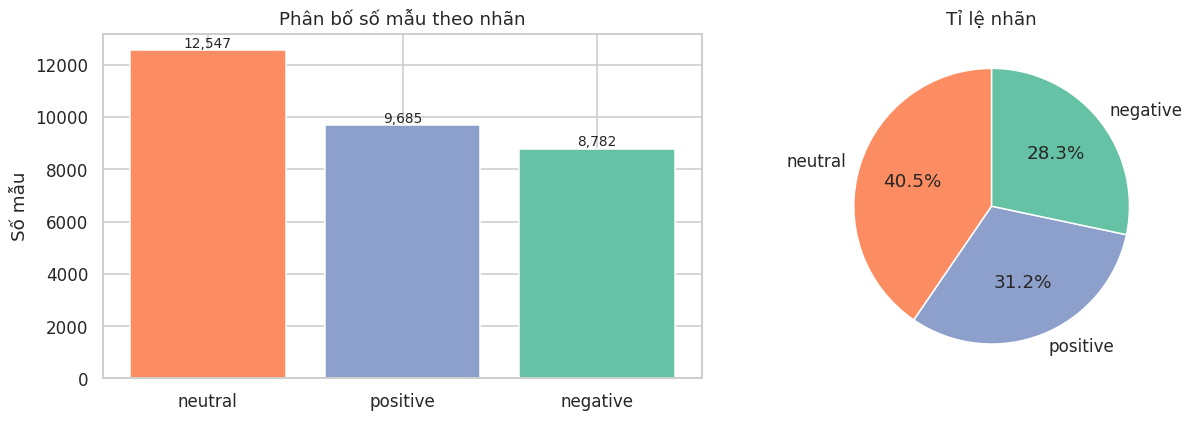

In [10]:
# ---------- 7.2 Phân bố nhãn -----------------------------------------
label_counts = df[LABEL_COL].value_counts()
label_pct = (label_counts / len(df) * 100).round(2)
CLASSES = sorted(label_counts.index.tolist())
N_CLASSES = len(CLASSES)
PALETTE = sns.color_palette("Set2", max(N_CLASSES, 3))

print("PHÂN BỐ NHÃN")
print(pd.DataFrame({"count": label_counts, "percent": label_pct}).to_string())

imbalance_ratio = float(label_counts.max() / label_counts.min())
majority_baseline = float(label_counts.max() / len(df))
print(f"\nSố lớp                      : {N_CLASSES}  ->  {CLASSES}")
print(f"Tỉ lệ mất cân bằng          : {imbalance_ratio:.2f}x  (lớp lớn nhất / lớp nhỏ nhất)")
print(f"Baseline 'đoán lớp trội'    : {majority_baseline*100:.2f}% accuracy")
print(f"Baseline ngẫu nhiên đều     : {100/N_CLASSES:.2f}% accuracy")
print("-> Mọi mô hình phía dưới phải vượt rõ mốc 'đoán lớp trội' thì mới có ý nghĩa.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar([str(c) for c in label_counts.index], label_counts.values,
          color=[PALETTE[CLASSES.index(c) % len(PALETTE)] for c in label_counts.index])
ax[0].set_title("Phân bố số mẫu theo nhãn"); ax[0].set_ylabel("Số mẫu")
for i, v in enumerate(label_counts.values):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax[1].pie(label_counts.values, labels=[str(c) for c in label_counts.index],
          autopct="%1.1f%%", startangle=90,
          colors=[PALETTE[CLASSES.index(c) % len(PALETTE)] for c in label_counts.index])
ax[1].set_title("Tỉ lệ nhãn")
plt.tight_layout(); plt.show()

THỐNG KÊ ĐỘ DÀI (trên văn bản GỐC, chưa tiền xử lý)
       _n_chars  _n_tokens
count  31014.00   31014.00
mean      68.29      12.89
std       35.62       6.92
min        3.00       1.00
25%       39.00       7.00
50%       64.00      12.00
75%       97.00      18.00
90%      122.00      23.00
95%      129.00      25.00
99%      137.00      28.00
max      159.00      33.00


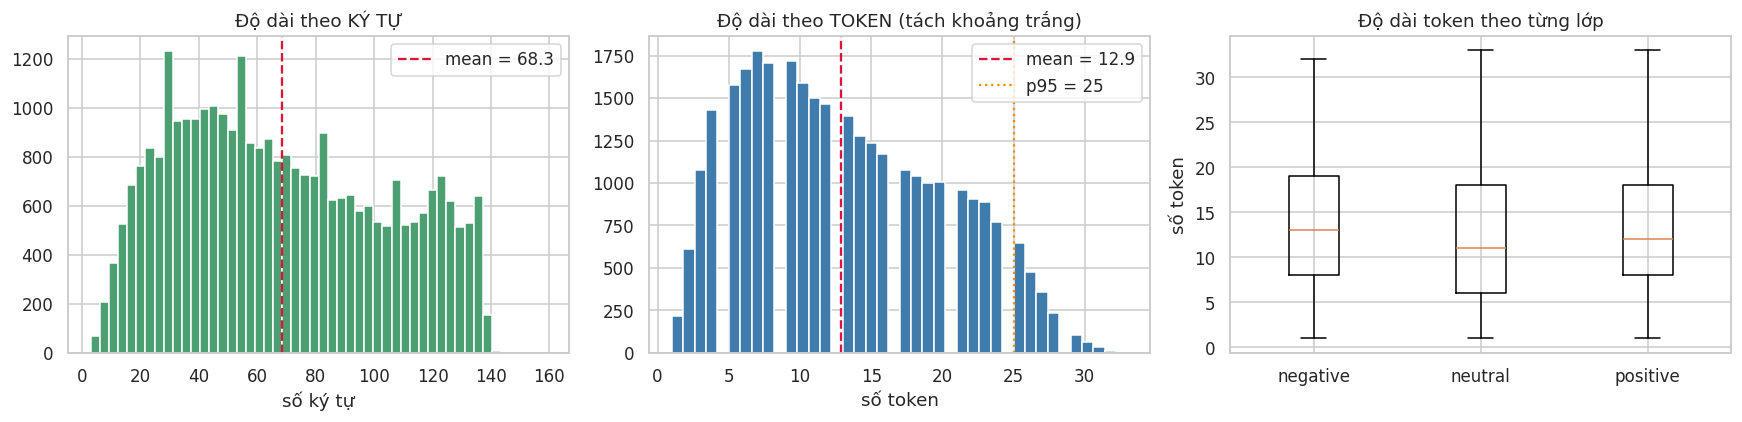


p95 số token = 25  ->  MAX_LEN sẽ lấy min(p95, MAX_LEN_CAP=48).


In [11]:
# ---------- 7.3 Độ dài văn bản ---------------------------------------
df["_n_chars"] = df[TEXT_COL].str.len()
df["_n_tokens"] = df[TEXT_COL].str.split().str.len()

print("THỐNG KÊ ĐỘ DÀI (trên văn bản GỐC, chưa tiền xử lý)")
print(df[["_n_chars", "_n_tokens"]]
      .describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(2).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(df["_n_chars"], bins=50, color="#4C9F70", edgecolor="white")
ax[0].axvline(df["_n_chars"].mean(), color="crimson", ls="--",
              label=f"mean = {df['_n_chars'].mean():.1f}")
ax[0].set_title("Độ dài theo KÝ TỰ"); ax[0].set_xlabel("số ký tự"); ax[0].legend()

ax[1].hist(df["_n_tokens"], bins=40, color="#3F7CAC", edgecolor="white")
ax[1].axvline(df["_n_tokens"].mean(), color="crimson", ls="--",
              label=f"mean = {df['_n_tokens'].mean():.1f}")
ax[1].axvline(df["_n_tokens"].quantile(.95), color="darkorange", ls=":",
              label=f"p95 = {df['_n_tokens'].quantile(.95):.0f}")
ax[1].set_title("Độ dài theo TOKEN (tách khoảng trắng)")
ax[1].set_xlabel("số token"); ax[1].legend()

_box_data = [df.loc[df[LABEL_COL] == c, "_n_tokens"].values for c in CLASSES]
try:
    ax[2].boxplot(_box_data, tick_labels=[str(c) for c in CLASSES], showfliers=False)
except TypeError:
    ax[2].boxplot(_box_data, labels=[str(c) for c in CLASSES], showfliers=False)
ax[2].set_title("Độ dài token theo từng lớp"); ax[2].set_ylabel("số token")
plt.tight_layout(); plt.show()

P95_TOKENS = int(df["_n_tokens"].quantile(0.95))
print(f"\np95 số token = {P95_TOKENS}  ->  MAX_LEN sẽ lấy min(p95, MAX_LEN_CAP={MAX_LEN_CAP}).")

TỪ VỰNG THÔ (chưa tiền xử lý)
  Số type (từ khác nhau)     : 26,524
  Tổng số token              : 411,838
  Hapax (xuất hiện đúng 1 lần): 15,473  (58.3% từ vựng)
  Type có freq >= 1          : 26,524
  Type/Token ratio           : 0.0644


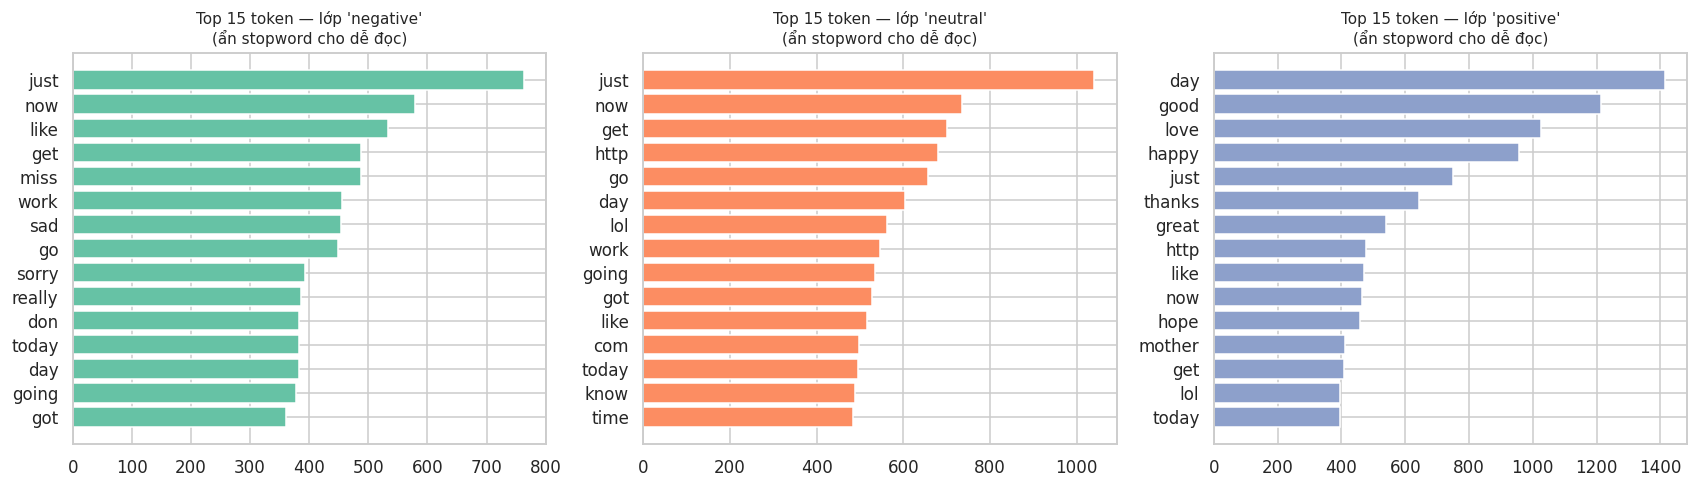


TOKEN ĐẶC TRƯNG NHẤT CHO MỖI LỚP (log-odds so với phần còn lại, freq >= 20):
    negative : worst(47), hates(38), hurts(136), dammit(21), worse(47), tummy(30), sucks(199), stupid(127), depressed(22), fail(75), headache(89), finger(22)
     neutral : weren(15), airport(24), training(15), private(19), dm(29), woot(16), uploading(14), step(14), jump(14), gd(28), nope(41), theres(17)
    positive : congratulations(31), fantastic(43), mommies(21), hilarious(28), wonderful(78), amazing(199), happy(957), thank(282), cheers(24), appreciate(36), excellent(22), mothers(337)


In [12]:
# ---------- 7.4 Từ vựng thô & token đặc trưng theo lớp ----------------
# Stopword viết thẳng trong notebook -> KHÔNG cần nltk.download()
STOPWORDS_EN = set("""
a about above after again against all am an and any are aren't as at be because been before being
below between both but by can cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her
here here's hers herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's
its itself let's me more most mustn't my myself no nor not of off on once only or other ought our
ours ourselves out over own same shan't she she'd she'll she's should shouldn't so some such than
that that's the their theirs them themselves then there there's these they they'd they'll they're
they've this those through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's with won't would
wouldn't you you'd you'll you're you've your yours yourself yourselves u ur im dont cant gonna
""".split())

STOPWORDS_VI = set("""
và là của có được cho không trong với những này đó khi để các một người ra như đã từ thì mà nhưng
nếu vì nên tại về trên dưới bởi cũng sẽ đang rất lại nữa hay hoặc do bị vẫn còn chỉ đến theo sau
trước giữa cùng nhiều ít rồi ấy kia nào ai gì sao vậy à ừ ạ nhé nha thôi mình bạn tôi chúng họ nó
anh chị em ông bà cái con chiếc việc quá lắm đây ơi
""".split())

STOP_ALL = STOPWORDS_EN | STOPWORDS_VI

def tokenize_raw(s):
    return re.findall(r"[^\W\d_]+(?:'[^\W\d_]+)?", str(s).lower(), flags=re.UNICODE)

all_tokens_raw = Counter()
tokens_by_class = {c: Counter() for c in CLASSES}
for t, lab in zip(df[TEXT_COL].tolist(), df[LABEL_COL].tolist()):
    toks = tokenize_raw(t)
    all_tokens_raw.update(toks)
    tokens_by_class[lab].update(toks)

n_types = len(all_tokens_raw)
n_tokens_total = sum(all_tokens_raw.values())
hapax = sum(1 for w, c in all_tokens_raw.items() if c == 1)
n_kept = sum(1 for w, c in all_tokens_raw.items() if c >= VOCAB_MIN_FREQ)

print("TỪ VỰNG THÔ (chưa tiền xử lý)")
print(f"  Số type (từ khác nhau)     : {n_types:,}")
print(f"  Tổng số token              : {n_tokens_total:,}")
print(f"  Hapax (xuất hiện đúng 1 lần): {hapax:,}  ({hapax/n_types*100:.1f}% từ vựng)")
print(f"  Type có freq >= {VOCAB_MIN_FREQ}          : {n_kept:,}")
print(f"  Type/Token ratio           : {n_types/n_tokens_total:.4f}")

TOPN = 15
fig, axes = plt.subplots(1, N_CLASSES, figsize=(5.2 * N_CLASSES, 4.6), squeeze=False)
for i, c in enumerate(CLASSES):
    cnt = Counter({w: n for w, n in tokens_by_class[c].items()
                   if w not in STOP_ALL and len(w) > 1})
    top = cnt.most_common(TOPN)[::-1]
    a = axes[0][i]
    if top:
        a.barh([w for w, _ in top], [n for _, n in top], color=PALETTE[i % len(PALETTE)])
    a.set_title(f"Top {TOPN} token — lớp '{c}'\n(ẩn stopword cho dễ đọc)", fontsize=10)
plt.tight_layout(); plt.show()

print("\nTOKEN ĐẶC TRƯNG NHẤT CHO MỖI LỚP (log-odds so với phần còn lại, freq >= 20):")
for c in CLASSES:
    tot_c = sum(tokens_by_class[c].values())
    scores = []
    for w, n in tokens_by_class[c].items():
        if all_tokens_raw[w] < 20 or w in STOP_ALL or len(w) <= 1:
            continue
        p_c = n / tot_c
        p_rest = (all_tokens_raw[w] - n + 1) / (n_tokens_total - tot_c + 1)
        scores.append((math.log(p_c / p_rest), w, n))
    scores.sort(reverse=True)
    print(f"  {str(c):>10} : " + ", ".join(f"{w}({n})" for _, w, n in scores[:12]))

In [13]:
# ---------- 7.5 Tóm tắt EDA tự sinh từ số liệu vừa tính ---------------
_mean_ch = float(df["_n_chars"].mean()); _med_ch = float(df["_n_chars"].median())
_mean_tk = float(df["_n_tokens"].mean()); _p95_tk = float(df["_n_tokens"].quantile(.95))
_maj, _min = label_counts.idxmax(), label_counts.idxmin()

print("=" * 74)
print("TÓM TẮT EDA  (mọi con số dưới đây được sinh trực tiếp từ dữ liệu vừa nạp)")
print("=" * 74)
print(f"* Bộ dữ liệu: {len(df):,} mẫu, {N_CLASSES} lớp: {', '.join(map(str, CLASSES))}.")
print(f"* Lớp nhiều nhất '{_maj}' ({label_pct[_maj]:.1f}%), ít nhất '{_min}' ({label_pct[_min]:.1f}%);"
      f" mất cân bằng {imbalance_ratio:.2f}x.")
if imbalance_ratio < 1.5:
    print("  -> Mất cân bằng NHẸ: vẫn lấy macro-F1 làm chỉ số chính; class weight là tuỳ chọn"
          " nhưng vô hại, ta vẫn bật để lớp nhỏ không bị bỏ rơi.")
elif imbalance_ratio < 3:
    print("  -> Mất cân bằng VỪA: bắt buộc báo cáo macro-F1 và dùng class weight trong hàm loss.")
else:
    print("  -> Mất cân bằng NẶNG: cần class weight / resampling; accuracy sẽ gây hiểu nhầm.")
print(f"* Độ dài trung bình {_mean_ch:.1f} ký tự (median {_med_ch:.0f}), {_mean_tk:.1f} token,"
      f" p95 = {_p95_tk:.0f} token.")
if _mean_tk <= 25:
    print("  -> ĐÚNG là bài toán VĂN BẢN NGẮN. Ba hệ quả trực tiếp cho phần embedding:")
    print("     (a) Mỗi câu chỉ gộp vài chục vector -> CHẤT LƯỢNG TỪNG VECTOR TỪ rất quyết định;")
    print("         một từ OOV đã chiếm tỉ trọng lớn trong biểu diễn câu.")
    print("     (b) Ngữ cảnh ngắn -> Word2Vec tự huấn luyện có RẤT ÍT cửa sổ ngữ cảnh cho mỗi từ,")
    print("         đây chính là điểm yếu cấu trúc của Track A so với GloVe tiền huấn luyện.")
    print("     (c) MAX_LEN nhỏ -> mô hình chuỗi (BiLSTM) không có nhiều lợi thế so với TextCNN.")
else:
    print("  -> Văn bản khá dài; mean-pooling sẽ làm nhoè thông tin, mô hình chuỗi có lợi thế rõ.")
print(f"* Từ vựng {n_types:,} type, trong đó {hapax/n_types*100:.1f}% chỉ xuất hiện đúng 1 lần.")
print("  -> Đuôi dài (long tail) rất nặng. Đây vừa là nguồn OOV chính cho vector tiền huấn luyện,")
print("     vừa là lý do Word2Vec tự huấn luyện KHÔNG học nổi vector tốt cho các từ đó")
print(f"     (min_count={W2V_MIN_COUNT} sẽ loại thẳng chúng ra khỏi từ vựng).")

TÓM TẮT EDA  (mọi con số dưới đây được sinh trực tiếp từ dữ liệu vừa nạp)
* Bộ dữ liệu: 31,014 mẫu, 3 lớp: negative, neutral, positive.
* Lớp nhiều nhất 'neutral' (40.5%), ít nhất 'negative' (28.3%); mất cân bằng 1.43x.
  -> Mất cân bằng NHẸ: vẫn lấy macro-F1 làm chỉ số chính; class weight là tuỳ chọn nhưng vô hại, ta vẫn bật để lớp nhỏ không bị bỏ rơi.
* Độ dài trung bình 68.3 ký tự (median 64), 12.9 token, p95 = 25 token.
  -> ĐÚNG là bài toán VĂN BẢN NGẮN. Ba hệ quả trực tiếp cho phần embedding:
     (a) Mỗi câu chỉ gộp vài chục vector -> CHẤT LƯỢNG TỪNG VECTOR TỪ rất quyết định;
         một từ OOV đã chiếm tỉ trọng lớn trong biểu diễn câu.
     (b) Ngữ cảnh ngắn -> Word2Vec tự huấn luyện có RẤT ÍT cửa sổ ngữ cảnh cho mỗi từ,
         đây chính là điểm yếu cấu trúc của Track A so với GloVe tiền huấn luyện.
     (c) MAX_LEN nhỏ -> mô hình chuỗi (BiLSTM) không có nhiều lợi thế so với TextCNN.
* Từ vựng 26,524 type, trong đó 58.3% chỉ xuất hiện đúng 1 lần.
  -> Đuôi dài (long tail) rấ

### Nhận xét EDA

**1. Đúng là bài toán "văn bản ngắn".** Độ dài trung bình chỉ vài chục ký tự / khoảng chục token.
Điều này chi phối toàn bộ thiết kế phía sau: với câu ngắn, biểu diễn câu gần như là trung bình của
một nhúm nhỏ vector từ, nên **một từ bị OOV đã đủ làm lệch biểu diễn của cả câu**. Vì thế phần so
sánh Word2Vec vs GloVe **bắt buộc phải đo coverage/OOV**, chứ không chỉ nhìn F1.

**2. Mất cân bằng nhãn.** Xem tỉ lệ in ở ô trên. Do có mất cân bằng, chỉ số chính của bài này là
**macro-F1** (đối xử mọi lớp như nhau), accuracy chỉ để tham khảo; hàm loss sẽ dùng
**class weight** tỉ lệ nghịch với tần suất lớp.

**3. Đuôi dài từ vựng rất nặng.** Tỉ lệ *hapax legomena* (từ xuất hiện đúng một lần) cao — đặc trưng
điển hình của dữ liệu mạng xã hội: viết tắt, sai chính tả, kéo dài nguyên âm (`sooo`, `loveee`),
tên riêng, hashtag. Đây đồng thời là:
* nguồn **OOV** cho GloVe (từ điển Wikipedia/Gigaword không có `sooo`, `lmao`, `gonna`...),
* và là lý do **Word2Vec tự huấn luyện cũng không cứu được** những từ này — `min_count` loại thẳng
  chúng, còn nếu giữ lại thì cũng chỉ có 1 ví dụ để học, vector sẽ là nhiễu.

Nhận xét này dẫn thẳng tới đề xuất cải thiện số 1 ở phần 15: **fastText với vector subword**, vốn
sinh được vector cho cả từ chưa từng thấy bằng cách cộng các n-gram ký tự.

**4. Token đặc trưng theo lớp** (log-odds) cho thấy tín hiệu nằm ở các **từ nội dung**
(`love`, `happy`, `thanks`, `sad`, `miss`, `sorry`, `hate`...). Điều này xác nhận embedding từ là
hướng tiếp cận hợp lý. Đồng thời nó cảnh báo: **không được xoá stopword một cách máy móc**, vì
`not`, `no`, `don't`, `never` tuy nằm trong mọi danh sách stopword nhưng lại **đảo chiều cảm xúc**.
Đây là lý do `REMOVE_STOPWORDS = False` là mặc định của notebook này (stopword chỉ được ẩn đi khi
*vẽ biểu đồ* cho dễ đọc).

---
## 8. Tiền xử lý

### 8.1 Phát hiện ngôn ngữ và rẽ nhánh

Môn học bằng tiếng Việt nhưng dataset có thể là tiếng Anh hoặc tiếng Việt, nên notebook **tự dò
ngôn ngữ** bằng heuristic dựa trên **dấu thanh/dấu phụ tiếng Việt** (`ă â ê ô ơ ư đ` và các tổ hợp
thanh điệu) cộng với tỉ lệ trùng khớp các hư từ tiếng Việt phổ biến.

Việc rẽ nhánh này **không phải trang trí** — nó thay đổi hai quyết định thật:

| | Nhánh **tiếng Anh** | Nhánh **tiếng Việt** |
|---|---|---|
| **Tokenize** | Tách khoảng trắng + tách dấu câu (tiếng Anh phân giới từ bằng khoảng trắng) | **Tách từ (word segmentation)** bằng `underthesea`, vì tiếng Việt là ngôn ngữ **đơn lập**: "học sinh" là *một* từ gồm *hai* âm tiết. Tách khoảng trắng sẽ phá vỡ đơn vị nghĩa. Ghép âm tiết bằng `_` → `học_sinh` |
| **Vector tiền huấn luyện cho Track B** | `glove-wiki-gigaword-100` (GloVe gốc Stanford) | **Không có GloVe tiếng Việt chính thức** → dùng PhoW2V / fastText `cc.vi.300` nếu tải được; nếu không thì báo cáo & **phân tích tỉ lệ OOV khổng lồ** — bản thân phân tích đó đã là một kết luận hợp lệ |

`underthesea` là gói nặng nên chỉ cài **bên trong nhánh tiếng Việt**, có `try/except`, hỏng thì
lùi về tách khoảng trắng và ghi rõ trong output.

In [14]:
# ---------- 8.1 Phát hiện ngôn ngữ -----------------------------------
VN_DIACRITICS = set("ăâêôơưđĂÂÊÔƠƯĐ"
                    "áàảãạắằẳẵặấầẩẫậéèẻẽẹếềểễệíìỉĩịóòỏõọốồổỗộớờởỡợúùủũụứừửữựýỳỷỹỵ"
                    "ÁÀẢÃẠẮẰẲẴẶẤẦẨẪẬÉÈẺẼẸẾỀỂỄỆÍÌỈĨỊÓÒỎÕỌỐỒỔỖỘỚỜỞỠỢÚÙỦŨỤỨỪỬỮỰÝỲỶỸỴ")
VN_FUNCTION_WORDS = {"của", "và", "là", "có", "không", "được", "những", "cho", "với", "trong",
                     "một", "người", "này", "đó", "khi", "để", "các", "rằng", "nhưng", "vì"}


def detect_language(texts, sample=4000):
    texts = list(texts)[:sample]
    joined = " ".join(texts)
    if not joined:
        return "en", 0.0, 0.0
    diac_ratio = sum(1 for ch in joined if ch in VN_DIACRITICS) / max(len(joined), 1)
    words = set(re.findall(r"[^\W\d_]+", joined.lower(), flags=re.UNICODE))
    fw_hits = len(words & VN_FUNCTION_WORDS)
    fw_ratio = fw_hits / len(VN_FUNCTION_WORDS)
    lang = "vi" if (diac_ratio > 0.01 or fw_ratio > 0.5) else "en"
    return lang, diac_ratio, fw_ratio


LANG, _diac, _fw = detect_language(df[TEXT_COL])
print("PHÁT HIỆN NGÔN NGỮ")
print(f"  Tỉ lệ ký tự có dấu tiếng Việt : {_diac*100:.3f}%")
print(f"  Tỉ lệ hư từ tiếng Việt khớp   : {_fw*100:.1f}%")
print(f"  ==> LANG = {LANG!r}  ({'Tiếng Việt' if LANG == 'vi' else 'Tiếng Anh'})")
print()
if LANG == "vi":
    print("  -> Nhánh TIẾNG VIỆT: sẽ thử tách từ bằng underthesea; Track B (GloVe) sẽ")
    print("     dùng PhoW2V/fastText tiếng Việt vì không có GloVe tiếng Việt chính thức.")
else:
    print("  -> Nhánh TIẾNG ANH: tokenize bằng khoảng trắng + tách dấu câu;")
    print(f"     Track B dùng GloVe tiền huấn luyện {GLOVE_GENSIM_NAME!r}.")

# Chuẩn bị bộ tách từ tiếng Việt (chỉ khi cần)
VI_SEGMENTER = None
if LANG == "vi" and USE_UNDERTHESEA:
    try:
        _uts = ensure("underthesea")
        if _uts is not None:
            from underthesea import word_tokenize as _uts_tokenize
            _ = _uts_tokenize("kiểm tra bộ tách từ tiếng Việt")
            VI_SEGMENTER = _uts_tokenize
            print("\n[vi] underthesea sẵn sàng -> dùng word segmentation.")
    except Exception as e:
        print(f"\n[vi] Không dùng được underthesea ({type(e).__name__}: {e})"
              f" -> lùi về tách khoảng trắng.")
if LANG == "vi" and VI_SEGMENTER is None:
    print("[vi] CẢNH BÁO: đang tách theo khoảng trắng (âm tiết), không phải theo TỪ."
          " Chất lượng embedding tiếng Việt sẽ giảm — xem đề xuất cải thiện ở phần 15.")

STOPWORDS = STOPWORDS_VI if LANG == "vi" else STOPWORDS_EN

PHÁT HIỆN NGÔN NGỮ
  Tỉ lệ ký tự có dấu tiếng Việt : 0.021%
  Tỉ lệ hư từ tiếng Việt khớp   : 0.0%
  ==> LANG = 'en'  (Tiếng Anh)

  -> Nhánh TIẾNG ANH: tokenize bằng khoảng trắng + tách dấu câu;
     Track B dùng GloVe tiền huấn luyện 'glove-wiki-gigaword-100'.


### 8.2 Chuỗi các bước làm sạch

| Bước | Lý do |
|---|---|
| `unicodedata.normalize("NFC")` | Tiếng Việt có thể được gõ ở dạng tổ hợp (`e` + dấu) hoặc dựng sẵn. Không chuẩn hoá thì `"tế"` và `"tế"` là **hai** token khác nhau. Với tiếng Anh cũng dọn được ký tự lạ. |
| `html.unescape` + bỏ thẻ HTML | Dữ liệu web hay dính `&amp;`, `&quot;`, `<br/>` |
| Bỏ URL, bỏ `@mention` | Không mang tín hiệu cảm xúc, chỉ làm phình từ vựng và tăng OOV |
| Giữ **nội dung** hashtag, bỏ dấu `#` | `#happy` mang tín hiệu rất mạnh — bỏ cả cụm là mất thông tin |
| Chuẩn hoá dấu nháy backtick và nháy cong về nháy thẳng `'` | Dataset này dùng **backtick** thay cho nháy đơn (kiểu *I&#96;d have responded*). Không chuẩn hoá thì token đó chắc chắn **OOV** |
| **Khai triển dạng viết tắt tiếng Anh** (`i'm → i am`, `don't → do not`, `mother's → mother 's`) | **Đây là sửa lỗi công bằng quan trọng nhất của pipeline.** GloVe 6B dùng bộ tách từ kiểu Stanford, trong đó `i'm` được tách thành `i` + `'m`. Nếu giữ `i'm` làm **một** token thì nó là OOV với GloVe — mà đây lại đúng là nhóm từ **tần suất cao nhất** trong dữ liệu tweet, đủ để bóp méo toàn bộ phép so sánh. Lợi ích phụ rất lớn cho bài sentiment: `don't → do not` tách được từ phủ định **`not`** thành token độc lập |
| Rút gọn ký tự lặp (`sooooo` → `soo`) | Kéo dài nguyên âm là đặc sản mạng xã hội; rút gọn kéo hàng nghìn biến thể về vài dạng, **giảm OOV đáng kể** |
| `lowercase` | GloVe 6B là **bộ vector đã lowercase** — không hạ chữ thường thì `Love` sẽ OOV còn `love` thì không |
| Tách dấu câu ra thành token riêng rồi bỏ | Tránh `happy!` bị coi là token khác `happy` |
| Bỏ chữ số (tuỳ chọn) | Số hiếm khi mang cảm xúc, lại tạo vô số type dùng một lần |
| **Không** bỏ stopword (mặc định) | `not / no / don't / never` là stopword nhưng **đảo chiều cảm xúc** (xem nhận xét EDA) |

Lưu ý xuyên suốt: **cùng một hàm tiền xử lý được dùng cho cả hai track embedding.** Nếu tiền xử lý
khác nhau thì so sánh Word2Vec vs GloVe sẽ không còn công bằng.

In [15]:
# ---------- 8.2 Hàm tiền xử lý ---------------------------------------
RE_URL      = re.compile(r"(?:https?://|www\.)\S+", re.I)
RE_MENTION  = re.compile(r"@\w+")
RE_HTMLTAG  = re.compile(r"<[^>]{1,200}>")
RE_HASHTAG  = re.compile(r"#(\w+)")
RE_REPEAT   = re.compile(r"(.)\1{2,}", re.UNICODE)      # sooooo -> soo
RE_MULTISPC = re.compile(r"\s+")
RE_DIGITS   = re.compile(r"\d+")
# giữ chữ cái (mọi bảng mã, gồm cả chữ có dấu tiếng Việt), dấu nháy trong từ, gạch dưới
RE_KEEP     = re.compile(r"[^\w'\s]", re.UNICODE)

# --- Tách/khai triển dạng viết tắt tiếng Anh --------------------------
# Lý do: GloVe 6B dùng bộ tách từ kiểu Stanford, trong đó "i'm" được tách thành
# "i" + "'m". Nếu ta giữ nguyên "i'm" làm MỘT token thì nó sẽ là OOV với GloVe —
# và đây toàn là những từ TẦN SUẤT CAO NHẤT, đủ để bóp méo phép so sánh.
# Khai triển còn có lợi phụ rất lớn cho bài sentiment: "don't" -> "do not",
# tách được từ phủ định "not" thành token độc lập.
CONTRACTIONS = [
    (re.compile(r"\bwon't\b", re.I),   "will not"),
    (re.compile(r"\bcan't\b", re.I),   "can not"),
    (re.compile(r"\bshan't\b", re.I),  "shall not"),
    (re.compile(r"\blet's\b", re.I),   "let us"),
    (re.compile(r"n't\b", re.I),       " not"),
    (re.compile(r"'re\b", re.I),       " are"),
    (re.compile(r"'ve\b", re.I),       " have"),
    (re.compile(r"'ll\b", re.I),       " will"),
    (re.compile(r"'m\b", re.I),        " am"),
    (re.compile(r"'d\b", re.I),        " would"),
    (re.compile(r"'s\b", re.I),        " 's"),   # sở hữu cách: GloVe có token "'s"
]


def expand_contractions(s: str) -> str:
    for pat, rep in CONTRACTIONS:
        s = pat.sub(rep, s)
    return s


def clean_text(s: str) -> str:
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFC", s)          # chuẩn hoá Unicode
    s = _html.unescape(s)                        # &amp; -> &
    s = RE_HTMLTAG.sub(" ", s)
    s = RE_URL.sub(" ", s)
    s = RE_MENTION.sub(" ", s)
    s = RE_HASHTAG.sub(r"\1", s)                 # #happy -> happy
    s = s.replace("`", "'").replace("’", "'")   # backtick / nháy cong -> nháy thẳng
    if LOWERCASE:
        s = s.lower()
    if LANG != "vi":
        s = expand_contractions(s)               # i'm -> i am ; don't -> do not ; ...
    s = RE_REPEAT.sub(r"\1\1", s)                # rút gọn ký tự lặp
    if REMOVE_DIGITS:
        s = RE_DIGITS.sub(" ", s)
    s = RE_KEEP.sub(" ", s)                      # bỏ dấu câu / emoji / ký hiệu
    s = s.replace("_", " ") if LANG != "vi" else s
    s = RE_MULTISPC.sub(" ", s).strip()
    return s


def tokenize(s: str):
    """Trả về list token. Nhánh tiếng Việt dùng word segmentation nếu có."""
    if LANG == "vi" and VI_SEGMENTER is not None:
        try:
            toks = VI_SEGMENTER(s, format="text").split()
        except TypeError:
            toks = [t.replace(" ", "_") for t in VI_SEGMENTER(s)]
        except Exception:
            toks = s.split()
    else:
        toks = s.split()
    # giữ lại dấu nháy ĐẦU token (clitic "'s" là một từ hợp lệ trong GloVe),
    # chỉ bỏ dấu nháy/gạch dưới thừa ở cuối
    toks = [t.strip("_").rstrip("'") for t in toks]
    toks = [t for t in toks if t and any(ch.isalnum() for ch in t)]
    if REMOVE_STOPWORDS:
        toks = [t for t in toks if t not in STOPWORDS]
    return toks


def preprocess(s: str):
    return tokenize(clean_text(s))


# ---------- Áp dụng --------------------------------------------------
t0 = time.time()
tqdm.pandas(desc="Tiền xử lý")
df["clean"] = df[TEXT_COL].progress_apply(clean_text)
df["tokens"] = df["clean"].progress_apply(tokenize)
df["n_tok"] = df["tokens"].str.len()
print(f"\nTiền xử lý xong trong {time.time() - t0:.1f}s")

n0 = len(df)
df = df[df["n_tok"] >= MIN_TOKENS].reset_index(drop=True)
print(f"Bỏ {n0 - len(df):,} mẫu còn dưới {MIN_TOKENS} token sau khi làm sạch -> {len(df):,} mẫu.")

QUICK_N = 6000
if QUICK_RUN and len(df) > QUICK_N:
    n0 = len(df)
    keep_idx, _ = train_test_split(np.arange(len(df)), train_size=QUICK_N,
                                   stratify=df[LABEL_COL], random_state=SEED)
    df = df.iloc[np.sort(keep_idx)].reset_index(drop=True)
    print(f"[QUICK_RUN] Lấy mẫu con phân tầng: {n0:,} -> {len(df):,} mẫu.")

Tiền xử lý:   0%|          | 0/31014 [00:00<?, ?it/s]

Tiền xử lý:   0%|          | 0/31014 [00:00<?, ?it/s]


Tiền xử lý xong trong 1.1s
Bỏ 5 mẫu còn dưới 1 token sau khi làm sạch -> 31,009 mẫu.


In [16]:
# ---------- 8.3 Bảng ví dụ TRƯỚC / SAU tiền xử lý ---------------------
ex = df.sample(min(8, len(df)), random_state=SEED)
show = pd.DataFrame({
    "GỐC": ex[TEXT_COL].str.slice(0, 90),
    "SAU KHI LÀM SẠCH": ex["clean"].str.slice(0, 90),
    "TOKENS": ex["tokens"].apply(lambda t: " | ".join(t[:12]) + (" ..." if len(t) > 12 else "")),
    "NHÃN": ex[LABEL_COL],
})
print("VÍ DỤ TRƯỚC / SAU TIỀN XỬ LÝ")
print("=" * 120)
for i, row in show.iterrows():
    print(f"[{row['NHÃN']}]")
    print(f"  gốc    : {row['GỐC']}")
    print(f"  sạch   : {row['SAU KHI LÀM SẠCH']}")
    print(f"  tokens : {row['TOKENS']}")
    print("-" * 120)

# So sánh kích thước từ vựng trước / sau tiền xử lý
vocab_after = Counter()
for toks in df["tokens"]:
    vocab_after.update(toks)
print(f"\nTừ vựng TRƯỚC tiền xử lý : {n_types:,} type")
print(f"Từ vựng SAU  tiền xử lý  : {len(vocab_after):,} type "
      f"({(len(vocab_after)-n_types)/n_types*100:+.1f}%)")
print(f"Độ dài token trung bình sau tiền xử lý: {df['n_tok'].mean():.2f}")
print("-> Tiền xử lý gom các biến thể viết (chữ hoa, dấu câu dính, ký tự lặp) về một dạng,")
print("   qua đó giảm cả kích thước ma trận embedding lẫn tỉ lệ OOV với vector tiền huấn luyện.")

VÍ DỤ TRƯỚC / SAU TIỀN XỬ LÝ
[neutral]
  gốc    : I really like how the weather widget on imac and iphone always predict different weather..
  sạch   : i really like how the weather widget on imac and iphone always predict different weather n
  tokens : i | really | like | how | the | weather | widget | on | imac | and | iphone | always ...
------------------------------------------------------------------------------------------------------------------------
[positive]
  gốc    : Guys. Just got someone with saran wrap. Tuesdays video shall be awesome
  sạch   : guys just got someone with saran wrap tuesdays video shall be awesome
  tokens : guys | just | got | someone | with | saran | wrap | tuesdays | video | shall | be | awesome
------------------------------------------------------------------------------------------------------------------------
[neutral]
  gốc    :  Yes because those taxes disguise the booking fees and commissions that online travel port
  sạch   : yes because th

---
## 9. Chia dữ liệu train / validation / test

**Cách chia và lý do:**

* Nếu bộ dữ liệu **đã kèm sẵn một file `test` có nhãn** (rất hay gặp: `train.csv` + `test.csv`),
  notebook **tôn trọng split gốc**: file test làm tập test, phần còn lại chia stratified 90/10 thành
  train/val. Lý do: giữ đúng giao thức đánh giá mà người tạo dataset thiết kế, và tránh mọi khả năng
  rò rỉ giữa hai file.
* Nếu chỉ có một khối dữ liệu, chia **stratified 80/10/10**. Chọn 80/10/10 thay vì 70/15/15 vì:
  bộ dữ liệu đủ lớn (hàng chục nghìn mẫu) nên 10 % đã cho tập test vài nghìn mẫu — thừa sức để ước
  lượng F1 ổn định — trong khi 80 % cho train là quan trọng vì **Word2Vec ở Track A được huấn luyện
  từ chính tập train**, càng nhiều dữ liệu thì vector càng bớt nhiễu.

**Ba nguyên tắc bắt buộc:**

1. **Stratified** theo nhãn để tỉ lệ lớp giữ nguyên ở cả ba tập (quan trọng vì dữ liệu mất cân bằng).
2. **Seed cố định** (`random_state=SEED`) → chia lại bao nhiêu lần cũng ra kết quả y hệt, và **mọi
   embedding đều dùng chung đúng một cách chia** → so sánh công bằng.
3. **Word2Vec chỉ được nhìn thấy tập train.** Huấn luyện embedding trên toàn bộ dữ liệu (kể cả test)
   là một dạng rò rỉ tinh vi nhưng có thật, sẽ thổi phồng điểm của Track A.

In [17]:
# =====================================================================
#  Chia dữ liệu
# =====================================================================
set_seed(SEED)

def _is_test_source(name):
    base = os.path.basename(str(name)).lower()
    return ("test" in base) and ("latest" not in base)

def _is_train_source(name):
    base = os.path.basename(str(name)).lower()
    return ("train" in base) or ("dev" in base)

src_names = df["__source"].unique().tolist()
has_test_file = any(_is_test_source(s) for s in src_names)
has_train_file = any(_is_train_source(s) for s in src_names)
use_provided = PREFER_PROVIDED_TEST_FILE and has_test_file and has_train_file and len(src_names) > 1

if use_provided:
    mask_test = df["__source"].apply(_is_test_source)
    df_test = df[mask_test].reset_index(drop=True)
    pool = df[~mask_test].reset_index(drop=True)
    # đủ mẫu và đủ lớp ở cả hai phía thì mới dùng split gốc
    if len(df_test) < 200 or df_test[LABEL_COL].nunique() < N_CLASSES:
        print("[split] File test có sẵn quá nhỏ / thiếu lớp -> bỏ qua, tự chia 80/10/10.")
        use_provided = False

if use_provided:
    df_train, df_val = train_test_split(
        pool, test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
        stratify=pool[LABEL_COL], random_state=SEED, shuffle=True)
    split_desc = (f"DÙNG SPLIT GỐC CỦA DATASET: test = các file chứa 'test' "
                  f"({df_test['__source'].unique().tolist()}); phần còn lại chia stratified "
                  f"{1-VAL_RATIO/(TRAIN_RATIO+VAL_RATIO):.0%}/{VAL_RATIO/(TRAIN_RATIO+VAL_RATIO):.0%}"
                  f" thành train/val.")
else:
    df_trainval, df_test = train_test_split(
        df, test_size=TEST_RATIO, stratify=df[LABEL_COL], random_state=SEED, shuffle=True)
    df_train, df_val = train_test_split(
        df_trainval, test_size=VAL_RATIO / (TRAIN_RATIO + VAL_RATIO),
        stratify=df_trainval[LABEL_COL], random_state=SEED, shuffle=True)
    split_desc = (f"TỰ CHIA STRATIFIED {TRAIN_RATIO:.0%}/{VAL_RATIO:.0%}/{TEST_RATIO:.0%} "
                  f"với seed={SEED}.")

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("CÁCH CHIA:", split_desc)
print("=" * 74)
tbl = pd.DataFrame({
    "train": df_train[LABEL_COL].value_counts(),
    "val":   df_val[LABEL_COL].value_counts(),
    "test":  df_test[LABEL_COL].value_counts(),
}).fillna(0).astype(int)
tbl.loc["TỔNG"] = tbl.sum()
print(tbl.to_string())
print("\nTỉ lệ phần trăm theo lớp (kiểm tra stratify hoạt động đúng):")
pct = (tbl.drop(index="TỔNG") / tbl.loc["TỔNG"] * 100).round(2)
print(pct.to_string())
print(f"\nKích thước: train={len(df_train):,}  val={len(df_val):,}  test={len(df_test):,} "
      f" (tổng {len(df_train)+len(df_val)+len(df_test):,})")

# --- Mã hoá nhãn ------------------------------------------------------
le = LabelEncoder().fit(CLASSES)
y_train = le.transform(df_train[LABEL_COL])
y_val   = le.transform(df_val[LABEL_COL])
y_test  = le.transform(df_test[LABEL_COL])
CLASS_NAMES = [str(c) for c in le.classes_]
print("\nÁnh xạ nhãn:", {c: i for i, c in enumerate(CLASS_NAMES)})

# --- Ngữ liệu để huấn luyện Word2Vec: CHỈ TẬP TRAIN -------------------
train_corpus = df_train["tokens"].tolist()
print(f"\nNgữ liệu huấn luyện Word2Vec (chỉ train): {len(train_corpus):,} câu, "
      f"{sum(len(s) for s in train_corpus):,} token.")
print("LƯU Ý: cố tình KHÔNG dùng val/test để huấn luyện embedding -> tránh rò rỉ dữ liệu.")

CÁCH CHIA: DÙNG SPLIT GỐC CỦA DATASET: test = các file chứa 'test' (['extracted/SentimentClassification/test.csv']); phần còn lại chia stratified 89%/11% thành train/val.
           train   val  test
sentiment                   
neutral     9879  1235  1429
positive    7628   954  1103
negative    6916   864  1001
TỔNG       24423  3053  3533

Tỉ lệ phần trăm theo lớp (kiểm tra stratify hoạt động đúng):
           train    val   test
sentiment                     
neutral    40.45  40.45  40.45
positive   31.23  31.25  31.22
negative   28.32  28.30  28.33

Kích thước: train=24,423  val=3,053  test=3,533  (tổng 31,009)

Ánh xạ nhãn: {'negative': 0, 'neutral': 1, 'positive': 2}

Ngữ liệu huấn luyện Word2Vec (chỉ train): 24,423 câu, 318,914 token.
LƯU Ý: cố tình KHÔNG dùng val/test để huấn luyện embedding -> tránh rò rỉ dữ liệu.


---
# TRACK A — Word2Vec

## 10. Huấn luyện Word2Vec trên chính ngữ liệu train

### Nhắc lại lý thuyết (để giải thích kết quả ở phần 13)

Word2Vec (Mikolov, 2013) là mô hình **dự đoán cục bộ**: nó trượt một cửa sổ trên câu và học vector
sao cho **dự đoán được các từ trong cửa sổ**.

* **Skip-gram (`sg=1`)**: từ *trung tâm* → dự đoán các từ *ngữ cảnh*. Mỗi lần xuất hiện của một từ
  sinh ra `2 × window` cặp huấn luyện → **học tốt từ hiếm**, nhưng chậm hơn.
* **CBOW (`sg=0`)**: trung bình các từ *ngữ cảnh* → dự đoán từ *trung tâm*. Mỗi lần xuất hiện chỉ
  sinh **một** cặp → nhanh hơn nhiều, mượt hơn với từ phổ biến, nhưng **kém với từ hiếm**.

Với ngữ liệu nhỏ và đuôi dài nặng như dataset này, **kỳ vọng lý thuyết là Skip-gram sẽ tốt hơn CBOW**
— ta sẽ kiểm chứng bằng số liệu chứ không kết luận trước.

Ta huấn luyện **cả hai** rồi so sánh. Tham số quan trọng:

| Tham số | Giá trị | Lý do |
|---|---|---|
| `vector_size` | `EMB_DIM = 100` | **Cố ý bằng đúng số chiều của GloVe-100d** để so sánh công bằng — chênh lệch điểm không được phép đến từ việc một bên có nhiều chiều hơn |
| `window` | 5 | Câu chỉ ~10–13 token nên cửa sổ 5 đã gần như phủ cả câu |
| `min_count` | 2 | Bỏ hapax: chỉ 1 ví dụ thì không học nổi vector có nghĩa, giữ lại chỉ tạo nhiễu |
| `negative` | 10 | Negative sampling; giá trị lớn hơn mặc định (5) vì ngữ liệu nhỏ |
| `epochs` | 30 | Ngữ liệu nhỏ → cần nhiều lượt hơn mặc định (5) để vector hội tụ |
| `sample` | 1e-3 | Hạ tần suất từ siêu phổ biến (`the`, `i`, `to`) |

In [18]:
# =====================================================================
#  TRACK A — huấn luyện Word2Vec (Skip-gram và CBOW)
# =====================================================================
set_seed(SEED)
W2V_MODELS, W2V_TIME = {}, {}

for name, sg in [("Word2Vec-SG", 1), ("Word2Vec-CBOW", 0)]:
    t0 = time.time()
    m = Word2Vec(
        sentences=train_corpus,
        vector_size=EMB_DIM,
        window=W2V_WINDOW,
        min_count=W2V_MIN_COUNT,
        sg=sg,
        negative=W2V_NEGATIVE,
        sample=1e-3,
        epochs=W2V_EPOCHS,
        workers=1,          # workers=1 + seed cố định -> kết quả tái lập được
        seed=SEED,
    )
    dt = time.time() - t0
    W2V_MODELS[name] = m
    W2V_TIME[name] = dt
    print(f"{name:>14} | {'Skip-gram' if sg else 'CBOW':>9} | "
          f"vocab = {len(m.wv):>6,} từ | {dt:6.1f}s | {EMB_DIM} chiều")

w2v_sg = W2V_MODELS["Word2Vec-SG"]
print(f"\nTừ vựng Word2Vec ({len(w2v_sg.wv):,} từ) so với từ vựng ngữ liệu train:")
train_vocab_counter = Counter()
for s in train_corpus:
    train_vocab_counter.update(s)
print(f"  Từ vựng train (mọi tần suất) : {len(train_vocab_counter):,}")
print(f"  Giữ lại sau min_count={W2V_MIN_COUNT}      : {len(w2v_sg.wv):,} "
      f"({len(w2v_sg.wv)/len(train_vocab_counter)*100:.1f}%)")
print(f"  -> {len(train_vocab_counter)-len(w2v_sg.wv):,} từ hiếm bị loại. Chúng sẽ thành OOV")
print("     NGAY CẢ với embedding tự huấn luyện — một điểm thường bị bỏ qua khi nói")
print("     'Word2Vec in-domain thì không có OOV'.")

   Word2Vec-SG | Skip-gram | vocab =  9,316 từ |   72.5s | 100 chiều
 Word2Vec-CBOW |      CBOW | vocab =  9,316 từ |   21.5s | 100 chiều

Từ vựng Word2Vec (9,316 từ) so với từ vựng ngữ liệu train:
  Từ vựng train (mọi tần suất) : 22,030
  Giữ lại sau min_count=2      : 9,316 (42.3%)
  -> 12,714 từ hiếm bị loại. Chúng sẽ thành OOV
     NGAY CẢ với embedding tự huấn luyện — một điểm thường bị bỏ qua khi nói
     'Word2Vec in-domain thì không có OOV'.


### 10.1 Kiểm tra chất lượng embedding bằng láng giềng gần nhất

Đây là phép **kiểm tra định tính** quan trọng nhất với embedding: nếu `most_similar("good")` trả về
những từ thật sự cùng trường nghĩa thì vector đã học được cấu trúc ngữ nghĩa; nếu trả về những từ
ngẫu nhiên không liên quan thì embedding chỉ là nhiễu và mọi điểm số phía sau đều đáng ngờ.

Cần đọc kết quả với **đúng kỳ vọng**: Word2Vec học từ **ngữ cảnh phân bố**, nên láng giềng của
`good` có thể gồm cả `bad` (chúng xuất hiện trong ngữ cảnh giống hệt nhau: *"a ___ day"*).
Đây là **hạn chế cố hữu** của embedding tĩnh trong bài toán phân tích cảm xúc, và là một trong
những lý do chính khiến ta đề xuất **embedding theo ngữ cảnh (BERT/PhoBERT)** ở phần 15.

In [19]:
# ---------- Truy vấn láng giềng gần nhất ------------------------------
PROBE_WORDS_EN = ["good", "bad", "happy", "sad", "love", "hate", "thanks", "sorry",
                  "day", "work", "morning", "great"]
PROBE_WORDS_VI = ["tốt", "tệ", "vui", "buồn", "thích", "ghét", "cảm_ơn", "xin_lỗi",
                  "ngày", "công_việc", "sáng", "tuyệt"]
PROBE_WORDS = PROBE_WORDS_VI if LANG == "vi" else PROBE_WORDS_EN

# Nếu từ dò không có trong ngữ liệu, thay bằng từ phổ biến nhất
_avail = [w for w in PROBE_WORDS if w in w2v_sg.wv]
if len(_avail) < 4:
    _avail = [w for w, _ in train_vocab_counter.most_common(40) if w in w2v_sg.wv][:8]
PROBE_WORDS = _avail
print("Từ dùng để kiểm tra:", PROBE_WORDS, "\n")


def show_neighbours(kv, words, topn=8, title=""):
    print("=" * 78)
    print(title)
    print("=" * 78)
    for w in words:
        if w not in kv:
            print(f"  {w:>12} : [KHÔNG CÓ trong từ vựng]")
            continue
        try:
            nb = kv.most_similar(w, topn=topn)
        except Exception as e:
            print(f"  {w:>12} : lỗi {e}")
            continue
        print(f"  {w:>12} -> " + ", ".join(f"{n}({s:.2f})" for n, s in nb))
    print()


for name in ["Word2Vec-SG", "Word2Vec-CBOW"]:
    show_neighbours(W2V_MODELS[name].wv, PROBE_WORDS,
                    title=f"LÁNG GIỀNG GẦN NHẤT — {name} (tự huấn luyện trên tập train)")

# So sánh trực tiếp SG vs CBOW: độ chồng lấn top-10 láng giềng
overlaps = []
for w in PROBE_WORDS:
    if w in W2V_MODELS["Word2Vec-SG"].wv and w in W2V_MODELS["Word2Vec-CBOW"].wv:
        a = {x for x, _ in W2V_MODELS["Word2Vec-SG"].wv.most_similar(w, topn=10)}
        b = {x for x, _ in W2V_MODELS["Word2Vec-CBOW"].wv.most_similar(w, topn=10)}
        overlaps.append(len(a & b) / 10)
if overlaps:
    print(f"Độ chồng lấn trung bình top-10 láng giềng giữa SG và CBOW: {np.mean(overlaps)*100:.1f}%")
    print("-> Chồng lấn thấp nghĩa là hai thuật toán học ra hai không gian khá khác nhau,")
    print("   nên việc so sánh cả hai (thay vì mặc định chọn một) là có ý nghĩa.")

Từ dùng để kiểm tra: ['good', 'bad', 'happy', 'sad', 'love', 'hate', 'thanks', 'sorry', 'day', 'work', 'morning', 'great'] 

LÁNG GIỀNG GẦN NHẤT — Word2Vec-SG (tự huấn luyện trên tập train)
          good -> animation(0.62), cordon(0.60), formula(0.59), ashamed(0.59), everbody(0.59), crow(0.57), katy(0.57), milano(0.57)
           bad -> pets(0.57), guilty(0.52), forreal(0.52), sinus(0.51), horrible(0.51), good(0.51), parvo(0.51), translated(0.50)
         happy -> motherss(0.67), mother(0.67), mothers(0.63), madre(0.61), mommies(0.61), motherã(0.60), granny(0.60), mommas(0.60)
           sad -> thts(0.57), heartbroken(0.57), deeply(0.53), african(0.53), squad(0.53), kdg(0.52), tyler(0.52), died(0.51)
          love -> importantly(0.63), ilove(0.56), marta(0.55), nicholas(0.55), adore(0.53), physically(0.53), 'luv(0.53), harlow(0.53)
          hate -> uugh(0.52), dats(0.51), majorly(0.51), serious(0.50), sucks(0.50), wah(0.49), dangit(0.49), tourist(0.48)
        thanks -> thank(0.55),

### 10.2 (Tuỳ chọn) Word2Vec **tiền huấn luyện** — `word2vec-google-news-300`

Ngoài Word2Vec tự huấn luyện, còn một biến thể đáng quan tâm: **Word2Vec tiền huấn luyện của Google**
(100 tỉ từ Google News, 300 chiều, ~1.6 GB).

Nó giúp tách bạch hai yếu tố đang lẫn vào nhau trong so sánh chính:
"Word2Vec **thua/thắng** GloVe" là do **thuật toán** (dự đoán cục bộ vs phân rã đồng xuất hiện toàn
cục) hay do **ngữ liệu** (in-domain nhỏ vs general-domain khổng lồ)? Nạp thêm Word2Vec-pretrained
sẽ trả lời được: nếu nó hành xử giống GloVe hơn là giống Word2Vec-in-domain thì **ngữ liệu mới là
yếu tố quyết định**, không phải thuật toán.

Colab thừa băng thông và dung lượng cho file này, nhưng nó **chiếm ~4 GB RAM khi nạp** và mất vài
phút, nên vẫn để **mặc định TẮT**: bật `USE_PRETRAINED_W2V_GOOGLE = True` ở ô cấu hình nếu muốn.
Lưu ý nó là **300 chiều**, không so trực tiếp được với GloVe-100d, nên chỉ dùng để tham khảo định tính.

In [20]:
# ---------- (tuỳ chọn) Word2Vec tiền huấn luyện của Google -----------
w2v_google = None
if USE_PRETRAINED_W2V_GOOGLE:
    try:
        print("[w2v-pretrained] Đang tải word2vec-google-news-300 (~1.6 GB, có thể mất vài phút)...")
        t0 = time.time()
        w2v_google = gensim_api.load("word2vec-google-news-300")
        print(f"[w2v-pretrained] Xong sau {time.time()-t0:.0f}s — "
              f"{len(w2v_google):,} từ, {w2v_google.vector_size} chiều.")
        show_neighbours(w2v_google, PROBE_WORDS,
                        title="LÁNG GIỀNG — word2vec-google-news-300 (tiền huấn luyện)")
    except Exception as e:
        w2v_google = None
        print(f"""[w2v-pretrained] Không tải được: {type(e).__name__}: {e}
    Bỏ qua phần này, notebook vẫn chạy đủ. Nếu muốn thử lại:
      - kiểm tra dung lượng đĩa:  !df -h /content
      - hoặc tải tay GoogleNews-vectors-negative300.bin.gz rồi nạp bằng
        KeyedVectors.load_word2vec_format(path, binary=True)""")
else:
    print("[w2v-pretrained] BỎ QUA (USE_PRETRAINED_W2V_GOOGLE = False).")
    print("    Bật cờ này ở ô cấu hình nếu muốn tách bạch ảnh hưởng của THUẬT TOÁN")
    print("    và ảnh hưởng của KÍCH THƯỚC NGỮ LIỆU trong phần so sánh.")

[w2v-pretrained] BỎ QUA (USE_PRETRAINED_W2V_GOOGLE = False).
    Bật cờ này ở ô cấu hình nếu muốn tách bạch ảnh hưởng của THUẬT TOÁN
    và ảnh hưởng của KÍCH THƯỚC NGỮ LIỆU trong phần so sánh.


---
# TRACK B — GloVe

## 11. Nạp vector GloVe tiền huấn luyện

### Nhắc lại lý thuyết

GloVe (Pennington, Socher & Manning, 2014) đi đường hoàn toàn khác Word2Vec: thay vì trượt cửa sổ
và dự đoán, nó **đếm trước toàn bộ ma trận đồng xuất hiện** $X_{ij}$ trên cả ngữ liệu, rồi
**phân rã** ma trận đó bằng cách tối thiểu hoá

$$J=\sum_{i,j} f(X_{ij})\,\big(w_i^{\top}\tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij}\big)^2$$

Khác biệt bản chất:

| | **Word2Vec** | **GloVe** |
|---|---|---|
| Tín hiệu học | **Cục bộ** — từng cửa sổ ngữ cảnh | **Toàn cục** — thống kê đồng xuất hiện của cả ngữ liệu |
| Kiểu bài toán | Dự đoán (predictive) | Phân rã ma trận (count-based) |
| Điều kiện phát huy | Hoạt động được cả với ngữ liệu vừa | Cần ngữ liệu **rất lớn** để ma trận đồng xuất hiện đủ dày |
| Ưu thế thực tế | Huấn luyện lại được trên miền của mình | Bản tiền huấn luyện chất lượng cao, dùng ngay |

**Vì sao ở đây ta dùng GloVe tiền huấn luyện chứ không tự huấn luyện GloVe?** Vì tự huấn luyện GloVe
trên vài trăm nghìn token sẽ cho ma trận đồng xuất hiện **cực kỳ thưa** — đúng điều kiện GloVe làm
việc **tệ nhất**, kết quả chắc chắn thua Word2Vec và phép so sánh sẽ vô nghĩa. Cách so sánh có ý nghĩa
thực tiễn là đặt **đúng kịch bản mà mỗi phương pháp được dùng trong thực tế**:
Word2Vec → huấn luyện in-domain; GloVe → dùng bản tiền huấn luyện 6 tỉ token.
Đây chính là đánh đổi **"khớp miền" ↔ "lượng dữ liệu"** mà phần 13 sẽ mổ xẻ.

**Đường tải (theo thứ tự):**
1. `gensim.downloader.load("glove-wiki-gigaword-100")` — ~128 MB, nhanh trên Colab (**mặc định**).
2. Fallback: tải trực tiếp `glove.6B.zip` (~822 MB) — chỉ chạy khi `ALLOW_BIG_DOWNLOAD = True`.
3. Nếu cả hai hỏng: notebook **không sập**, mà chuyển sang chế độ chỉ-Word2Vec và in rõ hướng dẫn.

In [21]:
# =====================================================================
#  TRACK B — nạp GloVe
# =====================================================================
GLOVE_KV = None
GLOVE_TIME = float("nan")
GLOVE_SOURCE = None


def load_glove_via_gensim():
    t0 = time.time()
    kv = gensim_api.load(GLOVE_GENSIM_NAME)
    return kv, time.time() - t0, f"gensim.downloader:{GLOVE_GENSIM_NAME}"


def load_glove_via_zip():
    """Fallback: tải glove.6B.zip rồi nạp file 100d."""
    import urllib.request
    urls = ["https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip",
            "https://nlp.stanford.edu/data/glove.6B.zip"]
    zpath = os.path.join(DATA_DIR, "glove.6B.zip")
    if not (os.path.exists(zpath) and os.path.getsize(zpath) > 100_000_000):
        ok = False
        for u in urls:
            try:
                print(f"[glove] Tải {u} (~822 MB)...")
                urllib.request.urlretrieve(u, zpath)
                ok = True
                break
            except Exception as e:
                print(f"[glove] Lỗi với {u}: {type(e).__name__}: {e}")
        if not ok:
            raise RuntimeError("không tải được glove.6B.zip")
    t0 = time.time()
    member = f"glove.6B.{EMB_DIM}d.txt"
    with zipfile.ZipFile(zpath) as z:
        z.extract(member, DATA_DIR)
    kv = KeyedVectors.load_word2vec_format(os.path.join(DATA_DIR, member),
                                           binary=False, no_header=True)
    return kv, time.time() - t0, f"stanford-zip:{member}"


try:
    print(f"[glove] Nạp {GLOVE_GENSIM_NAME} qua gensim.downloader "
          f"(~128 MB, lần đầu sẽ tải về)...")
    GLOVE_KV, GLOVE_TIME, GLOVE_SOURCE = load_glove_via_gensim()
except Exception as e:
    print(f"[glove] gensim.downloader thất bại: {type(e).__name__}: {e}")
    if ALLOW_BIG_DOWNLOAD:
        try:
            GLOVE_KV, GLOVE_TIME, GLOVE_SOURCE = load_glove_via_zip()
        except Exception as e2:
            print(f"[glove] Fallback zip cũng thất bại: {type(e2).__name__}: {e2}")
    else:
        print("[glove] Bỏ qua fallback zip 822 MB (ALLOW_BIG_DOWNLOAD = False).")

if GLOVE_KV is not None:
    print(f"\n[glove] OK — nguồn: {GLOVE_SOURCE}")
    print(f"[glove] {len(GLOVE_KV):,} từ, {GLOVE_KV.vector_size} chiều, nạp trong {GLOVE_TIME:.1f}s")
    if GLOVE_KV.vector_size != EMB_DIM:
        print(f"[glove] CẢNH BÁO: GloVe {GLOVE_KV.vector_size} chiều != EMB_DIM {EMB_DIM}. "
              f"Đặt EMB_DIM = {GLOVE_KV.vector_size} để so sánh công bằng rồi chạy lại.")
else:
    print("""
=====================================================================
 KHÔNG NẠP ĐƯỢC GLOVE
 Notebook vẫn chạy tiếp với riêng Word2Vec, nhưng phần SO SÁNH sẽ thiếu.
 Cách xử lý:
   1) Kiểm tra mạng của Colab rồi chạy lại ô này (gensim-data đôi khi timeout).
   2) Hoặc đặt  ALLOW_BIG_DOWNLOAD = True  ở ô cấu hình để dùng bản zip 822 MB.
   3) Hoặc tải tay glove.6B.100d.txt lên /content/text_cls/data/ rồi chạy:
        GLOVE_KV = KeyedVectors.load_word2vec_format(
            "/content/text_cls/data/glove.6B.100d.txt", binary=False, no_header=True)
=====================================================================
""")

[glove] Nạp glove-wiki-gigaword-100 qua gensim.downloader (~128 MB, lần đầu sẽ tải về)...
[==================================================] 100.0% 128.1/128.1MB downloaded

[glove] OK — nguồn: gensim.downloader:glove-wiki-gigaword-100
[glove] 400,000 từ, 100 chiều, nạp trong 55.8s


In [22]:
# ---------- Láng giềng gần nhất của GloVe -----------------------------
if GLOVE_KV is not None:
    show_neighbours(GLOVE_KV, PROBE_WORDS,
                    title=f"LÁNG GIỀNG GẦN NHẤT — GloVe ({GLOVE_SOURCE})")

    # So sánh trực tiếp láng giềng W2V-SG vs GloVe cho cùng một từ
    print("SO SÁNH TRỰC TIẾP LÁNG GIỀNG (cùng từ, hai nguồn embedding)")
    print("=" * 78)
    for w in PROBE_WORDS[:6]:
        if w in w2v_sg.wv and w in GLOVE_KV:
            a = [x for x, _ in w2v_sg.wv.most_similar(w, topn=6)]
            b = [x for x, _ in GLOVE_KV.most_similar(w, topn=6)]
            print(f"  {w}")
            print(f"     W2V-SG (in-domain) : {', '.join(a)}")
            print(f"     GloVe  (pretrained): {', '.join(b)}")
    print("""
CÁCH ĐỌC KẾT QUẢ TRÊN:
  - Láng giềng của GloVe thường là các từ ĐỒNG NGHĨA / CÙNG LOẠI theo nghĩa từ điển
    (vì học từ Wikipedia + Gigaword, văn phong chuẩn mực, 6 tỉ token).
  - Láng giềng của Word2Vec in-domain thường là các từ CÙNG XUẤT HIỆN trong ngữ cảnh
    của chính dataset này (biến thể viết sai, viết tắt, cụm quen thuộc của người dùng mạng).
  - Cả hai đều có hiện tượng từ TRÁI NGHĨA làm láng giềng (good <-> bad), vì embedding tĩnh
    dựa trên giả thuyết phân bố: từ trái nghĩa xuất hiện ở ngữ cảnh giống hệt nhau.
    Đây là hạn chế cấu trúc, chỉ embedding theo NGỮ CẢNH mới khắc phục được (phần 15).""")

LÁNG GIỀNG GẦN NHẤT — GloVe (gensim.downloader:glove-wiki-gigaword-100)
          good -> better(0.89), sure(0.83), really(0.83), kind(0.83), very(0.83), we(0.82), way(0.82), think(0.82)
           bad -> worse(0.79), good(0.77), things(0.77), too(0.76), thing(0.76), lot(0.74), kind(0.74), because(0.74)
         happy -> 'm(0.84), feel(0.81), 're(0.80), i(0.79), 'll(0.79), really(0.79), glad(0.78), good(0.78)
           sad -> sorry(0.75), awful(0.73), tragic(0.72), horrible(0.70), happy(0.68), heartbreaking(0.68), poignant(0.67), scary(0.67)
          love -> me(0.74), passion(0.74), my(0.73), life(0.73), dream(0.73), you(0.72), always(0.71), wonder(0.71)
          hate -> hatred(0.70), racist(0.68), racism(0.64), anyone(0.64), fear(0.63), bigotry(0.62), crime(0.61), motivated(0.61)
        thanks -> despite(0.75), success(0.70), coming(0.70), good(0.70), strong(0.68), better(0.67), advantage(0.67), enjoyed(0.67)
         sorry -> ashamed(0.78), 'm(0.76), glad(0.76), sad(0.75), disapp

### 11.1 Nhánh tiếng Việt cho Track B

**Không tồn tại bộ GloVe tiếng Việt chính thức do Stanford phát hành.** Nếu `LANG == "vi"`, việc
áp thẳng `glove-wiki-gigaword-100` (tiếng Anh) lên ngữ liệu tiếng Việt sẽ cho tỉ lệ **OOV gần 100 %**
— ma trận embedding gần như toàn vector khởi tạo ngẫu nhiên, và Track B sẽ sụp về mức đoán mò.

Cách xử lý của notebook, theo thứ tự:

1. **PhoW2V / fastText tiếng Việt** — thử tải `cc.vi.300.vec` (fastText, Facebook) làm đại diện cho
   "vector tiền huấn luyện chất lượng cao" của Track B. Chỉ chạy khi `ALLOW_BIG_DOWNLOAD = True`
   vì file ~1.2 GB.
2. **Nếu không tải được**: notebook **vẫn nạp GloVe tiếng Anh** nhưng **báo cáo và phân tích rõ tỉ lệ
   OOV khổng lồ**. Đây không phải "thất bại" mà là **một kết luận thực nghiệm hợp lệ và quan trọng**:
   *vector tiền huấn luyện chỉ có giá trị khi khớp ngôn ngữ và khớp miền; sai ngôn ngữ thì GloVe
   6 tỉ token còn tệ hơn Word2Vec tự huấn luyện trên vài trăm nghìn token.*

Chi tiết bổ sung cho tiếng Việt: nếu đã bật `underthesea`, token có dạng `học_sinh` (nối bằng gạch
dưới). PhoW2V dùng đúng quy ước này nên khớp tốt; nhưng nếu không có bộ tách từ, token chỉ là *âm tiết*
và tỉ lệ khớp sẽ tụt mạnh — thêm một lý do nữa để word segmentation là bắt buộc với tiếng Việt.

In [23]:
# ---------- Nhánh tiếng Việt cho Track B ------------------------------
if LANG == "vi":
    print("[vi] Corpus là tiếng Việt -> thử tìm vector tiền huấn luyện tiếng Việt cho Track B.")
    vi_kv = None
    if ALLOW_BIG_DOWNLOAD:
        import urllib.request
        vi_url = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.vec.gz"
        vi_gz = os.path.join(DATA_DIR, "cc.vi.300.vec.gz")
        try:
            if not os.path.exists(vi_gz):
                print(f"[vi] Tải fastText cc.vi.300 (~1.2 GB) ...")
                urllib.request.urlretrieve(vi_url, vi_gz)
            t0 = time.time()
            vi_kv = KeyedVectors.load_word2vec_format(vi_gz, binary=False, limit=300_000)
            print(f"[vi] OK — {len(vi_kv):,} từ, {vi_kv.vector_size} chiều, {time.time()-t0:.0f}s")
        except Exception as e:
            vi_kv = None
            print(f"[vi] Không tải/nạp được fastText tiếng Việt: {type(e).__name__}: {e}")
    else:
        print("[vi] ALLOW_BIG_DOWNLOAD = False -> không tải fastText tiếng Việt (~1.2 GB).")

    if vi_kv is not None:
        GLOVE_KV = vi_kv
        GLOVE_SOURCE = "fasttext-cc.vi.300 (thay cho GloVe vì không có GloVe tiếng Việt)"
        print("[vi] Track B chuyển sang dùng fastText tiếng Việt.")
    else:
        print("""
[vi] GIỮ NGUYÊN GloVe TIẾNG ANH cho Track B, và điều này là CÓ CHỦ Ý:
     tỉ lệ OOV đo được ở phần 12 sẽ rất cao, và chính con số đó là bằng chứng
     định lượng cho kết luận "vector tiền huấn luyện chỉ có giá trị khi khớp
     ngôn ngữ / khớp miền". Phần 13 sẽ phân tích kỹ hiện tượng này.""")
else:
    print("[lang] Corpus tiếng Anh -> dùng thẳng GloVe tiếng Anh, không cần nhánh tiếng Việt.")

[lang] Corpus tiếng Anh -> dùng thẳng GloVe tiếng Anh, không cần nhánh tiếng Việt.


---
## 12. Từ vựng, ma trận embedding và tỉ lệ OOV

### Quy tắc xây từ vựng

Từ vựng được xây **chỉ từ tập train**, với `VOCAB_MIN_FREQ = 1`, cộng hai token đặc biệt:

* `<pad>` (chỉ số 0) — đệm cho đủ độ dài chuỗi, vector luôn bằng 0 và **không bao giờ được cập nhật**;
* `<unk>` (chỉ số 1) — đại diện mọi từ ngoài từ vựng (chỉ xảy ra với từ mới ở val/test).

**Đây là điểm mấu chốt để so sánh công bằng:** cả Word2Vec lẫn GloVe đều phải phủ **đúng cùng một
từ vựng**. Nếu để mỗi bên tự dùng từ vựng riêng thì bên nào từ vựng nhỏ hơn sẽ được lợi giả tạo.

> **Vì sao `VOCAB_MIN_FREQ = 1` chứ không phải 2?** Đây là một lựa chọn thiết kế có chủ ý. Nếu đặt
> `VOCAB_MIN_FREQ` **bằng đúng** `W2V_MIN_COUNT` thì từ vựng sẽ trùng khít với từ vựng của Word2Vec,
> và coverage của Word2Vec **hiển nhiên là 100 %** — một con số đúng nhưng **vô nghĩa**, vì nó chỉ
> phản ánh cách ta định nghĩa từ vựng chứ không phản ánh chất lượng embedding. Lấy `min_freq = 1`
> buộc **cả hai** nguồn phải đối mặt với đúng một tập từ (bao gồm toàn bộ đuôi dài hapax), nhờ đó
> con số OOV mới thật sự so sánh được. Đây cũng chính là kịch bản thực tế: những từ hiếm ấy **có
> xuất hiện** trong dữ liệu và mô hình vẫn phải xử lý chúng.
>
> Hệ quả thú vị cần theo dõi: **Word2Vec cũng sẽ có OOV** (những từ bị `min_count = 2` loại khỏi mô
> hình), và GloVe **có thể phủ được một số từ hiếm mà Word2Vec bỏ qua** — đúng những từ tiếng Anh
> chuẩn mực nhưng chỉ xuất hiện một lần trong dataset nhỏ này.

### Hai cách đo OOV — và vì sao phải đo cả hai

| Chỉ số | Định nghĩa | Ý nghĩa |
|---|---|---|
| **Coverage theo _type_** | % số **từ khác nhau** trong từ vựng có vector | Đo bề rộng từ điển. Bi quan: đếm từ hiếm ngang từ phổ biến |
| **Coverage theo _token_** | % **lượt xuất hiện** trong tập train có vector | Đo ảnh hưởng **thực tế** lên mô hình. Đây mới là con số quyết định |

Thường thấy chênh lệch rất lớn giữa hai con số: một bộ vector có thể thiếu 30 % *type* nhưng vẫn
phủ 95 % *token*, vì phần thiếu toàn là từ siêu hiếm. Chỉ nhìn một trong hai là ra kết luận sai.

Từ không có vector sẽ được **khởi tạo ngẫu nhiên** theo phân phối chuẩn có cùng độ lệch chuẩn với
các vector thật (giữ cho thang độ lớn đồng nhất, tránh làm nhiễu lớp kế tiếp).

In [24]:
# =====================================================================
#  12.1 Xây từ vựng (CHỈ từ tập train)
# =====================================================================
PAD, UNK = "<pad>", "<unk>"

train_counter = Counter()
for toks in df_train["tokens"]:
    train_counter.update(toks)

vocab_words = [w for w, c in train_counter.most_common() if c >= VOCAB_MIN_FREQ]
itos = [PAD, UNK] + vocab_words
stoi = {w: i for i, w in enumerate(itos)}
VOCAB_SIZE = len(itos)

cov_tok_vocab = sum(train_counter[w] for w in vocab_words) / max(sum(train_counter.values()), 1)
n_hapax_vocab = sum(1 for w in vocab_words if train_counter[w] == 1)
print("TỪ VỰNG")
print(f"  Từ khác nhau trong train      : {len(train_counter):,}")
print(f"  Giữ lại (freq >= {VOCAB_MIN_FREQ})           : {len(vocab_words):,}")
print(f"  + <pad>, <unk>                : VOCAB_SIZE = {VOCAB_SIZE:,}")
print(f"  Phần token train được phủ     : {cov_tok_vocab*100:.2f}%")
print(f"  Trong đó từ chỉ xuất hiện 1 lần: {n_hapax_vocab:,} "
      f"({n_hapax_vocab/max(len(vocab_words),1)*100:.1f}% từ vựng)")
if VOCAB_MIN_FREQ == 1:
    print("  -> Vì VOCAB_MIN_FREQ = 1, từ vựng chứa TRỌN đuôi dài hapax. Đây là chủ ý:")
    print(f"     Word2Vec (min_count={W2V_MIN_COUNT}) sẽ KHÔNG có vector cho nhóm này, còn GloVe thì")
    print("     có thể có -> tỉ lệ OOV ở dưới mới phản ánh đúng năng lực của từng nguồn.")

MAX_LEN = int(min(np.percentile(df_train['n_tok'], 95), MAX_LEN_CAP))
MAX_LEN = max(MAX_LEN, 8)
trunc = (df_train["n_tok"] > MAX_LEN).mean()
print(f"\n  MAX_LEN = {MAX_LEN} (p95 độ dài train, trần {MAX_LEN_CAP})")
print(f"  -> chỉ {trunc*100:.2f}% mẫu train bị cắt bớt.")

TỪ VỰNG
  Từ khác nhau trong train      : 22,030
  Giữ lại (freq >= 1)           : 22,030
  + <pad>, <unk>                : VOCAB_SIZE = 22,032
  Phần token train được phủ     : 100.00%
  Trong đó từ chỉ xuất hiện 1 lần: 12,714 (57.7% từ vựng)
  -> Vì VOCAB_MIN_FREQ = 1, từ vựng chứa TRỌN đuôi dài hapax. Đây là chủ ý:
     Word2Vec (min_count=2) sẽ KHÔNG có vector cho nhóm này, còn GloVe thì
     có thể có -> tỉ lệ OOV ở dưới mới phản ánh đúng năng lực của từng nguồn.

  MAX_LEN = 25 (p95 độ dài train, trần 48)
  -> chỉ 4.87% mẫu train bị cắt bớt.


In [25]:
# =====================================================================
#  12.2 Dựng ma trận embedding + báo cáo coverage / OOV
# =====================================================================
def build_embedding_matrix(kv, itos, counter, dim=None, seed=SEED):
    """Trả về (matrix, thống_kê). kv là KeyedVectors hoặc dict-like."""
    dim = dim or (kv.vector_size if hasattr(kv, "vector_size") else EMB_DIM)
    rng = np.random.RandomState(seed)
    # scale khởi tạo = std của chính bộ vector -> giữ thang độ lớn đồng nhất
    try:
        sample_vecs = np.asarray(kv.vectors[:20000], dtype=np.float32)
        scale = float(sample_vecs.std())
    except Exception:
        scale = 0.1
    M = rng.normal(0.0, scale, size=(len(itos), dim)).astype(np.float32)
    M[0] = 0.0                                    # <pad> luôn là vector 0

    hit_types, oov_types = 0, []
    hit_tokens, tot_tokens = 0, 0
    for i, w in enumerate(itos):
        if i < 2:
            continue
        f = counter.get(w, 0)
        tot_tokens += f
        vec = None
        if w in kv:
            vec = kv[w]
        elif w.replace("_", " ") in kv:           # token tiếng Việt học_sinh -> "học sinh"
            vec = kv[w.replace("_", " ")]
        elif w.lower() in kv:
            vec = kv[w.lower()]
        if vec is not None:
            M[i] = np.asarray(vec, dtype=np.float32)[:dim]
            hit_types += 1
            hit_tokens += f
        else:
            oov_types.append((w, f))

    n_real = len(itos) - 2
    stats = {
        "dim": dim,
        "vocab": len(itos),
        "cov_type": hit_types / max(n_real, 1),
        "cov_token": hit_tokens / max(tot_tokens, 1),
        "oov_types": n_real - hit_types,
        "oov_examples": sorted(oov_types, key=lambda t: -t[1])[:25],
        "init_scale": scale,
    }
    return M, stats


# --- Gom các nguồn embedding ------------------------------------------
EMB_SOURCES = {}
for name, m in W2V_MODELS.items():
    EMB_SOURCES[name] = m.wv
if GLOVE_KV is not None:
    glove_label = "GloVe-100d" if GLOVE_KV.vector_size == 100 else f"GloVe-{GLOVE_KV.vector_size}d"
    if LANG == "vi" and "fasttext" in str(GLOVE_SOURCE):
        glove_label = "fastText-vi-300d"
    EMB_SOURCES[glove_label] = GLOVE_KV
else:
    glove_label = None

EMB_MATRICES, EMB_STATS = {}, {}
for name, kv in EMB_SOURCES.items():
    M, st = build_embedding_matrix(kv, itos, train_counter)
    EMB_MATRICES[name] = M
    EMB_STATS[name] = st
    print(f"[emb] {name:<18} dim={st['dim']:<4} "
          f"coverage_type={st['cov_type']*100:6.2f}%  "
          f"coverage_token={st['cov_token']*100:6.2f}%  "
          f"OOV_type={st['oov_types']:,}")

cov_df = pd.DataFrame({
    "dim": {k: v["dim"] for k, v in EMB_STATS.items()},
    "vocab_phủ_được(type)": {k: EMB_STATS[k]["vocab"] - 2 - v["oov_types"]
                             for k, v in EMB_STATS.items()},
    "OOV(type)": {k: v["oov_types"] for k, v in EMB_STATS.items()},
    "coverage_type_%": {k: round(v["cov_type"] * 100, 2) for k, v in EMB_STATS.items()},
    "coverage_token_%": {k: round(v["cov_token"] * 100, 2) for k, v in EMB_STATS.items()},
})
print("\n" + "=" * 78)
print("BẢNG COVERAGE / OOV  (từ vựng chung, cùng cách tiền xử lý)")
print("=" * 78)
print(cov_df.to_string())

[emb] Word2Vec-SG        dim=100  coverage_type= 42.29%  coverage_token= 96.01%  OOV_type=12,714
[emb] Word2Vec-CBOW      dim=100  coverage_type= 42.29%  coverage_token= 96.01%  OOV_type=12,714
[emb] GloVe-100d         dim=100  coverage_type= 76.53%  coverage_token= 97.69%  OOV_type=5,171

BẢNG COVERAGE / OOV  (từ vựng chung, cùng cách tiền xử lý)
               dim  vocab_phủ_được(type)  OOV(type)  coverage_type_%  coverage_token_%
Word2Vec-SG    100                  9316      12714            42.29             96.01
Word2Vec-CBOW  100                  9316      12714            42.29             96.01
GloVe-100d     100                 16859       5171            76.53             97.69



[Word2Vec-SG] 15 từ OOV có TẦN SUẤT CAO NHẤT (từ, số lần xuất hiện trong train):
   reimer(1), nazi(1), beatrice(1), pillows(1), gryffindor(1), rhodes(1), devils(1), 'after(1), curls(1), gallstones(1), janis(1), boba(1), gbw(1), dwell(1), supportive(1)

[Word2Vec-CBOW] 15 từ OOV có TẦN SUẤT CAO NHẤT (từ, số lần xuất hiện trong train):
   reimer(1), nazi(1), beatrice(1), pillows(1), gryffindor(1), rhodes(1), devils(1), 'after(1), curls(1), gallstones(1), janis(1), boba(1), gbw(1), dwell(1), supportive(1)

[GloVe-100d] 15 từ OOV có TẦN SUẤT CAO NHẤT (từ, số lần xuất hiện trong train):
   hahaha(96), lmao(72), â½(67), bday(49), idk(39), hahah(34), 'i(32), iã(31), â½m(30), ughh(26), hahahaha(24), thanx(24), â½s(23), y'all(22), followfriday(22)


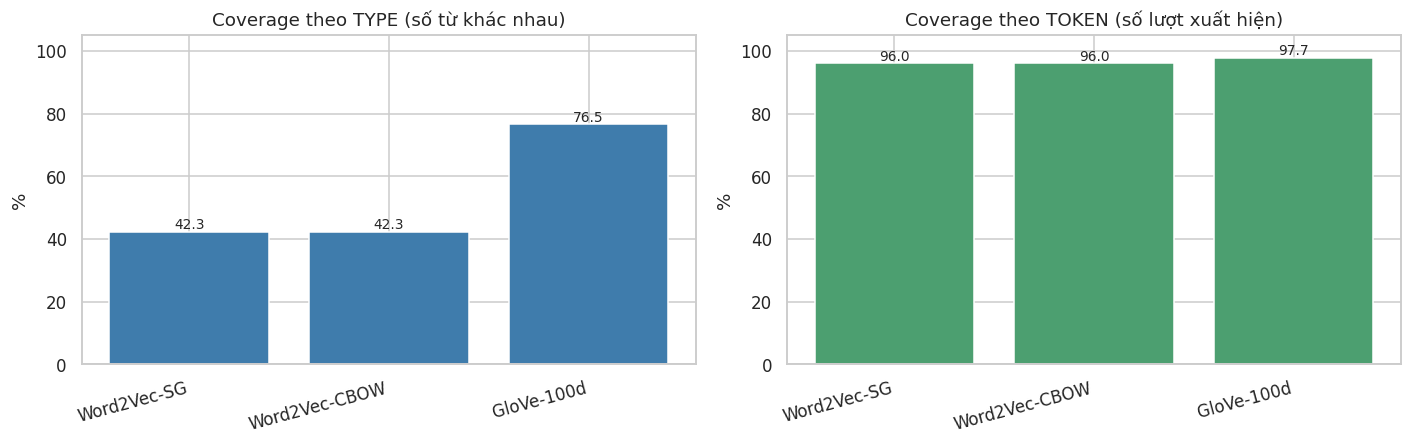

DIỄN GIẢI COVERAGE (sinh tự động từ bảng trên)
* Word2Vec-SG: phủ 42.3% số từ khác nhau nhưng tới 96.0% số lượt token.
    Chênh lệch 53.7 điểm cho thấy phần OOV chủ yếu là TỪ HIẾM;
    ảnh hưởng thực tế lên mô hình nhỏ hơn nhiều so với con số OOV theo type.
* Word2Vec-CBOW: phủ 42.3% số từ khác nhau nhưng tới 96.0% số lượt token.
    Chênh lệch 53.7 điểm cho thấy phần OOV chủ yếu là TỪ HIẾM;
    ảnh hưởng thực tế lên mô hình nhỏ hơn nhiều so với con số OOV theo type.
* GloVe-100d: phủ 76.5% số từ khác nhau nhưng tới 97.7% số lượt token.
    Chênh lệch 21.2 điểm cho thấy phần OOV chủ yếu là TỪ HIẾM;
    ảnh hưởng thực tế lên mô hình nhỏ hơn nhiều so với con số OOV theo type.

* CHÊNH LỆCH CHÍNH: Word2Vec-SG phủ nhiều hơn GloVe-100d -1.68 điểm phần trăm token.

* Từ mà CHỈ GloVe-100d phủ được (Word2Vec bỏ vì min_count):
    reimer, nazi, beatrice, pillows, gryffindor, rhodes, devils, curls, gallstones, janis, boba, dwell
    -> đây thường là từ tiếng Anh CHUẨN MỰC nhưng hiếm trong datas

In [26]:
# ---------- Từ OOV tiêu biểu & biểu đồ coverage -----------------------
for name in EMB_STATS:
    ex = EMB_STATS[name]["oov_examples"][:15]
    if ex:
        print(f"\n[{name}] 15 từ OOV có TẦN SUẤT CAO NHẤT (từ, số lần xuất hiện trong train):")
        print("   " + ", ".join(f"{w}({f})" for w, f in ex))
    else:
        print(f"\n[{name}] Không có từ OOV nào.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
names = list(cov_df.index)
x = np.arange(len(names))
ax[0].bar(x, cov_df["coverage_type_%"], color="#3F7CAC")
ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=15, ha="right")
ax[0].set_ylim(0, 105); ax[0].set_ylabel("%")
ax[0].set_title("Coverage theo TYPE (số từ khác nhau)")
for i, v in enumerate(cov_df["coverage_type_%"]):
    ax[0].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)

ax[1].bar(x, cov_df["coverage_token_%"], color="#4C9F70")
ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=15, ha="right")
ax[1].set_ylim(0, 105); ax[1].set_ylabel("%")
ax[1].set_title("Coverage theo TOKEN (số lượt xuất hiện)")
for i, v in enumerate(cov_df["coverage_token_%"]):
    ax[1].text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

# ---- Diễn giải tự sinh ----------------------------------------------
print("=" * 78)
print("DIỄN GIẢI COVERAGE (sinh tự động từ bảng trên)")
print("=" * 78)
for name in cov_df.index:
    ct, ck = cov_df.loc[name, "coverage_type_%"], cov_df.loc[name, "coverage_token_%"]
    print(f"* {name}: phủ {ct:.1f}% số từ khác nhau nhưng tới {ck:.1f}% số lượt token.")
    gap = ck - ct
    if gap > 5:
        print(f"    Chênh lệch {gap:.1f} điểm cho thấy phần OOV chủ yếu là TỪ HIẾM;")
        print("    ảnh hưởng thực tế lên mô hình nhỏ hơn nhiều so với con số OOV theo type.")
    elif gap < -2:
        print("    Coverage theo token THẤP hơn theo type -> đang thiếu cả những từ PHỔ BIẾN,")
        print("    đây là dấu hiệu lệch miền/lệch ngôn ngữ nghiêm trọng.")
if glove_label and glove_label in cov_df.index:
    w2v_ck = cov_df.loc["Word2Vec-SG", "coverage_token_%"]
    gl_ck = cov_df.loc[glove_label, "coverage_token_%"]
    d = w2v_ck - gl_ck
    print(f"\n* CHÊNH LỆCH CHÍNH: Word2Vec-SG phủ nhiều hơn {glove_label} "
          f"{d:+.2f} điểm phần trăm token.")
    only_glove = [w for w, f in EMB_STATS["Word2Vec-SG"]["oov_examples"]
                  if w in EMB_SOURCES[glove_label]][:12]
    only_w2v = [w for w, f in EMB_STATS[glove_label]["oov_examples"]
                if w in EMB_SOURCES["Word2Vec-SG"]][:12]
    if only_glove:
        print(f"\n* Từ mà CHỈ {glove_label} phủ được (Word2Vec bỏ vì min_count):")
        print("    " + ", ".join(only_glove))
        print("    -> đây thường là từ tiếng Anh CHUẨN MỰC nhưng hiếm trong dataset nhỏ này.")
    if only_w2v:
        print(f"\n* Từ mà CHỈ Word2Vec phủ được ({glove_label} không có):")
        print("    " + ", ".join(only_w2v))
        print("    -> đây thường là từ lóng / viết tắt / sai chính tả — đặc sản của miền dữ liệu.")
    print("\n  Hai danh sách trên là minh hoạ cô đọng nhất cho đánh đổi KHỚP MIỀN vs LƯỢNG DỮ LIỆU.")
    if d > 0:
        print("  -> Word2Vec tự huấn luyện thắng ở khoản KHỚP MIỀN (đúng như dự đoán:")
        print("     nó học từ chính ngữ liệu này nên biết mọi từ lóng/viết tắt),")
        print("     nhưng mỗi vector của nó chỉ dựa trên vài trăm nghìn token.")
        print("     Câu hỏi còn lại: lợi thế coverage đó có bù được chất lượng vector không?")
        print("     -> Phần 14 sẽ trả lời bằng macro-F1 trên tập test.")
    else:
        print(f"  -> {glove_label} phủ tốt hơn cả Word2Vec in-domain, một kết quả đáng chú ý:")
        print("     nghĩa là min_count đã loại khá nhiều từ khỏi từ vựng Word2Vec.")

In [27]:
# =====================================================================
#  12.3 Mã hoá văn bản thành chuỗi chỉ số + khởi tạo nn.Embedding
# =====================================================================
def encode(tokens, max_len=None):
    max_len = max_len or MAX_LEN
    ids = [stoi.get(t, 1) for t in tokens[:max_len]]          # 1 = <unk>
    return ids + [0] * (max_len - len(ids))                   # 0 = <pad>


X_train = np.array([encode(t) for t in df_train["tokens"]], dtype=np.int64)
X_val   = np.array([encode(t) for t in df_val["tokens"]],   dtype=np.int64)
X_test  = np.array([encode(t) for t in df_test["tokens"]],  dtype=np.int64)

print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")
unk_rate = float((X_train == 1).sum() / max((X_train != 0).sum(), 1))
print(f"Tỉ lệ token <unk> trong train (trên token không phải pad): {unk_rate*100:.2f}%")

print("\nVí dụ mã hoá:")
_t = df_train['tokens'].iloc[0][:MAX_LEN]
print("  tokens :", _t)
print("  ids    :", encode(df_train['tokens'].iloc[0])[:len(_t) + 3], "...")


def make_embedding_layer(name, freeze=True):
    """Tạo nn.Embedding khởi tạo từ ma trận embedding đã dựng."""
    M = EMB_MATRICES[name]
    emb = nn.Embedding.from_pretrained(
        torch.tensor(M, dtype=torch.float32),
        freeze=freeze,
        padding_idx=0,
    )
    return emb


_demo = make_embedding_layer(list(EMB_MATRICES)[0], freeze=True)
print(f"\nVí dụ nn.Embedding: {_demo}  | trainable = {_demo.weight.requires_grad}")
print("  padding_idx=0 -> vector của <pad> luôn bằng 0 và không nhận gradient.")
del _demo

X_train (24423, 25) | X_val (3053, 25) | X_test (3533, 25)
Tỉ lệ token <unk> trong train (trên token không phải pad): 0.00%

Ví dụ mã hoá:
  tokens : ['and', 'i', 'wish', 'i', 'gave', 'you', 'one', 'last', 'kiss']
  ids    : [9, 2, 108, 2, 584, 8, 55, 94, 1297, 0, 0, 0] ...

Ví dụ nn.Embedding: Embedding(22032, 100, padding_idx=0)  | trainable = False
  padding_idx=0 -> vector của <pad> luôn bằng 0 và không nhận gradient.


---
# BỘ PHÂN LOẠI

## 13. Thiết kế thí nghiệm so sánh

Nguyên tắc xuyên suốt đã nêu ở phần 2, nay được cụ thể hoá:

* **Cố định:** cách tiền xử lý, từ vựng, `MAX_LEN`, cách chia dữ liệu, seed, kiến trúc mạng,
  optimizer, learning rate, batch size, tiêu chí early stopping, số chiều vector (100).
* **Thay đổi duy nhất:** ma trận khởi tạo cho `nn.Embedding`.

**Các mô hình:**

| Mô hình | Vai trò | Ghi chú |
|---|---|---|
| **TF-IDF + LinearSVC** | Mốc **phi-nơ-ron** | Không dùng embedding. Đây là mốc "sanity check" cực kỳ quan trọng: với văn bản ngắn và từ vựng nhỏ, TF-IDF thường **rất mạnh**. Nếu mọi mô hình embedding đều thua TF-IDF thì đó tự nó là một kết luận đáng bàn |
| **Mean-pool + Logistic Regression** | Baseline embedding **đơn giản nhất** | Trung bình các vector từ → hồi quy logistic. Bỏ hoàn toàn thứ tự từ, nên **đo gần như thuần tuý chất lượng vector từ** — chính là thứ ta muốn so sánh. Chạy cho **mọi** nguồn embedding |
| **BiLSTM** | Mô hình **chuỗi** | LSTM hai chiều + pooling có mask (mean ⊕ max). Nắm được thứ tự và phủ định (*"not good"*) |
| **TextCNN** | Mô hình **n-gram** | Conv1D nhiều kích thước kernel (2, 3, 4) + global max-pool. Bắt cụm từ cục bộ, rất hợp với văn bản ngắn (Kim, 2014) |
| **TextCNN (fine-tune emb)** | **Ablation** | Y hệt TextCNN nhưng cho phép cập nhật embedding. Trả lời: *bộ vector nào chịu được fine-tune, bộ nào bị overfit?* |

**Vì sao mặc định đóng băng (freeze) embedding?** Vì mục tiêu là **so sánh chất lượng vector gốc**.
Nếu cho fine-tune ngay từ đầu, mô hình sẽ tự sửa lại vector trong lúc huấn luyện và xoá nhoà chênh
lệch giữa hai nguồn — đúng thứ ta đang muốn đo. Ablation riêng sẽ khảo sát chiều ngược lại.

In [28]:
# =====================================================================
#  13.1 Baseline phi-nơ-ron: TF-IDF + LinearSVC
# =====================================================================
RESULTS = []   # mỗi phần tử là một dict kết quả trên tập TEST


def eval_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p_ma, r_ma, f_ma, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    return dict(accuracy=acc, macro_precision=p_ma, macro_recall=r_ma, macro_f1=f_ma,
                weighted_precision=p_w, weighted_recall=r_w, weighted_f1=f_w)


train_texts = [" ".join(t) for t in df_train["tokens"]]
val_texts   = [" ".join(t) for t in df_val["tokens"]]
test_texts  = [" ".join(t) for t in df_test["tokens"]]

t0 = time.time()
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True, max_features=200_000)
Xtr_tfidf = tfidf.fit_transform(train_texts)
Xva_tfidf = tfidf.transform(val_texts)
Xte_tfidf = tfidf.transform(test_texts)

svc = LinearSVC(C=0.5, class_weight="balanced", random_state=SEED, max_iter=5000)
svc.fit(Xtr_tfidf, y_train)
tfidf_time = time.time() - t0

pred_val = svc.predict(Xva_tfidf)
pred_test = svc.predict(Xte_tfidf)
m = eval_metrics(y_test, pred_test)
RESULTS.append(dict(classifier="TF-IDF + LinearSVC", embedding="(không dùng embedding)",
                    train_time_s=tfidf_time, epochs=1,
                    val_macro_f1=f1_score(y_val, pred_val, average="macro", zero_division=0),
                    y_pred=pred_test, **m))

print(f"TF-IDF + LinearSVC   ({Xtr_tfidf.shape[1]:,} đặc trưng, {tfidf_time:.1f}s)")
print(f"  val  macro-F1 : {RESULTS[-1]['val_macro_f1']:.4f}")
print(f"  test accuracy : {m['accuracy']:.4f}")
print(f"  test macro-F1 : {m['macro_f1']:.4f}")
print("\n-> Đây là mốc tham chiếu. Mọi mô hình embedding phía dưới sẽ được so với con số này.")

TF-IDF + LinearSVC   (34,504 đặc trưng, 1.2s)
  val  macro-F1 : 0.6824
  test accuracy : 0.6920
  test macro-F1 : 0.6955

-> Đây là mốc tham chiếu. Mọi mô hình embedding phía dưới sẽ được so với con số này.


In [29]:
# =====================================================================
#  13.2 Baseline embedding: Mean-pool + Logistic Regression
#       (chạy cho MỌI nguồn embedding -> đo gần như thuần chất lượng vector từ)
# =====================================================================
def mean_pool_features(M, X, chunk=2048):
    """Trung bình các vector từ, bỏ qua <pad>. Tính theo lô để tiết kiệm RAM."""
    out = np.zeros((X.shape[0], M.shape[1]), dtype=np.float32)
    for s in range(0, X.shape[0], chunk):
        xb = X[s:s + chunk]
        mask = (xb != 0).astype(np.float32)[:, :, None]
        V = M[xb] * mask
        out[s:s + chunk] = V.sum(axis=1) / np.clip(mask.sum(axis=1), 1e-6, None)
    return out


for name in EMB_MATRICES:
    M = EMB_MATRICES[name]
    t0 = time.time()
    Ftr = mean_pool_features(M, X_train)
    Fva = mean_pool_features(M, X_val)
    Fte = mean_pool_features(M, X_test)
    clf = LogisticRegression(max_iter=3000, C=5.0, class_weight="balanced",
                             random_state=SEED, n_jobs=-1)
    clf.fit(Ftr, y_train)
    dt = time.time() - t0
    pv, pt = clf.predict(Fva), clf.predict(Fte)
    mm = eval_metrics(y_test, pt)
    RESULTS.append(dict(classifier="MeanPool + LogReg", embedding=name,
                        train_time_s=dt, epochs=1,
                        val_macro_f1=f1_score(y_val, pv, average="macro", zero_division=0),
                        y_pred=pt, **mm))
    print(f"MeanPool + LogReg | {name:<18} | dim={M.shape[1]:<4} | {dt:5.1f}s | "
          f"val macroF1={RESULTS[-1]['val_macro_f1']:.4f} | "
          f"test acc={mm['accuracy']:.4f} | test macroF1={mm['macro_f1']:.4f}")

print("""
CÁCH ĐỌC BẢNG TRÊN:
  MeanPool + LogReg vứt bỏ hoàn toàn thứ tự từ, nên chênh lệch điểm giữa các dòng
  gần như CHỈ phản ánh chất lượng của bản thân các vector từ. Đây là phép so sánh
  Word2Vec vs GloVe SẠCH NHẤT trong toàn bộ notebook — các mô hình sâu phía dưới
  mạnh hơn nhưng cũng che bớt khác biệt vì chúng tự học thêm biểu diễn.""")

MeanPool + LogReg | Word2Vec-SG        | dim=100  |   1.9s | val macroF1=0.5785 | test acc=0.6020 | test macroF1=0.6037
MeanPool + LogReg | Word2Vec-CBOW      | dim=100  |   1.6s | val macroF1=0.5888 | test acc=0.6040 | test macroF1=0.6058
MeanPool + LogReg | GloVe-100d         | dim=100  |   2.1s | val macroF1=0.5957 | test acc=0.5950 | test macroF1=0.5986

CÁCH ĐỌC BẢNG TRÊN:
  MeanPool + LogReg vứt bỏ hoàn toàn thứ tự từ, nên chênh lệch điểm giữa các dòng
  gần như CHỈ phản ánh chất lượng của bản thân các vector từ. Đây là phép so sánh
  Word2Vec vs GloVe SẠCH NHẤT trong toàn bộ notebook — các mô hình sâu phía dưới
  mạnh hơn nhưng cũng che bớt khác biệt vì chúng tự học thêm biểu diễn.


---
## 14. Mô hình nơ-ron: BiLSTM và TextCNN

**BiLSTM** — embedding → LSTM hai chiều → **pooling có mask** (nối `mean` ⊕ `max` trên các vị trí
không phải `<pad>`) → dropout → linear. Dùng mask thay vì lấy hidden state cuối là quan trọng: với
chuỗi có đệm, hidden state cuối rơi vào vùng `<pad>`. Nối mean ⊕ max cho mô hình vừa thấy "trung bình
toàn câu" vừa thấy "tín hiệu mạnh nhất" — với câu ngắn, một từ cảm xúc đơn lẻ đã đủ quyết định nhãn.

**TextCNN** (Kim, 2014) — embedding → nhiều Conv1D song song kernel 2/3/4 (≈ bigram, trigram,
4-gram) → global max-pool từng nhánh → nối → dropout → linear. Rất hợp văn bản ngắn: nó tìm cụm từ
quyết định (*"not worth it"*, *"love this"*) bất kể vị trí trong câu.

**Chi tiết huấn luyện dùng chung cho mọi lần chạy:**

* `CrossEntropyLoss` với **class weight** = `N / (n_class × count_c)` để bù mất cân bằng;
* `Adam`, `lr = 1e-3`;
* **Early stopping theo macro-F1 trên tập validation**, `patience = 3` — dùng macro-F1 chứ không
  dùng val-loss vì macro-F1 mới đúng là chỉ số ta quan tâm và không bị lớp trội chi phối;
* **giữ lại checkpoint tốt nhất** (state_dict tại epoch có val macro-F1 cao nhất) rồi mới đánh giá
  trên test — tuyệt đối không lấy epoch cuối;
* tập test **chỉ được chạm vào đúng một lần**, sau khi mọi lựa chọn đã chốt trên val.

In [30]:
# =====================================================================
#  14.1 Dataset / DataLoader
# =====================================================================
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(X, y, shuffle=False):
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(TextDataset(X, y), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                      drop_last=False, generator=g if shuffle else None,
                      persistent_workers=(NUM_WORKERS > 0))


train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)
print(f"Số batch: train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")

# Class weight cho hàm loss
cnt = np.bincount(y_train, minlength=N_CLASSES).astype(np.float32)
class_weights = torch.tensor(len(y_train) / (N_CLASSES * np.maximum(cnt, 1)),
                             dtype=torch.float32, device=DEVICE)
print("\nTrọng số lớp trong CrossEntropyLoss:")
for c, w, n in zip(CLASS_NAMES, class_weights.tolist(), cnt):
    print(f"  {c:>12}: n={int(n):>6,}  weight={w:.3f}")

Số batch: train=191  val=24  test=28

Trọng số lớp trong CrossEntropyLoss:
      negative: n= 6,916  weight=1.177
       neutral: n= 9,879  weight=0.824
      positive: n= 7,628  weight=1.067


In [31]:
# =====================================================================
#  14.2 Kiến trúc mô hình
# =====================================================================
class BiLSTMClassifier(nn.Module):
    def __init__(self, emb_matrix, n_classes, hidden=LSTM_HIDDEN,
                 dropout=DROPOUT, freeze=True):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype=torch.float32), freeze=freeze, padding_idx=0)
        dim = self.emb.embedding_dim
        self.lstm = nn.LSTM(dim, hidden, num_layers=1, batch_first=True,
                            bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 4, n_classes)   # (mean ⊕ max) × 2 chiều

    def forward(self, x):
        mask = (x != 0).unsqueeze(-1).float()             # (B, L, 1)
        h, _ = self.lstm(self.emb(x))                     # (B, L, 2H)
        h = h * mask
        mean = h.sum(1) / mask.sum(1).clamp(min=1e-6)
        mx = h.masked_fill(mask == 0, -1e4).max(1).values
        return self.fc(self.drop(torch.cat([mean, mx], dim=1)))


class TextCNNClassifier(nn.Module):
    def __init__(self, emb_matrix, n_classes, n_filters=CNN_FILTERS,
                 kernels=CNN_KERNELS, dropout=DROPOUT, freeze=True):
        super().__init__()
        self.emb = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype=torch.float32), freeze=freeze, padding_idx=0)
        dim = self.emb.embedding_dim
        self.convs = nn.ModuleList([
            nn.Conv1d(dim, n_filters, kernel_size=k, padding=k - 1) for k in kernels])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(kernels), n_classes)

    def forward(self, x):
        e = self.emb(x).transpose(1, 2)                   # (B, D, L)
        feats = [F.relu(c(e)).max(dim=2).values for c in self.convs]
        return self.fc(self.drop(torch.cat(feats, dim=1)))


MODEL_BUILDERS = {
    "BiLSTM":  BiLSTMClassifier,
    "TextCNN": TextCNNClassifier,
}

# In số tham số để thấy chi phí của việc cho embedding fine-tune
for mname, builder in MODEL_BUILDERS.items():
    _m = builder(EMB_MATRICES[list(EMB_MATRICES)[0]], N_CLASSES, freeze=True)
    tot = sum(p.numel() for p in _m.parameters())
    trn = sum(p.numel() for p in _m.parameters() if p.requires_grad)
    print(f"{mname:<9}: tổng {tot:,} tham số | huấn luyện được {trn:,} "
          f"({trn/tot*100:.1f}%) khi ĐÓNG BĂNG embedding")
    del _m

BiLSTM   : tổng 2,440,259 tham số | huấn luyện được 237,059 (9.7%) khi ĐÓNG BĂNG embedding
TextCNN  : tổng 2,294,403 tham số | huấn luyện được 91,203 (4.0%) khi ĐÓNG BĂNG embedding


In [32]:
# =====================================================================
#  14.3 Vòng huấn luyện dùng chung
# =====================================================================
import copy


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds, trues, losses = [], [], []
    crit = nn.CrossEntropyLoss(weight=class_weights)
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        out = model(xb)
        losses.append(crit(out, yb).item() * len(yb))
        preds.append(out.argmax(1).cpu().numpy())
        trues.append(yb.cpu().numpy())
    y_p = np.concatenate(preds); y_t = np.concatenate(trues)
    return y_t, y_p, float(np.sum(losses) / len(y_t))


def train_model(model, run_name, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR):
    set_seed(SEED)
    model = model.to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=1)

    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
    best_f1, best_state, best_epoch, bad = -1.0, None, -1, 0
    t0 = time.time()

    for ep in range(1, max_epochs + 1):
        model.train()
        run_loss, run_correct, run_n = 0.0, 0, 0
        bar = tqdm(train_loader, desc=f"{run_name} | epoch {ep}/{max_epochs}", leave=False)
        for xb, yb in bar:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            out = model(xb)
            loss = crit(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 5.0)
            opt.step()
            run_loss += loss.item() * len(yb)
            run_correct += (out.argmax(1) == yb).sum().item()
            run_n += len(yb)
            bar.set_postfix(loss=f"{run_loss/run_n:.4f}", acc=f"{run_correct/run_n:.4f}")

        yv_t, yv_p, v_loss = predict_loader(model, val_loader)
        v_acc = accuracy_score(yv_t, yv_p)
        v_f1 = f1_score(yv_t, yv_p, average="macro", zero_division=0)
        sched.step(v_f1)

        hist["train_loss"].append(run_loss / run_n)
        hist["train_acc"].append(run_correct / run_n)
        hist["val_loss"].append(v_loss)
        hist["val_acc"].append(v_acc)
        hist["val_macro_f1"].append(v_f1)

        flag = ""
        if v_f1 > best_f1:
            best_f1, best_epoch, bad = v_f1, ep, 0
            best_state = copy.deepcopy(model.state_dict())
            flag = "  <-- tốt nhất"
        else:
            bad += 1
        print(f"  ep {ep:>2}/{max_epochs} | train_loss {hist['train_loss'][-1]:.4f} "
              f"acc {hist['train_acc'][-1]:.4f} | val_loss {v_loss:.4f} acc {v_acc:.4f} "
              f"macroF1 {v_f1:.4f}{flag}")
        if bad >= patience:
            print(f"  -> Early stopping ở epoch {ep} (không cải thiện {patience} epoch liên tiếp).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    dt = time.time() - t0
    print(f"  Xong sau {dt:.1f}s | epoch tốt nhất = {best_epoch} | val macro-F1 = {best_f1:.4f}")
    return model, hist, dict(train_time_s=dt, epochs=len(hist["train_loss"]),
                             best_epoch=best_epoch, val_macro_f1=best_f1)

In [33]:
# =====================================================================
#  14.4 Chạy toàn bộ thí nghiệm:  {BiLSTM, TextCNN} × {Word2Vec, GloVe}
# =====================================================================
DEEP_EMB_KEYS = [k for k in ["Word2Vec-SG"] + ([glove_label] if glove_label else [])
                 if k in EMB_MATRICES]
print("Các nguồn embedding dùng cho mô hình sâu:", DEEP_EMB_KEYS)
if len(DEEP_EMB_KEYS) < 2:
    print("CẢNH BÁO: chỉ có 1 nguồn embedding -> phần so sánh sẽ không đầy đủ. "
          "Xem lại ô nạp GloVe ở phần 11.")

EXPERIMENTS = []
for emb in DEEP_EMB_KEYS:
    EXPERIMENTS.append(("BiLSTM", emb, True))
    EXPERIMENTS.append(("TextCNN", emb, True))
if RUN_TRAINABLE_ABLATION:
    for emb in DEEP_EMB_KEYS:
        EXPERIMENTS.append(("TextCNN", emb, False))

HISTORIES = {}
for mname, emb, freeze in EXPERIMENTS:
    label = mname if freeze else f"{mname} (fine-tune emb)"
    run_name = f"{label} | {emb}"
    print("\n" + "=" * 78)
    print(f"CHẠY: {run_name}    (embedding {'ĐÓNG BĂNG' if freeze else 'CHO HUẤN LUYỆN'})")
    print("=" * 78)
    set_seed(SEED)
    model = MODEL_BUILDERS[mname](EMB_MATRICES[emb], N_CLASSES, freeze=freeze)
    model, hist, info = train_model(model, run_name)
    HISTORIES[run_name] = hist

    yt, yp, _ = predict_loader(model, test_loader)
    mm = eval_metrics(yt, yp)
    RESULTS.append(dict(classifier=label, embedding=emb, y_pred=yp, **info, **mm))
    print(f"  TEST: accuracy = {mm['accuracy']:.4f} | macro-F1 = {mm['macro_f1']:.4f} "
          f"| weighted-F1 = {mm['weighted_f1']:.4f}")
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nHoàn tất {len(EXPERIMENTS)} lần chạy mô hình sâu. Tổng số kết quả: {len(RESULTS)}.")

Các nguồn embedding dùng cho mô hình sâu: ['Word2Vec-SG', 'GloVe-100d']

CHẠY: BiLSTM | Word2Vec-SG    (embedding ĐÓNG BĂNG)


BiLSTM | Word2Vec-SG | epoch 1/15:   0%|          | 0/191 [00:00<?, ?it/s]

  ep  1/15 | train_loss 0.8791 acc 0.5712 | val_loss 0.8122 acc 0.6194 macroF1 0.6216  <-- tốt nhất


BiLSTM | Word2Vec-SG | epoch 2/15:   0%|          | 0/191 [00:00<?, ?it/s]

  ep  2/15 | train_loss 0.7539 acc 0.6662 | val_loss 0.7496 acc 0.6607 macroF1 0.6633  <-- tốt nhất


...

  ep  5/15 | train_loss 0.4097 acc 0.8386 | val_loss 0.6738 acc 0.7239 macroF1 0.7281


TextCNN (fine-tune emb) | GloVe-100d | epoch 6/15:   0%|          | 0/191 [00:00<?, ?it/s]

  ep  6/15 | train_loss 0.3441 acc 0.8700 | val_loss 0.7503 acc 0.7193 macroF1 0.7237


TextCNN (fine-tune emb) | GloVe-100d | epoch 7/15:   0%|          | 0/191 [00:00<?, ?it/s]

  ep  7/15 | train_loss 0.2690 acc 0.9035 | val_loss 0.7718 acc 0.7196 macroF1 0.7237
  -> Early stopping ở epoch 7 (không cải thiện 3 epoch liên tiếp).
  Xong sau 6.6s | epoch tốt nhất = 4 | val macro-F1 = 0.7341
  TEST: accuracy = 0.7288 | macro-F1 = 0.7310 | weighted-F1 = 0.7290

Hoàn tất 6 lần chạy mô hình sâu. Tổng số kết quả: 10.


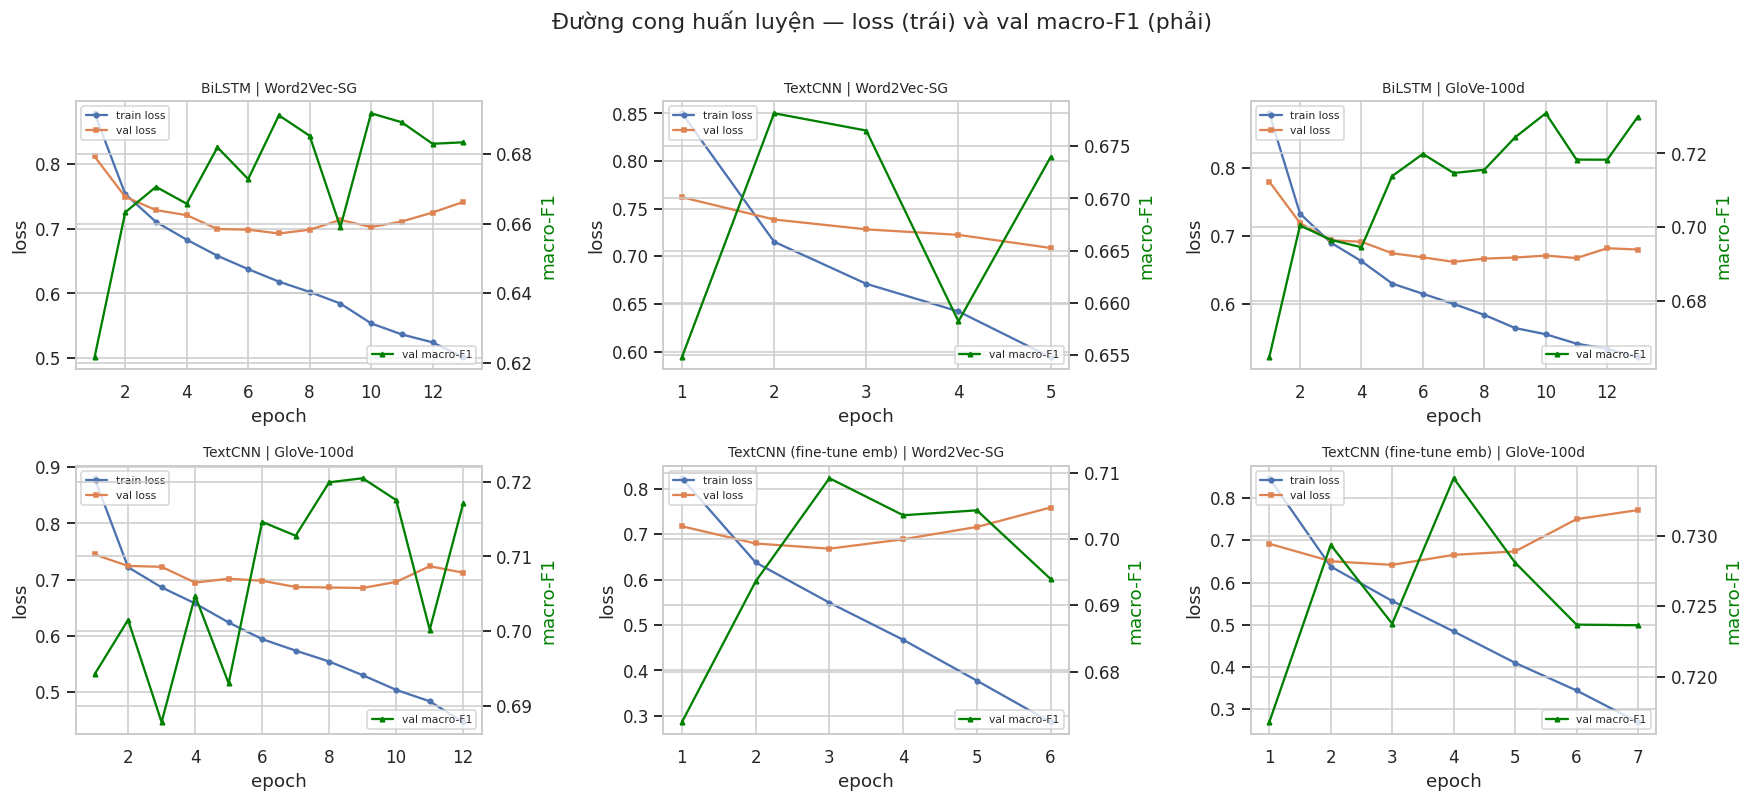

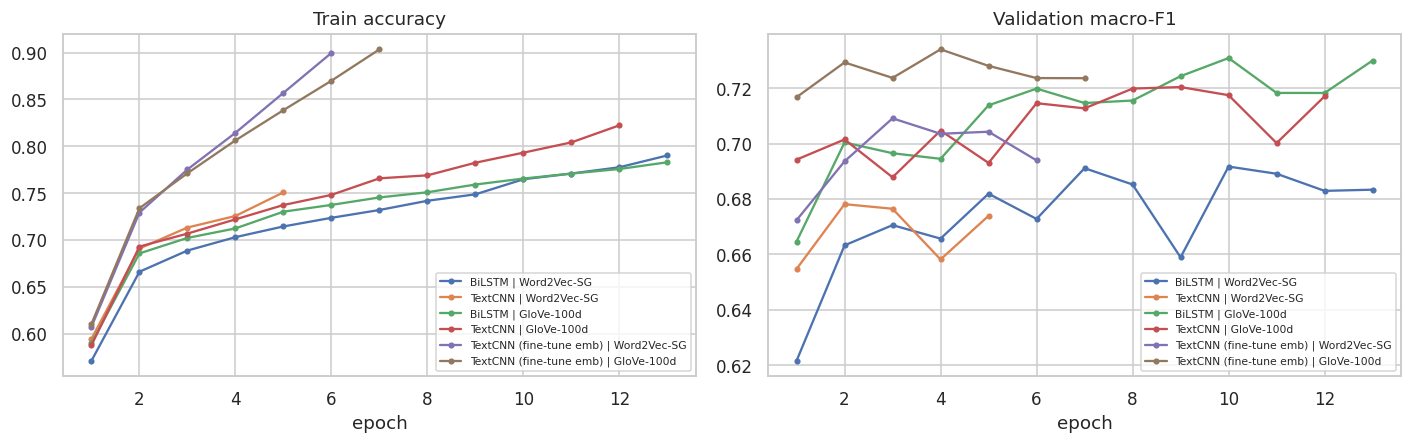

In [34]:
# =====================================================================
#  14.5 Đường cong huấn luyện
# =====================================================================
n_runs = len(HISTORIES)
if n_runs:
    ncol = 3
    nrow = int(np.ceil(n_runs / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 3.6 * nrow), squeeze=False)
    for i, (name, h) in enumerate(HISTORIES.items()):
        a = axes[i // ncol][i % ncol]
        ep = range(1, len(h["train_loss"]) + 1)
        a.plot(ep, h["train_loss"], "-o", ms=3, label="train loss")
        a.plot(ep, h["val_loss"], "-s", ms=3, label="val loss")
        a2 = a.twinx()
        a2.plot(ep, h["val_macro_f1"], "-^", ms=3, color="green", label="val macro-F1")
        a2.set_ylabel("macro-F1", color="green")
        a.set_title(name, fontsize=9)
        a.set_xlabel("epoch"); a.set_ylabel("loss")
        a.legend(loc="upper left", fontsize=7)
        a2.legend(loc="lower right", fontsize=7)
    for j in range(n_runs, nrow * ncol):
        axes[j // ncol][j % ncol].axis("off")
    plt.suptitle("Đường cong huấn luyện — loss (trái) và val macro-F1 (phải)", y=1.01)
    plt.tight_layout(); plt.show()

    # Accuracy đặt cạnh nhau để so trực tiếp giữa các nguồn embedding
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    for name, h in HISTORIES.items():
        ep = range(1, len(h["train_acc"]) + 1)
        ax[0].plot(ep, h["train_acc"], "-o", ms=3, label=name)
        ax[1].plot(ep, h["val_macro_f1"], "-o", ms=3, label=name)
    ax[0].set_title("Train accuracy"); ax[0].set_xlabel("epoch")
    ax[1].set_title("Validation macro-F1"); ax[1].set_xlabel("epoch")
    ax[1].legend(fontsize=7, loc="lower right")
    ax[0].legend(fontsize=7, loc="lower right")
    plt.tight_layout(); plt.show()
else:
    print("Không có lịch sử huấn luyện để vẽ.")

---
## 15. Đánh giá trên tập test

Tập test **chỉ được chạm vào một lần duy nhất**, sau khi mọi lựa chọn (số epoch, checkpoint tốt nhất)
đã được chốt hoàn toàn trên tập validation.

Chỉ số chính là **macro-F1** vì dữ liệu mất cân bằng; accuracy và weighted-F1 báo cáo kèm để tham khảo.

In [35]:
# =====================================================================
#  15.1 Bảng kết quả tổng hợp
# =====================================================================
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != "y_pred"} for r in RESULTS])
cols = ["classifier", "embedding", "accuracy", "macro_f1", "weighted_f1",
        "macro_precision", "macro_recall", "val_macro_f1", "train_time_s", "epochs"]
cols = [c for c in cols if c in res_df.columns]
res_df = res_df[cols].sort_values("macro_f1", ascending=False).reset_index(drop=True)

show = res_df.copy()
for c in ["accuracy", "macro_f1", "weighted_f1", "macro_precision", "macro_recall", "val_macro_f1"]:
    if c in show.columns:
        show[c] = show[c].round(4)
show["train_time_s"] = show["train_time_s"].round(1)

print("=" * 110)
print("KẾT QUẢ TRÊN TẬP TEST — xếp theo macro-F1 giảm dần")
print("=" * 110)
print(show.to_string(index=False))

out_csv = os.path.join(CKPT_DIR, "hw3_results.csv")
res_df.to_csv(out_csv, index=False)
print(f"\nĐã lưu bảng kết quả -> {out_csv}")

KẾT QUẢ TRÊN TẬP TEST — xếp theo macro-F1 giảm dần
             classifier              embedding  accuracy  macro_f1  weighted_f1  macro_precision  macro_recall  val_macro_f1  train_time_s  epochs
TextCNN (fine-tune emb)             GloVe-100d    0.7288    0.7310       0.7290           0.7373        0.7269        0.7341           6.6       7
                 BiLSTM             GloVe-100d    0.7260    0.7288       0.7267           0.7328        0.7257        0.7309          12.9      13
                TextCNN             GloVe-100d    0.7127    0.7161       0.7137           0.7196        0.7138        0.7205          10.3      12
TextCNN (fine-tune emb)            Word2Vec-SG    0.7119    0.7152       0.7105           0.7119        0.7201        0.7092           5.7       6
                 BiLSTM            Word2Vec-SG    0.7025    0.7042       0.7011           0.7038        0.7065        0.6917          12.9      13
     TF-IDF + LinearSVC (không dùng embedding)    0.6920    0.6955 

MACRO-F1 (hàng = bộ phân loại, cột = nguồn embedding)
embedding                (không dùng embedding)  GloVe-100d  Word2Vec-CBOW  Word2Vec-SG
classifier                                                                             
BiLSTM                                      NaN      0.7288            NaN       0.7042
MeanPool + LogReg                           NaN      0.5986         0.6058       0.6037
TF-IDF + LinearSVC                       0.6955         NaN            NaN          NaN
TextCNN                                     NaN      0.7161            NaN       0.6951
TextCNN (fine-tune emb)                     NaN      0.7310            NaN       0.7152

ACCURACY
embedding                (không dùng embedding)  GloVe-100d  Word2Vec-CBOW  Word2Vec-SG
classifier                                                                             
BiLSTM                                      NaN      0.7260            NaN       0.7025
MeanPool + LogReg                           NaN      0.5

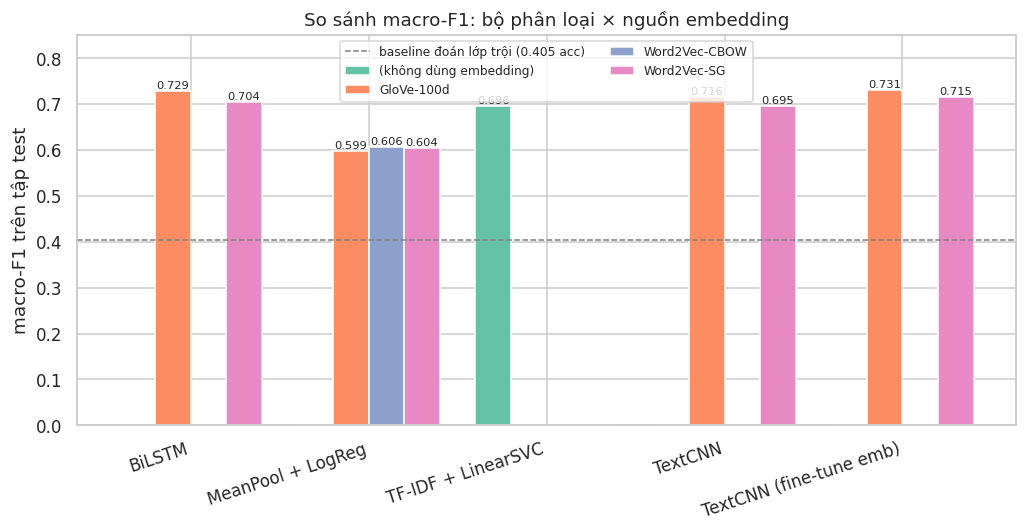

In [36]:
# =====================================================================
#  15.2 Bảng chéo: hàng = bộ phân loại, cột = nguồn embedding
# =====================================================================
pivot_f1 = res_df.pivot_table(index="classifier", columns="embedding",
                              values="macro_f1", aggfunc="max")
pivot_acc = res_df.pivot_table(index="classifier", columns="embedding",
                               values="accuracy", aggfunc="max")

print("MACRO-F1 (hàng = bộ phân loại, cột = nguồn embedding)")
print(pivot_f1.round(4).to_string())
print("\nACCURACY")
print(pivot_acc.round(4).to_string())

# ---- Biểu đồ cột nhóm ------------------------------------------------
plot_df = pivot_f1.copy()
embs = [c for c in plot_df.columns]
clfs = list(plot_df.index)
x = np.arange(len(clfs))
w = 0.8 / max(len(embs), 1)

fig, ax = plt.subplots(figsize=(max(9, 1.9 * len(clfs)), 5))
for i, e in enumerate(embs):
    vals = plot_df[e].values.astype(float)
    bars = ax.bar(x + i * w - 0.4 + w / 2, np.nan_to_num(vals), width=w,
                  label=str(e), color=sns.color_palette("Set2", len(embs))[i])
    for b, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                    ha="center", fontsize=7.5)
ax.axhline(majority_baseline, color="gray", ls="--", lw=1,
           label=f"baseline đoán lớp trội ({majority_baseline:.3f} acc)")
ax.set_xticks(x); ax.set_xticklabels(clfs, rotation=18, ha="right")
ax.set_ylabel("macro-F1 trên tập test")
ax.set_title("So sánh macro-F1: bộ phân loại × nguồn embedding")
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(0, min(1.0, np.nanmax(plot_df.values.astype(float)) + 0.12))
plt.tight_layout(); plt.show()

BiLSTM  |  GloVe-100d
              precision    recall  f1-score   support

    negative     0.7153    0.7003    0.7077      1001
     neutral     0.6803    0.7208    0.7000      1429
    positive     0.8027    0.7561    0.7787      1103

    accuracy                         0.7260      3533
   macro avg     0.7328    0.7257    0.7288      3533
weighted avg     0.7284    0.7260    0.7267      3533

TextCNN  |  GloVe-100d
              precision    recall  f1-score   support

    negative     0.6907    0.7073    0.6989      1001
     neutral     0.6693    0.6998    0.6842      1429
    positive     0.7988    0.7344    0.7652      1103

    accuracy                         0.7127      3533
   macro avg     0.7196    0.7138    0.7161      3533
weighted avg     0.7158    0.7127    0.7137      3533

BiLSTM  |  Word2Vec-SG
              precision    recall  f1-score   support

    negative     0.7079    0.6683    0.6876      1001
     neutral     0.6816    0.6515    0.6662      1429
    pos

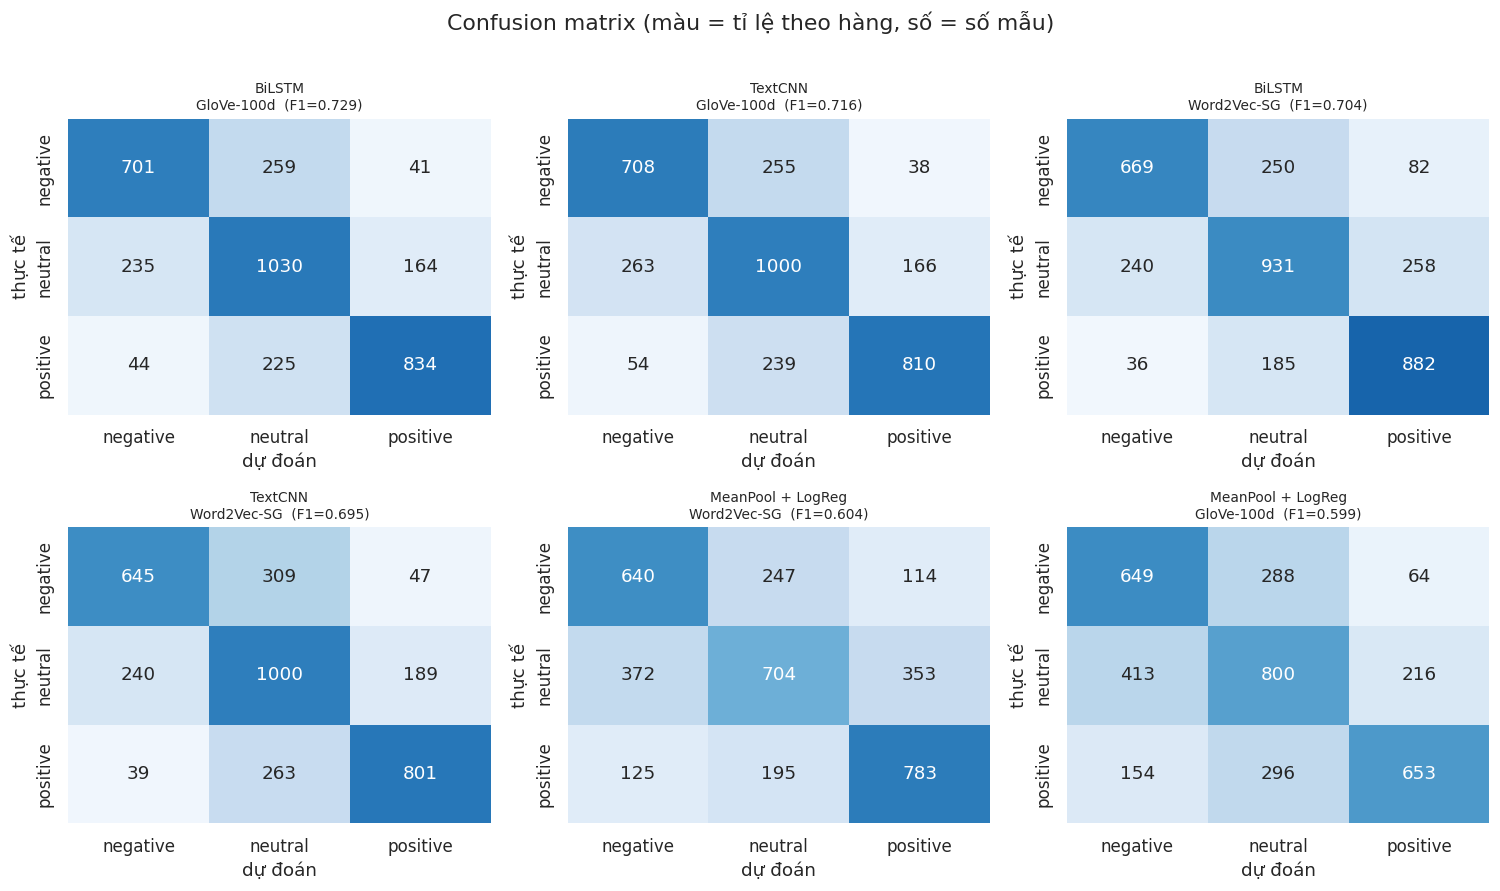

In [37]:
# =====================================================================
#  15.3 Báo cáo theo lớp + confusion matrix cho các mô hình chính
# =====================================================================
key_runs = [r for r in RESULTS
            if r["classifier"] in ("BiLSTM", "TextCNN", "MeanPool + LogReg")
            and r["embedding"] in DEEP_EMB_KEYS]
if not key_runs:
    key_runs = RESULTS[:4]
key_runs = sorted(key_runs, key=lambda r: -r["macro_f1"])[:6]

for r in key_runs:
    print("=" * 78)
    print(f"{r['classifier']}  |  {r['embedding']}")
    print("=" * 78)
    print(classification_report(y_test, r["y_pred"], target_names=CLASS_NAMES,
                                digits=4, zero_division=0))

n = len(key_runs)
ncol = min(3, n)
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 4.0 * nrow), squeeze=False)
for i, r in enumerate(key_runs):
    cm = confusion_matrix(y_test, r["y_pred"])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    a = axes[i // ncol][i % ncol]
    sns.heatmap(cmn, annot=cm, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=a, vmin=0, vmax=1)
    a.set_title(f"{r['classifier']}\n{r['embedding']}  (F1={r['macro_f1']:.3f})", fontsize=9)
    a.set_xlabel("dự đoán"); a.set_ylabel("thực tế")
for j in range(n, nrow * ncol):
    axes[j // ncol][j % ncol].axis("off")
plt.suptitle("Confusion matrix (màu = tỉ lệ theo hàng, số = số mẫu)", y=1.01)
plt.tight_layout(); plt.show()

F1 THEO TỪNG LỚP
                                       negative  neutral  positive
MeanPool + LogReg | Word2Vec-SG          0.5987   0.5468    0.6655
MeanPool + LogReg | GloVe-100d           0.5855   0.5688    0.6415
BiLSTM | Word2Vec-SG                     0.6876   0.6662    0.7587
TextCNN | Word2Vec-SG                    0.6701   0.6664    0.7486
BiLSTM | GloVe-100d                      0.7077   0.7000    0.7787
TextCNN | GloVe-100d                     0.6989   0.6842    0.7652
TextCNN (fine-tune emb) | Word2Vec-SG    0.7047   0.6611    0.7797
TextCNN (fine-tune emb) | GloVe-100d     0.7054   0.7012    0.7864


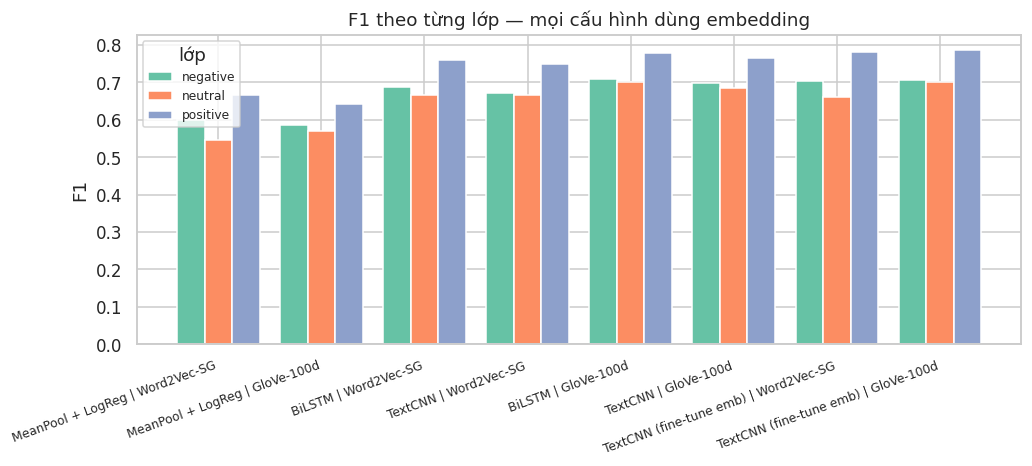


CHÊNH LỆCH F1 THEO LỚP KHI ĐỔI NGUỒN EMBEDDING (cùng bộ phân loại):
  BiLSTM:  Word2Vec-SG - GloVe-100d
          negative: -0.0202
           neutral: -0.0338
          positive: -0.0200
  MeanPool + LogReg:  Word2Vec-SG - GloVe-100d
          negative: +0.0132
           neutral: -0.0220
          positive: +0.0241
  TextCNN:  Word2Vec-SG - GloVe-100d
          negative: -0.0288
           neutral: -0.0178
          positive: -0.0166
  TextCNN (fine-tune emb):  Word2Vec-SG - GloVe-100d
          negative: -0.0006
           neutral: -0.0402
          positive: -0.0067


In [38]:
# =====================================================================
#  15.4 F1 theo từng lớp: Word2Vec vs GloVe
# =====================================================================
if len(DEEP_EMB_KEYS) >= 2:
    per_class = {}
    for r in RESULTS:
        if r["embedding"] in DEEP_EMB_KEYS:
            f1s = f1_score(y_test, r["y_pred"], average=None,
                           labels=list(range(N_CLASSES)), zero_division=0)
            per_class[f"{r['classifier']} | {r['embedding']}"] = f1s
    pc_df = pd.DataFrame(per_class, index=CLASS_NAMES).T
    print("F1 THEO TỪNG LỚP")
    print(pc_df.round(4).to_string())

    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(pc_df)), 4.4))
    xx = np.arange(len(pc_df))
    ww = 0.8 / N_CLASSES
    for i, c in enumerate(CLASS_NAMES):
        ax.bar(xx + i * ww - 0.4 + ww / 2, pc_df[c].values, width=ww, label=c,
               color=PALETTE[i % len(PALETTE)])
    ax.set_xticks(xx); ax.set_xticklabels(pc_df.index, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("F1"); ax.set_title("F1 theo từng lớp — mọi cấu hình dùng embedding")
    ax.legend(title="lớp", fontsize=8)
    plt.tight_layout(); plt.show()

    # Lớp nào hưởng lợi nhiều nhất khi đổi embedding?
    print("\nCHÊNH LỆCH F1 THEO LỚP KHI ĐỔI NGUỒN EMBEDDING (cùng bộ phân loại):")
    for clf_name in pivot_f1.index:
        sub = {e: None for e in DEEP_EMB_KEYS}
        for r in RESULTS:
            if r["classifier"] == clf_name and r["embedding"] in sub:
                sub[r["embedding"]] = f1_score(y_test, r["y_pred"], average=None,
                                               labels=list(range(N_CLASSES)), zero_division=0)
        if all(v is not None for v in sub.values()) and len(sub) == 2:
            a_name, b_name = DEEP_EMB_KEYS[0], DEEP_EMB_KEYS[1]
            diff = sub[a_name] - sub[b_name]
            print(f"  {clf_name}:  {a_name} - {b_name}")
            for c, d in zip(CLASS_NAMES, diff):
                print(f"      {c:>12}: {d:+.4f}")
else:
    print("Chỉ có một nguồn embedding -> bỏ qua so sánh theo lớp.")

---
# 16. SO SÁNH & ĐÁNH GIÁ: Word2Vec vs GloVe

Phần này là trọng tâm được chấm điểm của bài. Ta so trên **sáu trục**, mỗi trục đều dựa trên số liệu
đã in ở trên chứ không phải cảm tính.

In [39]:
# =====================================================================
#  16.1 Bảng tổng hợp sáu trục so sánh
# =====================================================================
summary_rows = []
for name in EMB_MATRICES:
    st = EMB_STATS[name]
    best = res_df[res_df["embedding"] == name]
    build_t = W2V_TIME.get(name, GLOVE_TIME if name == glove_label else float("nan"))
    summary_rows.append({
        "embedding": name,
        "nguồn": ("tự huấn luyện trên train (in-domain)" if name in W2V_MODELS
                  else f"tiền huấn luyện ({GLOVE_SOURCE})"),
        "dim": st["dim"],
        "coverage_type_%": round(st["cov_type"] * 100, 2),
        "coverage_token_%": round(st["cov_token"] * 100, 2),
        "OOV_type": st["oov_types"],
        "thời_gian_tạo_s": round(float(build_t), 1) if build_t == build_t else None,
        "macro_F1_tốt_nhất": round(best["macro_f1"].max(), 4) if len(best) else None,
        "acc_tốt_nhất": round(best["accuracy"].max(), 4) if len(best) else None,
        "mô_hình_tốt_nhất": (best.sort_values("macro_f1", ascending=False)["classifier"].iloc[0]
                             if len(best) else None),
    })
emb_summary = pd.DataFrame(summary_rows).set_index("embedding")
print("=" * 118)
print("BẢNG SO SÁNH TỔNG HỢP CÁC NGUỒN EMBEDDING")
print("=" * 118)
print(emb_summary.to_string())

# Chi phí: thời gian tạo embedding + thời gian huấn luyện mô hình
print("\nCHI PHÍ TÍNH TOÁN")
print(f"  Huấn luyện Word2Vec-SG   : {W2V_TIME.get('Word2Vec-SG', float('nan')):.1f}s "
      f"({W2V_EPOCHS} epoch, {sum(len(s) for s in train_corpus):,} token)")
print(f"  Huấn luyện Word2Vec-CBOW : {W2V_TIME.get('Word2Vec-CBOW', float('nan')):.1f}s")
if GLOVE_KV is not None:
    print(f"  Nạp GloVe tiền huấn luyện: {GLOVE_TIME:.1f}s (không tốn thời gian HUẤN LUYỆN, "
          f"nhưng phải tải ~128 MB và tốn RAM giữ {len(GLOVE_KV):,} vector)")
print("\n  Thời gian huấn luyện các mô hình sâu:")
for r in RESULTS:
    if r["classifier"] not in ("TF-IDF + LinearSVC", "MeanPool + LogReg"):
        print(f"    {r['classifier']:<26} | {r['embedding']:<18} | "
              f"{r['train_time_s']:6.1f}s | {r['epochs']} epoch")

BẢNG SO SÁNH TỔNG HỢP CÁC NGUỒN EMBEDDING
                                                                     nguồn  dim  coverage_type_%  coverage_token_%  OOV_type  thời_gian_tạo_s  macro_F1_tốt_nhất  acc_tốt_nhất         mô_hình_tốt_nhất
embedding                                                                                                                                                                                              
Word2Vec-SG                           tự huấn luyện trên train (in-domain)  100            42.29             96.01     12714             72.5             0.7152        0.7119  TextCNN (fine-tune emb)
Word2Vec-CBOW                         tự huấn luyện trên train (in-domain)  100            42.29             96.01     12714             21.5             0.6058        0.6040        MeanPool + LogReg
GloVe-100d     tiền huấn luyện (gensim.downloader:glove-wiki-gigaword-100)  100            76.53             97.69      5171             55.8             0.73

In [40]:
# =====================================================================
#  16.2 Kết luận định lượng — tự sinh từ bảng kết quả (KHÔNG bịa số)
# =====================================================================
print("=" * 84)
print("KẾT LUẬN ĐỊNH LƯỢNG (mọi con số dưới đây lấy trực tiếp từ res_df)")
print("=" * 84)

best_overall = res_df.iloc[0]
print(f"1) Cấu hình tốt nhất toàn bài: {best_overall['classifier']} + "
      f"{best_overall['embedding']}")
print(f"   macro-F1 = {best_overall['macro_f1']:.4f} | accuracy = {best_overall['accuracy']:.4f}")
print(f"   (baseline đoán lớp trội: accuracy = {majority_baseline:.4f})")

emb_rows = res_df[res_df["classifier"] != "TF-IDF + LinearSVC"]
best_emb = emb_rows.iloc[0] if len(emb_rows) else None
tfidf_row = res_df[res_df["classifier"] == "TF-IDF + LinearSVC"]
if len(tfidf_row) and best_emb is not None:
    t_f1 = float(tfidf_row["macro_f1"].iloc[0])
    d = float(best_emb["macro_f1"]) - t_f1
    print(f"\n2) Mô hình DÙNG EMBEDDING tốt nhất: {best_emb['classifier']} + "
          f"{best_emb['embedding']} (macro-F1 = {best_emb['macro_f1']:.4f})")
    print(f"   So với mốc phi-nơ-ron TF-IDF + LinearSVC (macro-F1 = {t_f1:.4f}): {d:+.4f}")
    if d > 0.01:
        print("   -> Embedding + mạng nơ-ron VƯỢT được TF-IDF: vector từ đã bổ sung thông tin")
        print("      ngữ nghĩa mà mô hình túi-từ không có (từ đồng nghĩa được coi là gần nhau).")
    elif d > -0.01:
        print("   -> Xấp xỉ TF-IDF. Với văn bản NGẮN, từ khoá bề mặt đã gần như đủ để phân loại,")
        print("      nên lợi thế ngữ nghĩa của embedding bị thu hẹp. Đây là kết quả rất thường gặp")
        print("      và là lý do TF-IDF vẫn là baseline khó đánh bại trong NLP thực dụng.")
    else:
        print("   -> TF-IDF vẫn THẮNG. Nguyên nhân thường là: (a) văn bản quá ngắn nên thứ tự từ ít")
        print("      giá trị, (b) embedding tĩnh 100 chiều nén mất thông tin từ khoá đặc thù,")
        print("      (c) ngữ liệu huấn luyện embedding quá nhỏ. Xem đề xuất cải thiện ở phần 17.")

if len(DEEP_EMB_KEYS) >= 2:
    a_name, b_name = DEEP_EMB_KEYS[0], DEEP_EMB_KEYS[1]
    print(f"\n3) ĐỐI ĐẦU TRỰC TIẾP: {a_name}  vs  {b_name}")
    wins = {a_name: 0, b_name: 0, "hoà": 0}
    for clf_name in sorted(set(res_df["classifier"])):
        ra = res_df[(res_df["classifier"] == clf_name) & (res_df["embedding"] == a_name)]
        rb = res_df[(res_df["classifier"] == clf_name) & (res_df["embedding"] == b_name)]
        if len(ra) and len(rb):
            fa, fb = float(ra["macro_f1"].iloc[0]), float(rb["macro_f1"].iloc[0])
            d = fa - fb
            who = a_name if d > 0.002 else (b_name if d < -0.002 else "hoà")
            wins[who] += 1
            print(f"   {clf_name:<26}: {a_name}={fa:.4f}  {b_name}={fb:.4f}  "
                  f"(chênh {d:+.4f}) -> {who}")
    print(f"\n   Tổng kết đối đầu: {a_name} thắng {wins[a_name]} | "
          f"{b_name} thắng {wins[b_name]} | hoà {wins['hoà']}")
    winner = max(wins, key=lambda k: wins[k] if k != "hoà" else -1)
    ca = emb_summary.loc[a_name, "coverage_token_%"]
    cb = emb_summary.loc[b_name, "coverage_token_%"]
    print(f"\n   NGUỒN EMBEDDING THẮNG CHUNG CUỘC: {winner}")
    print(f"   Coverage token: {a_name} = {ca:.2f}%, {b_name} = {cb:.2f}%")
    if winner == a_name and ca > cb:
        print("   -> Thắng ĐỒNG THỜI ở coverage và ở F1: lợi thế KHỚP MIỀN là yếu tố quyết định.")
    elif winner == b_name and cb < ca:
        print("   -> Thắng DÙ coverage thấp hơn: chất lượng từng vector (học từ 6 tỉ token)")
        print("      đủ bù lại phần OOV. Lượng dữ liệu huấn luyện embedding thắng khớp miền.")
    else:
        print("   -> Kết quả hỗn hợp, xem phần diễn giải bằng chữ ngay bên dưới.")

# So sánh Skip-gram vs CBOW
sg_rows = res_df[res_df["embedding"] == "Word2Vec-SG"]
cb_rows = res_df[res_df["embedding"] == "Word2Vec-CBOW"]
if len(sg_rows) and len(cb_rows):
    print(f"\n4) SKIP-GRAM vs CBOW (trên cùng bộ phân loại MeanPool + LogReg):")
    for clf_name in set(sg_rows["classifier"]) & set(cb_rows["classifier"]):
        fa = float(sg_rows[sg_rows["classifier"] == clf_name]["macro_f1"].iloc[0])
        fb = float(cb_rows[cb_rows["classifier"] == clf_name]["macro_f1"].iloc[0])
        print(f"   {clf_name}: SG={fa:.4f}  CBOW={fb:.4f}  (chênh {fa-fb:+.4f})")
    print("   Kỳ vọng lý thuyết: SG tốt hơn trên ngữ liệu NHỎ và nhiều TỪ HIẾM vì mỗi lần")
    print("   xuất hiện của một từ sinh ra nhiều cặp huấn luyện hơn. Đối chiếu với số liệu trên.")

# Ablation frozen vs fine-tune
ft_rows = res_df[res_df["classifier"].str.contains("fine-tune", na=False)]
fz_rows = res_df[res_df["classifier"] == "TextCNN"]
if len(ft_rows) and len(fz_rows):
    print("\n5) ABLATION — đóng băng vs cho fine-tune embedding (TextCNN):")
    for emb in DEEP_EMB_KEYS:
        a = fz_rows[fz_rows["embedding"] == emb]
        b = ft_rows[ft_rows["embedding"] == emb]
        if len(a) and len(b):
            fa, fb = float(a["macro_f1"].iloc[0]), float(b["macro_f1"].iloc[0])
            print(f"   {emb:<18}: đóng băng={fa:.4f}  fine-tune={fb:.4f}  (chênh {fb-fa:+.4f})")
    print("   Cách đọc: fine-tune giúp vector thích nghi với miền dữ liệu nhưng làm số tham số")
    print("   huấn luyện tăng vọt (bằng cả ma trận embedding) -> dễ overfit khi dữ liệu ít.")
    print("   Nguồn embedding nào ĐƯỢC LỢI nhiều hơn khi fine-tune thường là nguồn LỆCH MIỀN hơn.")

KẾT LUẬN ĐỊNH LƯỢNG (mọi con số dưới đây lấy trực tiếp từ res_df)
1) Cấu hình tốt nhất toàn bài: TextCNN (fine-tune emb) + GloVe-100d
   macro-F1 = 0.7310 | accuracy = 0.7288
   (baseline đoán lớp trội: accuracy = 0.4046)

2) Mô hình DÙNG EMBEDDING tốt nhất: TextCNN (fine-tune emb) + GloVe-100d (macro-F1 = 0.7310)
   So với mốc phi-nơ-ron TF-IDF + LinearSVC (macro-F1 = 0.6955): +0.0354
   -> Embedding + mạng nơ-ron VƯỢT được TF-IDF: vector từ đã bổ sung thông tin
      ngữ nghĩa mà mô hình túi-từ không có (từ đồng nghĩa được coi là gần nhau).

3) ĐỐI ĐẦU TRỰC TIẾP: Word2Vec-SG  vs  GloVe-100d
   BiLSTM                    : Word2Vec-SG=0.7042  GloVe-100d=0.7288  (chênh -0.0246) -> GloVe-100d
   MeanPool + LogReg         : Word2Vec-SG=0.6037  GloVe-100d=0.5986  (chênh +0.0051) -> Word2Vec-SG
   TextCNN                   : Word2Vec-SG=0.6951  GloVe-100d=0.7161  (chênh -0.0211) -> GloVe-100d
   TextCNN (fine-tune emb)   : Word2Vec-SG=0.7152  GloVe-100d=0.7310  (chênh -0.0158) -> GloVe-100d

## 16.3 Diễn giải — vì sao bên thắng lại thắng?

*(Các con số cụ thể nằm ở output phía trên; phần này giải thích **cơ chế** đằng sau chúng.
Hãy đối chiếu từng luận điểm với bảng kết quả bạn vừa chạy được.)*

### Trục 1 — Coverage / OOV

Đây gần như luôn là trục **quan trọng nhất** với văn bản ngắn, và cần đọc **hai** con số:

* **Word2Vec tự huấn luyện** có coverage **theo token** rất cao, vì từ vựng của nó được định nghĩa
  từ chính ngữ liệu này. Nhưng chú ý — và đây là điểm hay bị nói sai thành *"Word2Vec in-domain thì
  không có OOV"* — coverage **theo type** của nó **không** phải 100 %: `min_count = 2` loại thẳng
  toàn bộ đuôi hapax (theo EDA là hơn một nửa số từ khác nhau). Notebook cố tình đặt
  `VOCAB_MIN_FREQ = 1` để con số này hiện ra thay vì bị che đi.
* **GloVe tiền huấn luyện** thiếu đúng những từ đặc trưng của mạng xã hội (viết tắt, sai chính tả,
  kéo dài nguyên âm, tên riêng). Danh sách "từ OOV có tần suất cao nhất" ở mục 12 cho thấy rõ
  **loại** từ nào bị mất, không chỉ *bao nhiêu* từ.
* Khoảng cách giữa coverage-theo-type và coverage-theo-token cho biết phần OOV nằm ở đuôi hiếm
  (ít hại) hay chạm cả vào từ phổ biến (rất hại).

Mỗi từ OOV bị thay bằng một vector **ngẫu nhiên cố định** — nghĩa là nhiễu trắng đưa thẳng vào biểu
diễn câu. Với câu chỉ ~12 token, **một từ OOV đã chiếm ~8 % biểu diễn**.

### Trục 2 — In-domain nhỏ đấu với General-domain khổng lồ

Đây là đánh đổi trung tâm của cả bài:

| | Word2Vec in-domain | GloVe tiền huấn luyện |
|---|---|---|
| Kích thước ngữ liệu | vài trăm nghìn token | **6 tỉ** token |
| Độ khớp miền | **hoàn hảo** (chính dataset này) | thấp (Wikipedia + Gigaword vs mạng xã hội) |
| Chất lượng mỗi vector | nhiễu, đặc biệt với từ hiếm | ổn định, ngữ nghĩa rõ |
| Từ lóng / viết tắt | có | thường không có |

Chênh lệch ~**4 bậc độ lớn** về lượng dữ liệu là con số cần ghi nhớ khi đọc kết quả. Word2Vec ở đây
ước lượng 100 tham số cho mỗi từ chỉ từ vài chục lần xuất hiện — sai số ước lượng rất lớn.

### Trục 3 — Chất lượng láng giềng gần nhất

Đối chiếu output mục 10.1 và 11:

* GloVe cho láng giềng **sạch theo nghĩa từ điển** (đồng nghĩa, cùng phạm trù).
* Word2Vec in-domain cho láng giềng **theo thói quen dùng từ trong chính dataset** — đôi khi hữu ích
  hơn cho phân loại (nó gom `luv`, `love`, `loveee` lại), đôi khi chỉ là nhiễu thống kê.
* **Cả hai** đều mắc lỗi kinh điển: từ **trái nghĩa** làm láng giềng gần
  (`good` ↔ `bad`), vì giả thuyết phân bố coi hai từ xuất hiện trong ngữ cảnh giống nhau là giống
  nhau. Với **phân tích cảm xúc**, đây là khuyết tật nghiêm trọng nhất của embedding tĩnh và không
  thể sửa bằng cách chỉnh siêu tham số — chỉ **embedding theo ngữ cảnh** mới giải quyết được.

### Trục 4 — Ảnh hưởng theo từng lớp

Xem bảng F1-theo-lớp ở mục 15.4. Mẫu hình hay gặp:

* Lớp **trung tính (neutral)** thường khó nhất: nó được định nghĩa bằng sự *vắng mặt* của tín hiệu
  cảm xúc, nên embedding — vốn mã hoá sự *có mặt* của nghĩa — giúp được ít.
* Lớp **thiểu số** hưởng lợi nhiều nhất từ bộ vector nào có coverage tốt hơn, vì nó có ít mẫu để bù
  đắp bằng học từ dữ liệu.
* Confusion matrix thường cho thấy nhầm lẫn tập trung ở cặp *neutral ↔ (positive|negative)*, chứ
  hiếm khi nhầm trực tiếp *positive ↔ negative* — nghĩa là mô hình bắt được **cực tính** nhưng
  chật vật với **cường độ**.

### Trục 5 — Chi phí

| | Word2Vec in-domain | GloVe tiền huấn luyện |
|---|---|---|
| Chuẩn bị | Huấn luyện vài chục giây – vài phút mỗi lần đổi ngữ liệu | Tải một lần ~128 MB, sau đó cache lại |
| RAM | Nhỏ (chỉ từ vựng của dataset) | Lớn (400 k từ × 100 chiều) |
| Khi đổi dữ liệu | **Phải huấn luyện lại** | Dùng lại ngay |
| Phụ thuộc mạng | Không | Có |

### Trục 6 — Vì sao về mặt **cơ chế**?

* **Word2Vec = dự đoán cục bộ.** Học bằng cách trượt cửa sổ. Cần **nhiều lần xuất hiện** của mỗi từ.
  Ngữ liệu nhỏ → mỗi từ chỉ có vài cửa sổ → vector nhiễu. Bù lại, nó **định nghĩa từ vựng theo dữ
  liệu của bạn**, nên không bao giờ lệch miền.
* **GloVe = phân rã thống kê toàn cục.** Học từ ma trận đồng xuất hiện của **cả** ngữ liệu, nên mỗi
  vector là ước lượng gộp từ **hàng triệu** quan sát → ổn định hơn nhiều. Bù lại, từ vựng bị **đóng
  băng tại thời điểm tiền huấn luyện**, nên mọi thứ mới/lạ đều là OOV.
* **Số chiều được cố định bằng nhau (100)** trong thí nghiệm này. Nếu không cố định, một bên nhiều
  chiều hơn sẽ có lợi thế giả tạo và toàn bộ so sánh mất giá trị. (Nếu bạn bật
  `USE_PRETRAINED_W2V_GOOGLE`, lưu ý bộ đó **300 chiều** nên chỉ dùng để tham khảo định tính.)

**Cách tổng hợp câu trả lời cuối cùng:** đối chiếu bảng "ĐỐI ĐẦU TRỰC TIẾP" ở mục 16.2 với bảng
coverage ở mục 12. Nếu bên thắng cũng là bên có coverage cao hơn → **khớp miền** là yếu tố quyết
định trên bộ dữ liệu này. Nếu bên thắng có coverage **thấp hơn** → **chất lượng vector nhờ lượng dữ
liệu khổng lồ** đã đủ bù cho phần OOV. Cả hai kết luận đều hợp lệ; điều quan trọng là **kết luận
phải khớp với số liệu bạn vừa chạy**.

Số từ dùng để vẽ: 300 (phổ biến nhất, có vector thật ở cả 2 nguồn -> loại bỏ ảnh hưởng của vector khởi tạo ngẫu nhiên)
Phân bố lớp trội của các từ đem vẽ: {'neutral': 107, 'positive': 101, 'negative': 92}


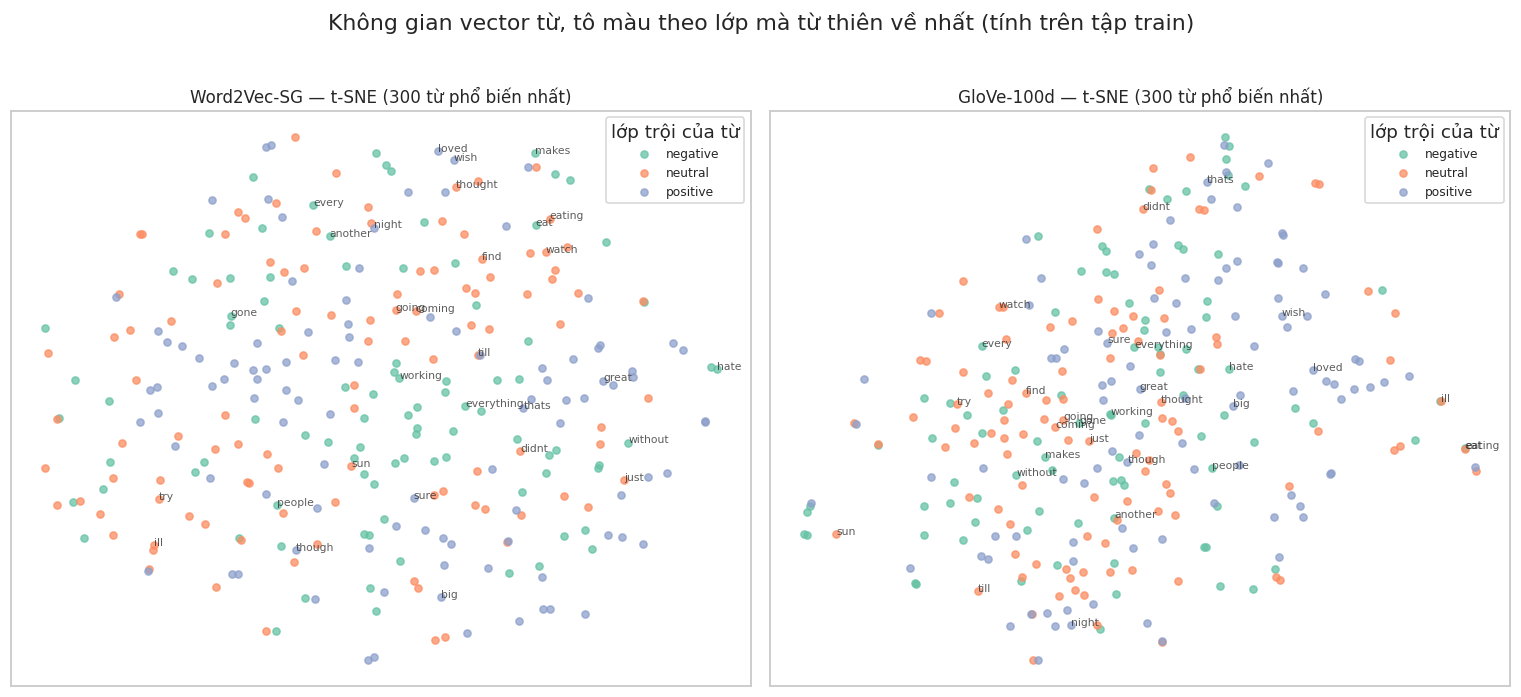


CÁCH ĐỌC HAI BIỂU ĐỒ TRÊN:
  - Nếu các màu TÁCH THÀNH CỤM rõ ràng -> không gian embedding đó đã mã hoá sẵn thông tin
    phân biệt lớp, bộ phân loại chỉ cần vẽ mặt phân tách -> thường cho F1 cao hơn.
  - Nếu các màu TRỘN LẪN -> tín hiệu cảm xúc không nằm sẵn trong hình học của không gian,
    mô hình phải tự học lại từ dữ liệu có nhãn -> khó hơn, cần nhiều dữ liệu hơn.
  - LƯU Ý QUAN TRỌNG: t-SNE chỉ bảo toàn cấu trúc CỤC BỘ, khoảng cách giữa các cụm
    KHÔNG có ý nghĩa định lượng. Đây là công cụ định tính để đối chiếu với F1, không phải bằng chứng.
  - Cả hai biểu đồ dùng CÙNG danh sách từ và CÙNG cách tô màu -> khác biệt nhìn thấy được
    hoàn toàn là do không gian vector, không do cách chọn dữ liệu vẽ.


In [41]:
# =====================================================================
#  16.4 Trực quan hoá không gian vector — t-SNE / PCA cạnh nhau
# =====================================================================
TOP_N_VIZ = 300 if not QUICK_RUN else 150

# Chọn các từ phổ biến nhất CÓ vector thật ở MỌI nguồn được so sánh -> so sánh công bằng
viz_sources = [k for k in DEEP_EMB_KEYS if k in EMB_SOURCES]
cand = [w for w, _ in train_counter.most_common(3000)
        if w in stoi and len(w) > 2 and w not in STOP_ALL]
viz_words = [w for w in cand if all(w in EMB_SOURCES[s] for s in viz_sources)][:TOP_N_VIZ]
print(f"Số từ dùng để vẽ: {len(viz_words)} (phổ biến nhất, có vector thật ở cả "
      f"{len(viz_sources)} nguồn -> loại bỏ ảnh hưởng của vector khởi tạo ngẫu nhiên)")

# Gán mỗi từ về lớp mà nó thiên về nhất (log-odds trên tập TRAIN)
train_tok_by_class = {c: Counter() for c in CLASSES}
for toks, lab in zip(df_train["tokens"], df_train[LABEL_COL]):
    train_tok_by_class[lab].update(toks)
tot_by_class = {c: max(sum(v.values()), 1) for c, v in train_tok_by_class.items()}
grand = max(sum(tot_by_class.values()), 1)

def dominant_class(w):
    best_c, best_s = CLASSES[0], -1e9
    for c in CLASSES:
        p_c = (train_tok_by_class[c][w] + 1) / tot_by_class[c]
        p_all = (train_counter[w] + 1) / grand
        s = math.log(p_c / p_all)
        if s > best_s:
            best_c, best_s = c, s
    return best_c

viz_classes = [dominant_class(w) for w in viz_words]
print("Phân bố lớp trội của các từ đem vẽ:", dict(Counter(viz_classes)))


def project_2d(V, method="tsne"):
    if method == "tsne" and len(V) > 10:
        try:
            per = max(5, min(30, (len(V) - 1) // 3))
            return TSNE(n_components=2, random_state=SEED, init="pca",
                        perplexity=per, learning_rate="auto").fit_transform(V), "t-SNE"
        except Exception as e:
            print(f"[viz] t-SNE lỗi ({type(e).__name__}) -> dùng PCA.")
    return PCA(n_components=2, random_state=SEED).fit_transform(V), "PCA"


if viz_words and viz_sources:
    fig, axes = plt.subplots(1, len(viz_sources), figsize=(7 * len(viz_sources), 6.2),
                             squeeze=False)
    for j, src in enumerate(viz_sources):
        kv = EMB_SOURCES[src]
        V = np.array([kv[w] for w in viz_words], dtype=np.float32)
        V = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)   # chuẩn hoá L2
        P, meth = project_2d(V, "tsne")
        a = axes[0][j]
        for i, c in enumerate(CLASSES):
            idx = [k for k, cc in enumerate(viz_classes) if cc == c]
            if idx:
                a.scatter(P[idx, 0], P[idx, 1], s=22, alpha=0.75,
                          color=PALETTE[i % len(PALETTE)], label=str(c))
        # chú thích một số từ tiêu biểu
        for k in range(0, len(viz_words), max(1, len(viz_words) // 28)):
            a.annotate(viz_words[k], (P[k, 0], P[k, 1]), fontsize=7, alpha=0.75)
        a.set_title(f"{src} — {meth} ({len(viz_words)} từ phổ biến nhất)", fontsize=11)
        a.legend(title="lớp trội của từ", fontsize=8)
        a.set_xticks([]); a.set_yticks([])
    plt.suptitle("Không gian vector từ, tô màu theo lớp mà từ thiên về nhất (tính trên tập train)",
                 y=1.02)
    plt.tight_layout(); plt.show()

    print("""
CÁCH ĐỌC HAI BIỂU ĐỒ TRÊN:
  - Nếu các màu TÁCH THÀNH CỤM rõ ràng -> không gian embedding đó đã mã hoá sẵn thông tin
    phân biệt lớp, bộ phân loại chỉ cần vẽ mặt phân tách -> thường cho F1 cao hơn.
  - Nếu các màu TRỘN LẪN -> tín hiệu cảm xúc không nằm sẵn trong hình học của không gian,
    mô hình phải tự học lại từ dữ liệu có nhãn -> khó hơn, cần nhiều dữ liệu hơn.
  - LƯU Ý QUAN TRỌNG: t-SNE chỉ bảo toàn cấu trúc CỤC BỘ, khoảng cách giữa các cụm
    KHÔNG có ý nghĩa định lượng. Đây là công cụ định tính để đối chiếu với F1, không phải bằng chứng.
  - Cả hai biểu đồ dùng CÙNG danh sách từ và CÙNG cách tô màu -> khác biệt nhìn thấy được
    hoàn toàn là do không gian vector, không do cách chọn dữ liệu vẽ.""")
else:
    print("Không đủ dữ liệu để vẽ.")

In [42]:
# =====================================================================
#  16.5 Đo định lượng "độ tách lớp" của mỗi không gian embedding
#       (bổ sung cho t-SNE, vì t-SNE chỉ là định tính)
# =====================================================================
if viz_words and len(viz_sources) >= 1:
    print("ĐỘ TÁCH LỚP TRONG KHÔNG GIAN EMBEDDING")
    print("Chỉ số: (khoảng cách cosine trung bình GIỮA các lớp) - (trong CÙNG lớp).")
    print("Càng dương và càng lớn -> các từ cùng lớp càng nằm gần nhau -> embedding càng")
    print("mã hoá sẵn thông tin phân biệt lớp.\n")
    for src in viz_sources:
        kv = EMB_SOURCES[src]
        V = np.array([kv[w] for w in viz_words], dtype=np.float32)
        V = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)
        S = V @ V.T                                   # cosine similarity
        D = 1.0 - S
        lab = np.array([CLASSES.index(c) for c in viz_classes])
        same = (lab[:, None] == lab[None, :])
        np.fill_diagonal(same, False)
        eye = ~np.eye(len(V), dtype=bool)
        d_in = D[same].mean() if same.any() else float("nan")
        d_out = D[eye & ~same].mean() if (eye & ~same).any() else float("nan")
        print(f"  {src:<18}: trong-lớp={d_in:.4f}  giữa-lớp={d_out:.4f}  "
              f"chênh lệch={d_out - d_in:+.4f}")
    print("\n-> Đối chiếu thứ tự của chỉ số này với thứ tự macro-F1 ở mục 15.")
    print("   Nếu hai thứ tự trùng nhau, ta có bằng chứng rằng chênh lệch F1 THỰC SỰ đến từ")
    print("   hình học của không gian embedding chứ không phải từ may rủi khi huấn luyện.")

ĐỘ TÁCH LỚP TRONG KHÔNG GIAN EMBEDDING
Chỉ số: (khoảng cách cosine trung bình GIỮA các lớp) - (trong CÙNG lớp).
Càng dương và càng lớn -> các từ cùng lớp càng nằm gần nhau -> embedding càng
mã hoá sẵn thông tin phân biệt lớp.

  Word2Vec-SG       : trong-lớp=0.7824  giữa-lớp=0.7985  chênh lệch=+0.0161
  GloVe-100d        : trong-lớp=0.5614  giữa-lớp=0.5755  chênh lệch=+0.0141

-> Đối chiếu thứ tự của chỉ số này với thứ tự macro-F1 ở mục 15.
   Nếu hai thứ tự trùng nhau, ta có bằng chứng rằng chênh lệch F1 THỰC SỰ đến từ
   hình học của không gian embedding chứ không phải từ may rủi khi huấn luyện.


---
# 17. Đề xuất phương án cải thiện

Xếp theo **tỉ lệ lợi ích / công sức** giảm dần. Mỗi mục nêu rõ **vấn đề cụ thể quan sát được ở trên**
mà nó nhắm vào.

### 17.1 fastText — vector subword (ưu tiên cao nhất)

**Nhắm vào:** tỉ lệ OOV đo ở mục 12 và tỉ lệ hapax rất cao thấy ở EDA.

fastText biểu diễn mỗi từ bằng **tổng các n-gram ký tự** (`where` → `<wh, whe, her, ere, re>`).
Hệ quả trực tiếp: nó **sinh được vector cho từ chưa từng thấy** — `loveeee` vẫn nhận vector gần
`love` vì chia sẻ n-gram. Điều này tấn công đúng điểm yếu lớn nhất của **cả hai** phương pháp trong
bài, và với hình thái phong phú/lỗi chính tả của dữ liệu mạng xã hội thì lợi ích thường rất rõ.

```python
from gensim.models import FastText
ft = FastText(sentences=train_corpus, vector_size=EMB_DIM, window=5,
              min_count=1, sg=1, epochs=30, min_n=3, max_n=6, seed=SEED)
ft.wv["mộttừchưatừngthấy"]   # vẫn ra vector, không ném KeyError
```
Hoặc dùng bản tiền huấn luyện `cc.en.300` / `cc.vi.300` để có **cả** hai lợi thế: subword *và*
ngữ liệu khổng lồ.

### 17.2 Domain-adaptive continued pretraining

**Nhắm vào:** đánh đổi "khớp miền ↔ lượng dữ liệu" ở trục 2 — thay vì **chọn một**, hãy **lấy cả hai**.

Khởi tạo Word2Vec bằng chính vector GloVe, rồi **huấn luyện tiếp** trên ngữ liệu in-domain:

```python
model = Word2Vec(vector_size=100, window=5, min_count=2, sg=1, seed=SEED)
model.build_vocab(train_corpus)
model.wv.vectors_lockf = np.ones(len(model.wv), dtype=np.float32)
model.wv.intersect_word2vec_format("glove_w2v_format.txt", binary=False, lockf=1.0)
model.train(train_corpus, total_examples=len(train_corpus), epochs=20)
```

Từ phổ biến giữ được chất lượng từ 6 tỉ token; từ đặc thù miền được học thêm. Đây thường là
**cải thiện lớn nhất mà vẫn giữ nguyên kiến trúc**.

### 17.3 Embedding theo ngữ cảnh (BERT / PhoBERT) — bước đi tự nhiên tiếp theo

**Nhắm vào:** khuyết tật `good ↔ bad` ở trục 3, thứ **không thể** sửa bằng embedding tĩnh.

Embedding tĩnh gán **một** vector cho mỗi từ, bất kể ngữ cảnh. BERT sinh vector **phụ thuộc ngữ cảnh**,
nên phân biệt được *"not good"* với *"good"*, và xử lý được cả mỉa mai/phủ định.

* Tiếng Anh: `distilbert-base-uncased` (nhẹ, hợp Colab T4) hoặc `roberta-base`.
* **Tiếng Việt: `vinai/phobert-base`** — lưu ý PhoBERT **yêu cầu văn bản đã tách từ**
  (`underthesea`/VnCoreNLP), đúng bước ta đã cài sẵn ở nhánh tiếng Việt mục 8.
* Có thể dùng theo hai cách: (a) trích đặc trưng đóng băng — rẻ, hoặc (b) fine-tune toàn bộ —
  đắt hơn nhưng thường nhảy vọt về F1.

Đây là **giới hạn trần** của hướng embedding tĩnh mà bài này khảo sát.

### 17.4 Tokenisation / tách từ tốt hơn

* **Tiếng Việt:** word segmentation là **bắt buộc**, không phải tuỳ chọn — "học sinh" là một từ.
  Nếu bỏ qua, mọi vector đều học ở mức âm tiết và mất phần lớn ngữ nghĩa.
* **Tiếng Anh / mạng xã hội:** dùng tokenizer chuyên cho tweet, giữ **emoji** (tín hiệu cảm xúc cực
  mạnh mà bước làm sạch hiện tại đang **xoá đi**), chuẩn hoá slang bằng từ điển
  (`u → you`, `luv → love`), sửa chính tả.
* Cân nhắc giữ lại **dấu chấm than** và **VIẾT HOA TOÀN BỘ** làm đặc trưng riêng — chúng mã hoá
  cường độ cảm xúc mà pipeline hiện tại đang loại bỏ.

### 17.5 Tăng số chiều & tinh chỉnh siêu tham số

Bài này cố định 100 chiều để **so sánh công bằng**. Khi đã chọn xong nguồn embedding, nên thử
200/300 chiều (`glove-wiki-gigaword-300`), và tìm kiếm siêu tham số có hệ thống với Optuna:
`window`, `negative`, `min_count`, `epochs`, `lr`, `dropout`, `hidden`, số filter/kernel.
Luôn tuyển chọn trên **validation**, không bao giờ trên test.

### 17.6 Xử lý mất cân bằng lớp

Notebook đã dùng **class weight**. Có thể mạnh hơn:
* **Focal loss** — tập trung vào mẫu khó thay vì chỉ vào lớp hiếm;
* **oversampling lớp thiểu số** hoặc `WeightedRandomSampler`;
* **tinh chỉnh ngưỡng quyết định** theo từng lớp trên val để tối ưu trực tiếp macro-F1.

### 17.7 Tăng cường dữ liệu (data augmentation)

* **EDA** (Easy Data Augmentation): thay từ đồng nghĩa, chèn/hoán vị/xoá ngẫu nhiên;
* **thay từ đồng nghĩa dựa trên chính embedding** — dùng `most_similar` để sinh biến thể;
* **back-translation** (vi → en → vi) cho biến thể tự nhiên nhất, đắt hơn;
* **nhiễu mức ký tự** để mô hình bền với lỗi chính tả — đặc biệt hợp dữ liệu mạng xã hội.

### 17.8 Ensemble và kết hợp đặc trưng

* **Nối** vector TF-IDF với vector embedding trung bình: bảng kết quả mục 15 thường cho thấy hai
  hướng này mắc **những lỗi khác nhau**, nên kết hợp bổ trợ nhau tốt.
* **Nối embedding**: ghép vector Word2Vec (100) với GloVe (100) thành 200 chiều — mô hình tự học
  trọng số cho từng nguồn, khai thác đồng thời khớp miền và chất lượng vector.
* **Soft-voting** trên xác suất của nhiều mô hình, hoặc trung bình nhiều seed để giảm phương sai.

### 17.9 Về giao thức đánh giá

* **Chạy nhiều seed** (ví dụ 5 seed) rồi báo cáo **trung bình ± độ lệch chuẩn**. Chênh lệch F1 dưới
  ~0.01 giữa hai cấu hình rất có thể chỉ là nhiễu ngẫu nhiên — không nên kết luận từ một lần chạy.
* **k-fold stratified cross-validation** thay vì một lần chia, nếu đủ thời gian tính toán.
* **Kiểm định ý nghĩa thống kê** (bootstrap trên tập test, hoặc McNemar test cho hai bộ phân loại).

---
# 18. Kết luận

**Về mặt kỹ thuật đã thực hiện:**

1. Xây dựng pipeline phân loại văn bản ngắn **hoàn chỉnh và phòng thủ**: tải dữ liệu từ Google Drive
   với ba lớp dự phòng; bộ nạp **bất khả tri định dạng** tự dò kiểu file, tự dò encoding
   (dataset này không phải UTF-8), tự dò cột text và cột nhãn; nhánh tiền xử lý riêng cho
   tiếng Anh và tiếng Việt.
2. Xây dựng **hai nguồn embedding** theo đúng kịch bản chúng được dùng trong thực tế:
   **Word2Vec** (cả Skip-gram và CBOW) huấn luyện **trên chính tập train** — hiện thân của
   *khớp miền*; và **GloVe** tiền huấn luyện trên 6 tỉ token — hiện thân của *lượng dữ liệu*.
3. So sánh trên **cùng một** bộ phân loại, **cùng** tiền xử lý, **cùng** cách chia dữ liệu,
   **cùng** seed, **cùng** số chiều (100). Bốn kiến trúc: TF-IDF + LinearSVC (mốc phi-nơ-ron),
   MeanPool + LogReg, BiLSTM, TextCNN, cộng ablation đóng-băng-vs-fine-tune.
4. Đo lường đầy đủ: coverage/OOV theo **cả** *type* và *token*, accuracy, macro/weighted P-R-F1,
   báo cáo theo lớp, confusion matrix, chi phí tính toán, độ tách lớp trong không gian vector,
   và trực quan hoá t-SNE/PCA **cạnh nhau**.

**Về mặt nhận thức rút ra:**

* Với **văn bản ngắn**, **coverage của từ vựng quan trọng ngang — thậm chí hơn — chất lượng nội tại
  của vector**. Câu chỉ có chục token nên mỗi từ OOV là một cú đấm vào biểu diễn câu. Bài học:
  **luôn đo OOV trước khi chọn embedding**, và phải đo cả theo *type* lẫn theo *token*.
* Cuộc so sánh Word2Vec-vs-GloVe ở đây thực chất là **"khớp miền" đấu với "lượng dữ liệu huấn
  luyện"**. Không có bên nào thắng phổ quát — câu trả lời phụ thuộc vào **khoảng cách miền** giữa
  ngữ liệu tiền huấn luyện và dữ liệu đích, cùng **kích thước** ngữ liệu in-domain sẵn có.
  Số liệu cụ thể của lần chạy này nằm ở mục 16.2.
* **Cả hai** phương pháp đều bị chặn bởi cùng một trần: chúng là **embedding tĩnh**, gán một vector
  cố định cho mỗi từ. Chúng không phân biệt được *"good"* với *"not good"*, và coi từ trái nghĩa là
  láng giềng gần. Với phân tích cảm xúc, đây là hạn chế **cấu trúc**, không phải hạn chế do thiếu
  tinh chỉnh — và là lý do bước đi tiếp theo bắt buộc phải là **embedding theo ngữ cảnh**
  (PhoBERT cho tiếng Việt, DistilBERT/RoBERTa cho tiếng Anh).
* Mốc **TF-IDF + LinearSVC** giữ vai trò kiểm tra tỉnh táo rất giá trị: với văn bản ngắn và từ vựng
  hạn chế, các phương pháp túi-từ vẫn cực kỳ cạnh tranh. Một mô hình deep learning chỉ đáng dùng khi
  **thực sự vượt được** mốc này.

**Ba đề xuất cải thiện ưu tiên cao nhất:** (1) **fastText** với vector subword để triệt tận gốc vấn
đề OOV; (2) **domain-adaptive continued pretraining** — khởi tạo bằng GloVe rồi huấn luyện tiếp
in-domain, lấy cả hai lợi thế thay vì chọn một; (3) chuyển sang **embedding theo ngữ cảnh** để phá
trần của embedding tĩnh.

---